In [ ]:
# Cell 1 - Imports
import numpy as np
import matplotlib.pyplot as plt
import mlx.core as mx
from numpy.fft import fftfreq
import xsmurf_wrapper as xsm
from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy

%matplotlib inline

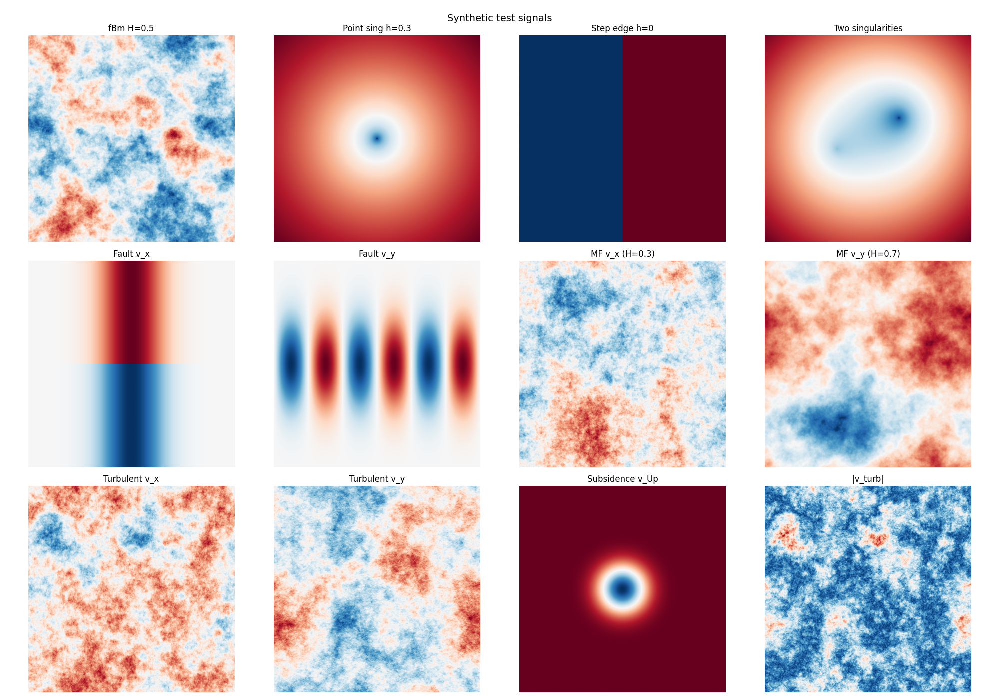

All signals: 512x512 float32


In [ ]:
# Cell 2 - Synthetic test signals with known singularity structure
N = 512
x = np.linspace(-1, 1, N, dtype=np.float32)
X, Y = np.meshgrid(x, x)
r = np.sqrt(X**2 + Y**2).astype(np.float32)

# --- fBm generator (numpy, no xsmurf C) ---
def generate_fbm_numpy(N, H, seed=42):
    """Generate 2D fractional Brownian motion via spectral synthesis."""
    rng = np.random.RandomState(seed)
    kx = np.fft.fftfreq(N).astype(np.float64)
    ky = np.fft.fftfreq(N).astype(np.float64)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    K[0, 0] = 1.0  # avoid division by zero
    # Power spectrum ~ |k|^{-(2H+2)} for 2D fBm
    amplitude = K ** (-(H + 1.0))
    amplitude[0, 0] = 0.0  # zero mean
    phases = rng.uniform(0, 2 * np.pi, (N, N))
    fft_data = amplitude * np.exp(1j * phases)
    # Enforce Hermitian symmetry for real output
    fbm = np.real(np.fft.ifft2(fft_data)).astype(np.float32)
    fbm -= fbm.mean()
    fbm /= fbm.std()
    return fbm

# --- Scalar signals ---
fbm_H = 0.5
fbm = generate_fbm_numpy(N, fbm_H, seed=42)

# Point singularity: |r|^h
h_sing = 0.3
point_sing = (r ** h_sing).astype(np.float32)

# Step edge (h=0 singularity along a line)
step_edge = np.where(X > 0, np.float32(1.0), np.float32(0.0))

# Two singularities (test chain merging)
r1 = np.sqrt((X - 0.3)**2 + (Y - 0.2)**2).astype(np.float32)
r2 = np.sqrt((X + 0.3)**2 + (Y + 0.1)**2).astype(np.float32)
two_sing = (r1 ** 0.4 + 0.5 * r2 ** 0.6).astype(np.float32)

# --- Vector field signals (2D -> 2D) ---

# Synthetic strike-slip fault: v_x has a step across y=0, v_y smooth
fault_vx = (np.where(Y > 0, 1.0, -1.0) * np.exp(-X**2 / 0.1)).astype(np.float32)
fault_vy = (0.1 * np.sin(3.0 * np.pi * X) * np.exp(-Y**2 / 0.2)).astype(np.float32)

# Vortex: purely rotational
vortex_vx = (-Y / (r + 0.05)).astype(np.float32)
vortex_vy = (X / (r + 0.05)).astype(np.float32)

# Source/sink: purely irrotational
source_vx = (X / (r**2 + 0.05)).astype(np.float32)
source_vy = (Y / (r**2 + 0.05)).astype(np.float32)

# Multifractal vector field: two independent fBm components with different H
# v_x has H=0.3 (rough, cusp-like), v_y has H=0.7 (smooth)
# This creates anisotropic multifractal strain: L and T will have different spectra
mf_vx = generate_fbm_numpy(N, 0.3, seed=100)
mf_vy = generate_fbm_numpy(N, 0.7, seed=200)

# Multifractal vector field with coupled components (turbulence-like)
# v_x = fBm_1 + gradient of fBm_2 (adds irrotational component)
# v_y = fBm_2 + curl of fBm_1 (adds rotational component)
fbm_a = generate_fbm_numpy(N, 0.4, seed=300)
fbm_b = generate_fbm_numpy(N, 0.4, seed=400)
# Approximate gradient/curl via finite differences
grad_b_x = np.roll(fbm_b, -1, axis=1) - np.roll(fbm_b, 1, axis=1)
grad_b_y = np.roll(fbm_b, -1, axis=0) - np.roll(fbm_b, 1, axis=0)
curl_a_x = np.roll(fbm_a, -1, axis=0) - np.roll(fbm_a, 1, axis=0)   # d(fbm_a)/dy
curl_a_y = -(np.roll(fbm_a, -1, axis=1) - np.roll(fbm_a, 1, axis=1))  # -d(fbm_a)/dx
turb_vx = (fbm_a + 0.5 * grad_b_x).astype(np.float32)
turb_vy = (fbm_b + 0.5 * curl_a_x).astype(np.float32)

# --- 3-component field (2D grid, 3 velocity components) ---
v_NS = fault_vx.copy()
v_EW = fault_vy.copy()
v_Up = (-0.3 * np.exp(-(X**2 + Y**2) / 0.05)).astype(np.float32)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for ax, (img, title) in zip(axes.flat, [
    (fbm, f'fBm H={fbm_H}'), (point_sing, f'Point sing h={h_sing}'),
    (step_edge, 'Step edge h=0'), (two_sing, 'Two singularities'),
    (fault_vx, 'Fault v_x'), (fault_vy, 'Fault v_y'),
    (mf_vx, 'MF v_x (H=0.3)'), (mf_vy, 'MF v_y (H=0.7)'),
    (turb_vx, 'Turbulent v_x'), (turb_vy, 'Turbulent v_y'),
    (v_Up, 'Subsidence v_Up'), (np.sqrt(turb_vx**2 + turb_vy**2), '|v_turb|')]):
    ax.imshow(img, origin='lower', cmap='RdBu_r', rasterized=True)
    ax.set_title(title); ax.axis('off')
plt.suptitle('Synthetic test signals', fontsize=14)
plt.tight_layout()
plt.show()

signals = {'fBm': fbm, 'point_sing': point_sing, 'step_edge': step_edge, 'two_sing': two_sing}
print(f'All signals: {N}x{N} float32')

In [ ]:
# Cell 3 - CWT function (same as xsm_wrapper_v2)

def compute_scales(n_oct, n_vox, a_min=2):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    
    if wavelet == 'mexican':
        # Mexican hat: extra (kx^2+ky^2) factor = 3 vanishing moments
        k2 = sx * sx + sy * sy
        return {
            'dx':   to_complex(zero,                     sx * k2 * gauss),
            'dy':   to_complex(zero,                     sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss,    zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss,    zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss,    zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        # Gaussian (default): 1 vanishing moment
        return {
            'dx':   to_complex(zero,               sx * gauss),
            'dy':   to_complex(zero,               sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss,   zero),
            'dxy':  to_complex(-sy * sx * gauss,   zero),
            'dyy':  to_complex(-sy * sy * gauss,   zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='all', wavelet='gaussian', verbose=True):
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 8) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

print('CWT functions defined')

CWT functions defined


In [ ]:
# Cell 4 - Scalar WTMM on all synthetic signals
n_oct = 3
n_vox = 8
scales = compute_scales(n_oct, n_vox)
print(f'{len(scales)} scales: [{scales[0]:.1f}, {scales[-1]:.1f}]')

results = {}
for name, img in signals.items():
    print(f'\n=== {name} ===')
    deriv = cwt_2d_f32(img, scales, pad=32, derivs='all', verbose=False)
    
    ext_images = []
    for i, scale in enumerate(scales):
        kapa = gkapa_numpy(deriv['dx'][i], deriv['dy'][i],
                           deriv['dxx'][i], deriv['dxy'][i], deriv['dyy'][i])
        kapap = gkapap_numpy(deriv['dx'][i], deriv['dy'][i],
                             deriv['dxx'][i], deriv['dxy'][i], deriv['dyy'][i],
                             deriv['dxxx'][i], deriv['dxxy'][i], deriv['dxyy'][i], deriv['dyyy'][i])
        ext = xsm.find_extrema_follow(
            xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
            xsm.XImage.from_numpy(deriv['mod'][i]), xsm.XImage.from_numpy(deriv['arg'][i]),
            scale, thresh=1e-6)
        ext_images.append(ext)
    
    print(f'  Extrema: {[ext.extr_nb for ext in ext_images[::n_vox]]}')
    
    xsm.chain(ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
    chains = xsm.extract_vertical_chains(ext_images, scales)
    holders = xsm.compute_holder_exponents(chains)
    spectra = xsm.compute_spectra(ext_images, scales)
    
    h_vals = np.array([h['h'] for h in holders])
    print(f'  {len(chains)} chains, median h = {np.nanmedian(h_vals):.3f}')
    
    results[name] = {
        'ext_images': ext_images, 'chains': chains,
        'holders': holders, 'spectra': spectra, 'deriv': deriv
    }

24 scales: [7.0, 51.2]

=== fBm ===
  Extrema: [45956, 24483, 12385]
  4203 chains, median h = -0.035

=== point_sing ===
  Extrema: [16, 32, 64]
  3 chains, median h = 0.303

=== step_edge ===
  Extrema: [35700, 4590, 3060]
  508 chains, median h = -0.004

=== two_sing ===
  Extrema: [430, 468, 500]
  2 chains, median h = 0.597


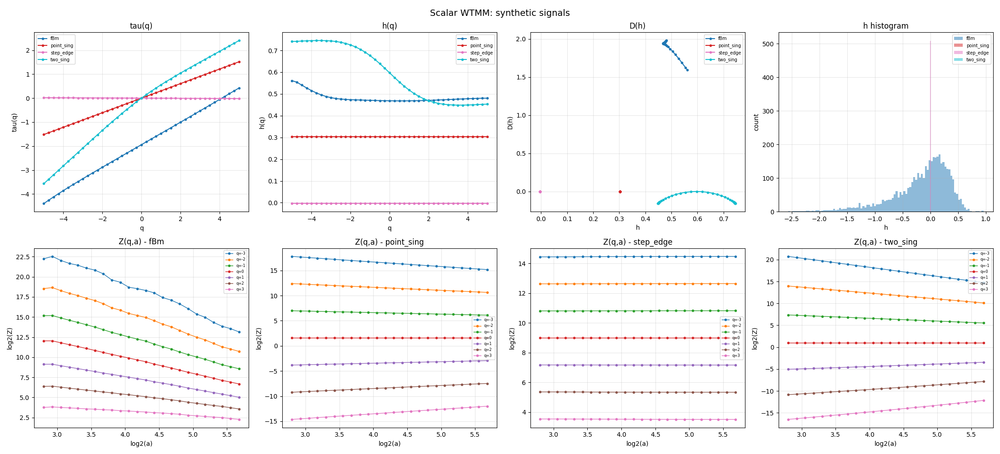

In [ ]:
# Cell 5 - Compare D(h) spectra for all scalar signals
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(signals)))

for idx, (name, res) in enumerate(results.items()):
    sp = res['spectra']
    h_vals = np.array([h['h'] for h in res['holders']])
    
    # tau(q)
    axes[0, 0].plot(sp['q_list'], sp['tau'], '.-', color=colors[idx], label=name, lw=1.5)
    # h(q)
    axes[0, 1].plot(sp['q_list'], sp['h'], '.-', color=colors[idx], label=name, lw=1.5)
    # D(h)
    valid = np.isfinite(sp['D']) & np.isfinite(sp['h'])
    axes[0, 2].plot(sp['h'][valid], sp['D'][valid], '.-', color=colors[idx], label=name, lw=1.5)
    # h histogram
    axes[0, 3].hist(h_vals[np.isfinite(h_vals)], bins=100, alpha=0.5, color=colors[idx], label=name)

for ax, title in zip(axes[0], ['tau(q)', 'h(q)', 'D(h)', 'h histogram']):
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
axes[0, 0].set(xlabel='q', ylabel='tau(q)')
axes[0, 1].set(xlabel='q', ylabel='h(q)')
axes[0, 2].set(xlabel='h', ylabel='D(h)')
axes[0, 3].set(xlabel='h', ylabel='count')

# Z(q,a) for each signal
for idx, (name, res) in enumerate(results.items()):
    sp = res['spectra']
    ax = axes[1, idx]
    q_show = np.arange(-3, 4, 1.0)
    for q in q_show:
        qi = np.argmin(np.abs(sp['q_list'] - q))
        ax.plot(sp['log2_scales'], sp['log2_Z'][qi], '.-', label=f'q={q:.0f}', lw=1)
    ax.set(xlabel='log2(a)', ylabel='log2(Z)', title=f'Z(q,a) - {name}')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

plt.suptitle('Scalar WTMM: synthetic signals', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 5a - Select a signal to explore interactively
# Change this to explore different signals
EXPLORE_SIGNAL = 'fBm'  # 'fBm', 'point_sing', 'step_edge', 'two_sing'

res = results[EXPLORE_SIGNAL]
ext_images = res['ext_images']
chains = res['chains']
holders_fit = res['holders']
holders_slope = xsm.compute_holder_local_slope(chains, method='max')
crop_image = signals[EXPLORE_SIGNAL]

h_fit_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders_fit}
h_slope_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders_slope}

# Build chain lookup
chain_lookup = {}
for ch in chains:
    vc_len = len(ch['mod'])
    if vc_len == 0:
        continue
    anchor_key = (int(ch['x'][0]), int(ch['y'][0]))
    for si in range(min(vc_len, len(scales))):
        chain_lookup[(si, int(ch['x'][si]), int(ch['y'][si]))] = (vc_len, anchor_key)

print(f'Exploring: {EXPLORE_SIGNAL}')
print(f'  {len(chains)} chains, {sum(e.extr_nb for e in ext_images)} total extrema')
print(f'  Median h (fit): {np.nanmedian([h["h"] for h in holders_fit]):.3f}')

Exploring: fBm
  4203 chains, 510231 total extrema
  Median h (fit): -0.035


In [ ]:
# Cell 5b - Precompute line segments for interactive viewer
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

lines_by_scale = []
lines_hfit_by_scale = []
lines_hslope_by_scale = []
lines_maxvc_by_scale = []

for si in range(len(scales)):
    ext = ext_images[si]
    line_list = ext.get_lines()
    lx_ext = ext.lx
    segs, seg_hfit, seg_hslope, seg_maxvc = [], [], [], []
    for line in line_list:
        positions = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(positions) < 2:
            continue
        xs = (positions % lx_ext).astype(np.float64)
        ys = (positions // lx_ext).astype(np.float64)
        segs.append(np.column_stack([xs, ys]))
        max_vc, best_hfit, best_hslope = 0, np.nan, np.nan
        for j in range(len(positions)):
            info = chain_lookup.get((si, int(xs[j]), int(ys[j])), (0, None))
            if info[0] > max_vc:
                max_vc = info[0]
                if info[1] is not None:
                    best_hfit = h_fit_lookup.get(info[1], np.nan)
                    best_hslope = h_slope_lookup.get(info[1], np.nan)
        seg_hfit.append(best_hfit)
        seg_hslope.append(best_hslope)
        seg_maxvc.append(max_vc)
    lines_by_scale.append(segs)
    lines_hfit_by_scale.append(np.array(seg_hfit, dtype=np.float32))
    lines_hslope_by_scale.append(np.array(seg_hslope, dtype=np.float32))
    lines_maxvc_by_scale.append(np.array(seg_maxvc, dtype=np.int32))

# WTMMM arrows
wtmmm_by_scale = []
for si in range(len(scales)):
    ext = ext_images[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    if ext.extr_nb == 0:
        wtmmm_by_scale.append({'x': np.array([]), 'y': np.array([]),
                                'mod': np.array([]), 'arg': np.array([])})
        continue
    m = on_vc.astype(bool)
    wtmmm_by_scale.append({
        'x': data['x'][m].astype(np.float64),
        'y': data['y'][m].astype(np.float64),
        'mod': data['mod'][m],
        'arg': data['arg'][m],
    })

print(f"Precomputed {sum(len(s) for s in lines_by_scale)} line segments, "
      f"{sum(len(w['x']) for w in wtmmm_by_scale)} WTMMM arrows")

Precomputed 33038 line segments, 31031 WTMMM arrows


In [ ]:
# Cell 5c - Interactive extrema viewer
from ipywidgets import interact, IntRangeSlider, IntSlider, Checkbox, Dropdown, FloatSlider, Layout

scale_cmap = plt.cm.plasma
scale_norm = Normalize(vmin=0, vmax=len(scales)-1)

def robust_limits(vals, lo=5, hi=95, default=(-1, 1)):
    return (np.percentile(vals, lo), np.percentile(vals, hi)) if len(vals) > 0 else default

def draw_fast(scale_range, min_hchain, min_vc, min_h, h_filter_method,
              color_by, cmap_name, show_mode, show_bg, line_width,
              arrow_scale, log2_arrows):
    fig, ax = plt.subplots(figsize=(10, 10))
    if show_bg:
        ax.imshow(crop_image, origin='lower', cmap='gray', rasterized=True,
                  extent=[0, crop_image.shape[1], 0, crop_image.shape[0]], alpha=0.6)
        ax.set_facecolor('black')
    else:
        ax.set_facecolor('white')

    si_lo, si_hi = scale_range
    si_range = range(si_lo, si_hi + 1)

    if show_mode in ('Horizontal chains', 'Chains + arrows'):
        n_pts = 0
        for si in si_range:
            segs = lines_by_scale[si]
            hfit = lines_hfit_by_scale[si]
            hslope = lines_hslope_by_scale[si]
            maxvc = lines_maxvc_by_scale[si]
            if not segs:
                continue
            keep = np.ones(len(segs), dtype=bool)
            for j, seg in enumerate(segs):
                if len(seg) < min_hchain:
                    keep[j] = False
            if min_vc > 0:
                keep &= (maxvc >= min_vc)
            if min_h > -4.9:
                h_ref = hfit if h_filter_method == 'LS fit' else hslope
                keep &= (h_ref >= min_h) | np.isnan(h_ref)
            filtered_segs = [segs[j] for j in range(len(segs)) if keep[j]]
            if not filtered_segs:
                continue
            if color_by in ('h (LS fit)', 'h (max slope)'):
                h_vals = hfit[keep] if color_by == 'h (LS fit)' else hslope[keep]
                valid_h = h_vals[np.isfinite(h_vals)]
                vmin, vmax = robust_limits(valid_h, 5, 95) if len(valid_h) > 0 else (-1, 1)
                lc = LineCollection(filtered_segs, cmap=cmap_name,
                                    norm=Normalize(vmin=vmin, vmax=vmax),
                                    linewidths=line_width, alpha=0.8)
                lc.set_array(h_vals)
                ax.add_collection(lc)
                if si == si_range[-1]:
                    plt.colorbar(lc, ax=ax, label=color_by, shrink=0.6)
            else:
                sc_color = scale_cmap(scale_norm(si))
                lc = LineCollection(filtered_segs, colors=[sc_color]*len(filtered_segs),
                                    linewidths=line_width, alpha=0.8)
                ax.add_collection(lc)
            n_pts += sum(len(s) for s in filtered_segs)

        if show_mode == 'Chains + arrows':
            for si in si_range:
                w = wtmmm_by_scale[si]
                if len(w['x']) == 0:
                    continue
                if log2_arrows:
                    log_mod = np.log2(np.maximum(w['mod'], 1e-30))
                    log_min, log_range = log_mod.min(), log_mod.max() - log_mod.min()
                    mod_norm = (log_mod - log_min) / (log_range + 1e-30)
                else:
                    mod_norm = w['mod'] / (w['mod'].max() + 1e-30)
                dx_a = np.cos(w['arg']) * mod_norm * arrow_scale
                dy_a = np.sin(w['arg']) * mod_norm * arrow_scale
                sc_color = scale_cmap(scale_norm(si))
                max_arrows = min(8000, len(w['x']))
                step_q = max(1, len(w['x']) // max_arrows)
                ax.quiver(w['x'][::step_q], w['y'][::step_q],
                          dx_a[::step_q], dy_a[::step_q],
                          color=sc_color, scale_units='xy', scale=1,
                          width=0.003, headwidth=4, headlength=3,
                          headaxislength=2.5, alpha=0.9, zorder=5)

        if color_by == 'scale':
            sm = plt.cm.ScalarMappable(norm=scale_norm, cmap=scale_cmap)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label='scale index', shrink=0.6)
    else:
        vc_x = np.array([int(ch['x'][0]) for ch in chains], dtype=np.int32)
        vc_y = np.array([int(ch['y'][0]) for ch in chains], dtype=np.int32)
        vc_len = np.array([len(ch['mod']) for ch in chains], dtype=np.int32)
        vc_h = np.array([h_fit_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
                         for ch in chains], dtype=np.float32)
        mask = (vc_len >= max(min_vc, 2))
        if min_h > -4.9:
            mask &= (vc_h >= min_h) | np.isnan(vc_h)
        c_vals = vc_h[mask]; valid = ~np.isnan(c_vals)
        x_m, y_m, c_vals = vc_x[mask][valid], vc_y[mask][valid], c_vals[valid]
        if len(x_m) > 0:
            vmin, vmax = robust_limits(c_vals, 5, 95)
            sc = ax.scatter(x_m, y_m, c=c_vals, s=8, cmap=cmap_name,
                            vmin=vmin, vmax=vmax, rasterized=True)
            plt.colorbar(sc, ax=ax, label='h', shrink=0.6)
        n_pts = len(x_m)

    scope = f'scales {si_lo}-{si_hi} (a={scales[si_lo]:.1f}-{scales[si_hi]:.1f})'
    ax.set_title(f'{EXPLORE_SIGNAL} | {show_mode} | {color_by} -- {n_pts} pts ({scope})')
    ax.set_xlim(0, N); ax.set_ylim(0, N)
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()

interact(
    draw_fast,
    scale_range=IntRangeSlider(value=[len(scales)//2, len(scales)//2], min=0, max=len(scales)-1,
                               description='Scale range:', layout=Layout(width='70%'),
                               continuous_update=False),
    min_hchain=IntSlider(value=5, min=1, max=200, step=1,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=0, min=0, max=len(scales), step=1,
                     description='Min vc:', layout=Layout(width='60%'), continuous_update=False),
    min_h=FloatSlider(value=-5.0, min=-5.0, max=5.0, step=0.1,
                      description='Min h:', layout=Layout(width='60%'), continuous_update=False),
    h_filter_method=Dropdown(options=['Max slope', 'LS fit'], value='Max slope', description='h filter:'),
    color_by=Dropdown(options=['scale', 'h (LS fit)', 'h (max slope)'],
                      value='scale', description='Color by:'),
    cmap_name=Dropdown(options=['RdBu_r', 'coolwarm', 'viridis', 'plasma', 'turbo'],
                       value='RdBu_r', description='Colormap:'),
    show_mode=Dropdown(options=['Chains + arrows', 'Horizontal chains', 'VC origin points'],
                       value='Chains + arrows', description='Show:'),
    show_bg=Checkbox(value=True, description='Show image'),
    line_width=FloatSlider(value=0.8, min=0.1, max=3.0, step=0.1,
                           description='Line width:', layout=Layout(width='60%'), continuous_update=False),
    arrow_scale=FloatSlider(value=5.0, min=0.5, max=30.0, step=0.5,
                            description='Arrow scale:', layout=Layout(width='60%'), continuous_update=False),
    log2_arrows=Checkbox(value=False, description='log2(mod) arrows'));

interactive(children=(IntRangeSlider(value=(12, 12), continuous_update=False, description='Scale range:', layo…

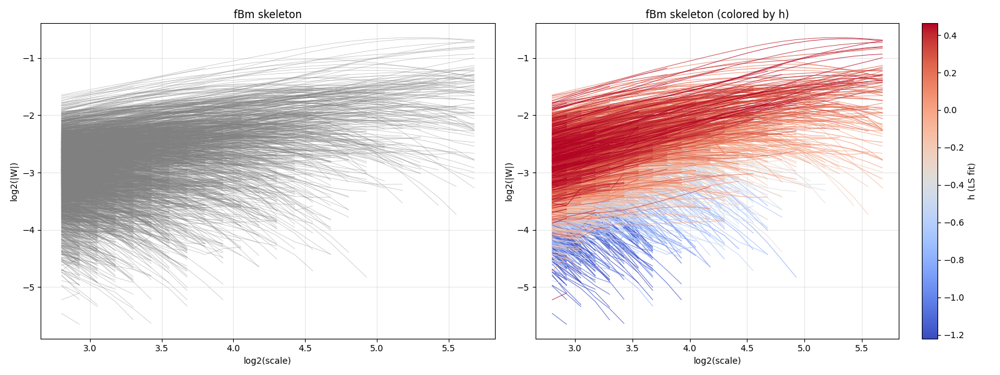

In [ ]:
# Cell 5d - Skeleton plot for selected signal
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
log2_scales_arr = np.log2(scales)

# Gray skeleton
for ch in chains[:3000]:
    n = len(ch['mod'])
    if n < 2:
        continue
    log2_mod = np.log2(np.maximum(np.abs(ch['mod']), 1e-30))
    axes[0].plot(log2_scales_arr[:n], log2_mod, '-', color='gray', alpha=0.5, lw=0.5)
axes[0].set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'{EXPLORE_SIGNAL} skeleton')
axes[0].grid(True, alpha=0.3)

# Colored by h
plot_items = []
for ch in chains[:3000]:
    n = len(ch['mod'])
    if n < 2:
        continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = h_fit_lookup.get(key, np.nan)
    if np.isfinite(h):
        plot_items.append((h, n, np.log2(np.maximum(np.abs(ch['mod']), 1e-30))))

if plot_items:
    plot_items.sort(key=lambda t: t[0])
    h_vals = np.array([t[0] for t in plot_items])
    vmin, vmax = np.percentile(h_vals, [5, 95])
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm
    for h, n, log2_mod in plot_items:
        axes[1].plot(log2_scales_arr[:n], log2_mod, '-', color=cmap(norm(h)), alpha=0.8, lw=0.7)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='h (LS fit)')

axes[1].set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'{EXPLORE_SIGNAL} skeleton (colored by h)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6 - 2D Tensor WTMM on synthetic vector fields
# Compute derivatives of each vector component, then SVD of the Jacobian

vector_fields = {
    'fault': (fault_vx, fault_vy),
    'vortex': (vortex_vx, vortex_vy),
    'source': (source_vx, source_vy),
    'multifractal': (mf_vx, mf_vy),
    'turbulent': (turb_vx, turb_vy),
}

tensor_results = {}
for name, (vx, vy) in vector_fields.items():
    print(f'\n=== Tensor WTMM: {name} ===')
    
    # CWT of each component (only need dx, dy)
    deriv_x = cwt_2d_f32(vx, scales, pad=32, derivs='first', verbose=False)
    deriv_y = cwt_2d_f32(vy, scales, pad=32, derivs='first', verbose=False)
    
    # At each scale: SVD of Jacobian [[dvx/dx, dvx/dy], [dvy/dx, dvy/dy]]
    mod_max_list = []   # sigma_max
    mod_L_list = []     # longitudinal (irrotational)
    mod_T_list = []     # transversal (rotational)
    
    for i, scale in enumerate(scales):
        # Jacobian components as XImage
        gx1 = xsm.XImage.from_numpy(deriv_x['dx'][i])  # dvx/dx
        gy1 = xsm.XImage.from_numpy(deriv_x['dy'][i])  # dvx/dy
        gx2 = xsm.XImage.from_numpy(deriv_y['dx'][i])  # dvy/dx
        gy2 = xsm.XImage.from_numpy(deriv_y['dy'][i])  # dvy/dy
        
        # SVD: largest singular value + direction
        # NOTE: tensor_wtmm_2d modifies gx1,gy1 in place, so duplicate first
        gx1_dup = gx1.duplicate()
        gy1_dup = gy1.duplicate()
        mod_img, arg_img = xsm.tensor_wtmm_2d(gx1_dup, gy1_dup, gx2, gy2, svd_type=xsm.SVD_MAX)
        mod_max_list.append(mod_img.to_numpy())
        
        # L/T decomposition
        gx1_dup2 = xsm.XImage.from_numpy(deriv_x['dx'][i])
        gy1_dup2 = xsm.XImage.from_numpy(deriv_x['dy'][i])
        gx2_dup2 = xsm.XImage.from_numpy(deriv_y['dx'][i])
        gy2_dup2 = xsm.XImage.from_numpy(deriv_y['dy'][i])
        mod_L, mod_T = xsm.tensor_wtmm_2d_LT(gx1_dup2, gy1_dup2, gx2_dup2, gy2_dup2)
        mod_L_list.append(mod_L.to_numpy())
        mod_T_list.append(mod_T.to_numpy())
    
    tensor_results[name] = {
        'mod_max': np.array(mod_max_list),
        'mod_L': np.array(mod_L_list),
        'mod_T': np.array(mod_T_list),
    }
    
    print(f'  sigma_max range: [{mod_max_list[0].min():.4f}, {mod_max_list[0].max():.4f}]')
    print(f'  L range: [{mod_L_list[0].min():.4f}, {mod_L_list[0].max():.4f}]')
    print(f'  T range: [{mod_T_list[0].min():.4f}, {mod_T_list[0].max():.4f}]')
    print(f'  L/T ratio (mean): {np.mean(mod_L_list[0]) / (np.mean(mod_T_list[0]) + 1e-10):.2f}')


=== Tensor WTMM: fault ===
  sigma_max range: [0.0000, 0.5445]
  L range: [0.0000, 0.2743]
  T range: [0.0000, 0.2702]
  L/T ratio (mean): 4.60

=== Tensor WTMM: vortex ===
  sigma_max range: [0.0000, 0.0706]
  L range: [0.0000, 0.0105]
  T range: [0.0000, 0.0703]
  L/T ratio (mean): 0.72

=== Tensor WTMM: source ===
  sigma_max range: [0.0000, 0.0866]
  L range: [0.0000, 0.0866]
  T range: [0.0000, 0.0013]
  L/T ratio (mean): 685.83

=== Tensor WTMM: multifractal ===
  sigma_max range: [0.0000, 0.4210]
  L range: [0.0000, 0.3592]
  T range: [0.0000, 0.1807]
  L/T ratio (mean): 2.21

=== Tensor WTMM: turbulent ===
  sigma_max range: [0.0000, 0.4784]
  L range: [0.0000, 0.4195]
  T range: [0.0000, 0.2478]
  L/T ratio (mean): 2.23


Error: Error: Error: Error: Error: Error: IndexError: index 3 is out of bounds for axis 0 with size 3
[31m---------------------------------------------------------------------------[39m
[31mIndexError[39m                                Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[32][39m[32m, line 7[39m
[32m      3[39m show_scales = [[32m0[39m, len(scales)//[32m3[39m, [32m2[39m*len(scales)//[32m3[39m, len(scales)-[32m1[39m]
[32m      4[39m 
[32m      5[39m [38;5;28;01mfor[39;00m row, (name, tres) [38;5;28;01min[39;00m enumerate(tensor_results.items()):
[32m      6[39m     [38;5;28;01mfor[39;00m col, si [38;5;28;01min[39;00m enumerate(show_scales):
[32m----> [39m[32m7[39m         ax = axes[row, col]
[32m      8[39m         [38;5;66;03m# Show L in red, T in blue, sigma_max as brightness[39;00m
[32m      9[39m         L = tres[[33m'mod_L'[39m][si]
[32m     10[39m         T = tres[[33m'mod_T'[39m][si]

[31mIndexError[

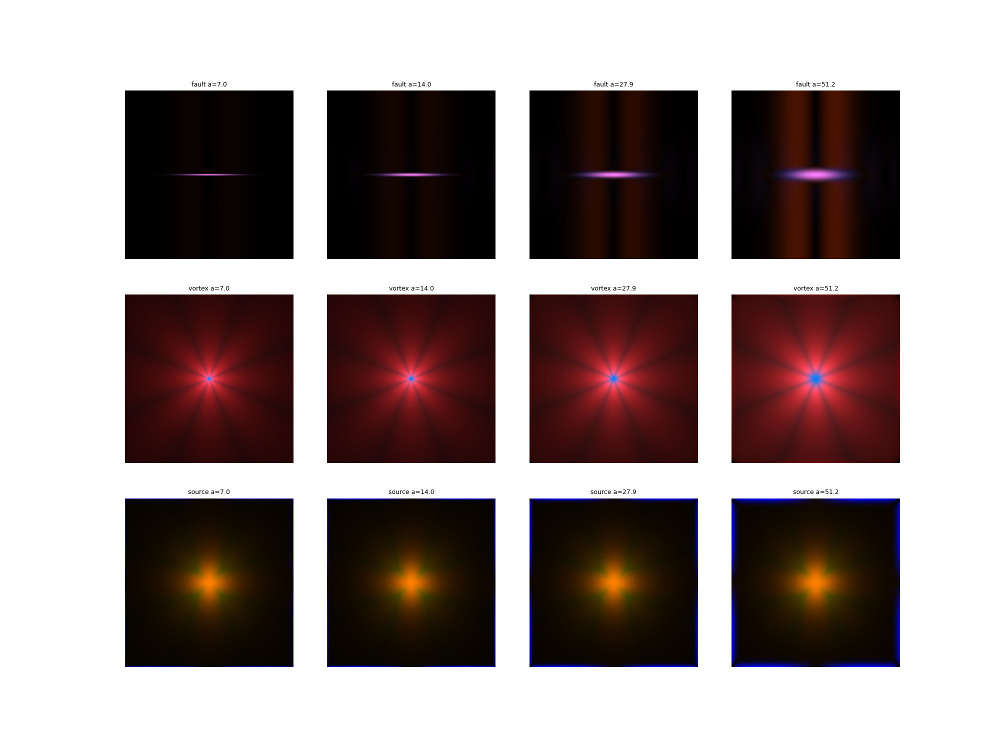

In [ ]:
# Cell 7 - Visualize tensor WTMM: sigma_max, L, T at multiple scales
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
show_scales = [0, len(scales)//3, 2*len(scales)//3, len(scales)-1]

for row, (name, tres) in enumerate(tensor_results.items()):
    for col, si in enumerate(show_scales):
        ax = axes[row, col]
        # Show L in red, T in blue, sigma_max as brightness
        L = tres['mod_L'][si]
        T = tres['mod_T'][si]
        sig = tres['mod_max'][si]
        
        # RGB: R=L, B=T, G=sigma_max (all normalized to [0,1])
        rgb = np.zeros((*L.shape, 3), dtype=np.float32)
        rgb[:,:,0] = L / (L.max() + 1e-10)  # R = longitudinal
        rgb[:,:,2] = T / (T.max() + 1e-10)  # B = transversal
        rgb[:,:,1] = sig / (sig.max() + 1e-10) * 0.5  # G = sigma (dim)
        rgb = np.clip(rgb, 0, 1)
        
        ax.imshow(rgb, origin='lower', rasterized=True)
        ax.set_title(f'{name} a={scales[si]:.1f}', fontsize=9)
        ax.axis('off')

plt.suptitle('Tensor WTMM: R=Longitudinal, B=Transversal, G=sigma_max', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 8 - Scalar WTMM on tensor modulus fields (sigma_max, L, T)
# Treat each tensor quantity as a scalar field and run full WTMM pipeline

tensor_spectra = {}
for name, tres in tensor_results.items():
    print(f'\n=== {name}: WTMM on tensor quantities ===')
    tensor_spectra[name] = {}
    
    for qty_name, qty_data in [('sigma_max', tres['mod_max']),
                                ('L', tres['mod_L']),
                                ('T', tres['mod_T'])]:
        # Build ExtImages from the tensor modulus at each scale
        # Use wtmm2d (NMS) since we have modulus fields, not raw derivatives
        ext_images = []
        for i, scale in enumerate(scales):
            # For NMS on a scalar modulus field, compute gradient of the modulus
            # This is a second-level analysis: singularities of the STRAIN FIELD
            mod_field = qty_data[i]
            deriv_mod = cwt_2d_f32(mod_field, [scale], pad=16, derivs='first', verbose=False)
            dx_img = xsm.XImage.from_numpy(deriv_mod['dx'][0])
            dy_img = xsm.XImage.from_numpy(deriv_mod['dy'][0])
            ext, _, _ = xsm.wtmm2d(dx_img, dy_img, scale, thresh=1e-8)
            ext_images.append(ext)
        
        xsm.chain(ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
        chains = xsm.extract_vertical_chains(ext_images, scales)
        holders = xsm.compute_holder_exponents(chains)
        spectra = xsm.compute_spectra(ext_images, scales)
        
        h_vals = np.array([h['h'] for h in holders])
        print(f'  {qty_name}: {len(chains)} chains, median h = {np.nanmedian(h_vals):.3f}')
        tensor_spectra[name][qty_name] = spectra


=== fault: WTMM on tensor quantities ===
  sigma_max: 18 chains, median h = 1.737
  L: 314 chains, median h = 1.952
  T: 24 chains, median h = 1.670

=== vortex: WTMM on tensor quantities ===
  sigma_max: 12 chains, median h = 1.080
  L: 54 chains, median h = 0.854
  T: 8 chains, median h = 1.095

=== source: WTMM on tensor quantities ===
  sigma_max: 53 chains, median h = 1.940
  L: 32 chains, median h = 1.863
  T: 8 chains, median h = 1.011

=== multifractal: WTMM on tensor quantities ===
  sigma_max: 5620 chains, median h = -0.499
  L: 5440 chains, median h = -0.585
  T: 5771 chains, median h = -0.557

=== turbulent: WTMM on tensor quantities ===
  sigma_max: 5419 chains, median h = -0.371
  L: 5587 chains, median h = -0.439
  T: 5960 chains, median h = -0.520


In [ ]:
# Cell 9 - Compare D(h) for L vs T vs sigma_max
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for idx, (name, sp_dict) in enumerate(tensor_spectra.items()):
    ax = axes[idx]
    for qty, color, ls in [('sigma_max', 'black', '-'), ('L', 'red', '--'), ('T', 'blue', ':')]:
        sp = sp_dict[qty]
        valid = np.isfinite(sp['D']) & np.isfinite(sp['h'])
        if valid.any():
            ax.plot(sp['h'][valid], sp['D'][valid], ls, color=color, lw=2, label=qty)
    ax.set(xlabel='h', ylabel='D(h)', title=f'{name}')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Tensor WTMM: D(h) for sigma_max vs L vs T', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 10 - 3-Component analysis: N-S, E-W, Up
# Strategy: 2D tensor WTMM on horizontal (v_NS, v_EW) + scalar WTMM on v_Up

print('=== 3-Component velocity field ===')
print(f'v_NS: [{v_NS.min():.3f}, {v_NS.max():.3f}]')
print(f'v_EW: [{v_EW.min():.3f}, {v_EW.max():.3f}]')
print(f'v_Up: [{v_Up.min():.3f}, {v_Up.max():.3f}]')

# Horizontal vector field: 2D tensor WTMM
print('\n--- Horizontal velocity tensor WTMM ---')
deriv_NS = cwt_2d_f32(v_NS, scales, pad=32, derivs='all', verbose=False)
deriv_EW = cwt_2d_f32(v_EW, scales, pad=32, derivs='all', verbose=False)

# Use wtmm2d_vector for NMS on the tensor field (detects extrema directly)
ext_images_tensor = []
mod_L_all = []
mod_T_all = []

for i, scale in enumerate(scales):
    dx1 = xsm.XImage.from_numpy(deriv_NS['dx'][i])
    dy1 = xsm.XImage.from_numpy(deriv_NS['dy'][i])
    dx2 = xsm.XImage.from_numpy(deriv_EW['dx'][i])
    dy2 = xsm.XImage.from_numpy(deriv_EW['dy'][i])
    
    # Vector field NMS: SVD + extrema detection in one call
    ext, mod_img, arg_img = xsm.wtmm2d_vector(dx1, dy1, dx2, dy2,
                                                scale, svd_type=xsm.SVD_MAX, thresh=1e-6)
    ext_images_tensor.append(ext)
    
    # L/T decomposition (separate call, need fresh copies)
    dx1b = xsm.XImage.from_numpy(deriv_NS['dx'][i])
    dy1b = xsm.XImage.from_numpy(deriv_NS['dy'][i])
    dx2b = xsm.XImage.from_numpy(deriv_EW['dx'][i])
    dy2b = xsm.XImage.from_numpy(deriv_EW['dy'][i])
    mod_L, mod_T = xsm.tensor_wtmm_2d_LT(dx1b, dy1b, dx2b, dy2b)
    mod_L_all.append(mod_L.to_numpy())
    mod_T_all.append(mod_T.to_numpy())

print(f'Tensor extrema per scale: {[ext.extr_nb for ext in ext_images_tensor[::n_vox]]}')

# Chain the tensor extrema
xsm.chain(ext_images_tensor, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
chains_tensor = xsm.extract_vertical_chains(ext_images_tensor, scales)
holders_tensor = xsm.compute_holder_exponents(chains_tensor)
spectra_tensor = xsm.compute_spectra(ext_images_tensor, scales)

h_tensor = np.array([h['h'] for h in holders_tensor])
print(f'Horizontal tensor: {len(chains_tensor)} chains, median h = {np.nanmedian(h_tensor):.3f}')

# Vertical component: scalar WTMM
print('\n--- Vertical velocity scalar WTMM ---')
deriv_Up = cwt_2d_f32(v_Up, scales, pad=32, derivs='all', verbose=False)

ext_images_up = []
for i, scale in enumerate(scales):
    kapa = gkapa_numpy(deriv_Up['dx'][i], deriv_Up['dy'][i],
                       deriv_Up['dxx'][i], deriv_Up['dxy'][i], deriv_Up['dyy'][i])
    kapap = gkapap_numpy(deriv_Up['dx'][i], deriv_Up['dy'][i],
                         deriv_Up['dxx'][i], deriv_Up['dxy'][i], deriv_Up['dyy'][i],
                         deriv_Up['dxxx'][i], deriv_Up['dxxy'][i], deriv_Up['dxyy'][i], deriv_Up['dyyy'][i])
    ext = xsm.find_extrema_follow(
        xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
        xsm.XImage.from_numpy(deriv_Up['mod'][i]), xsm.XImage.from_numpy(deriv_Up['arg'][i]),
        scale, thresh=1e-6)
    ext_images_up.append(ext)

xsm.chain(ext_images_up, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
chains_up = xsm.extract_vertical_chains(ext_images_up, scales)
holders_up = xsm.compute_holder_exponents(chains_up)
spectra_up = xsm.compute_spectra(ext_images_up, scales)

h_up = np.array([h['h'] for h in holders_up])
print(f'Vertical: {len(chains_up)} chains, median h = {np.nanmedian(h_up):.3f}')

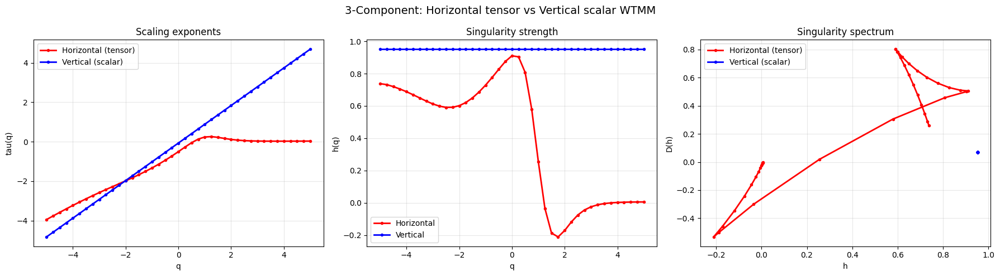

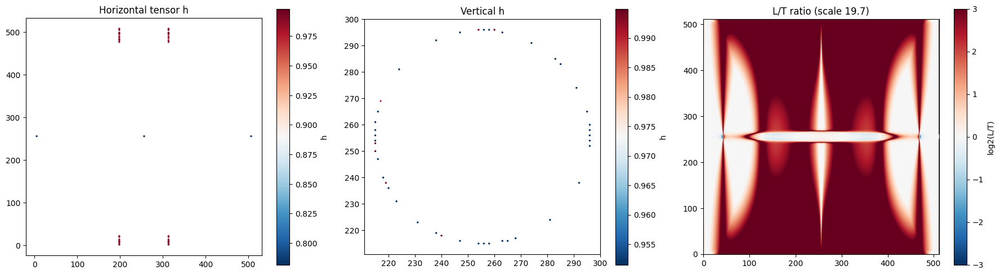

In [ ]:
# Cell 11 - Compare spectra: horizontal tensor vs vertical scalar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tau(q)
axes[0].plot(spectra_tensor['q_list'], spectra_tensor['tau'], 'r.-', label='Horizontal (tensor)', lw=2)
axes[0].plot(spectra_up['q_list'], spectra_up['tau'], 'b.-', label='Vertical (scalar)', lw=2)
axes[0].set(xlabel='q', ylabel='tau(q)', title='Scaling exponents')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# h(q)
axes[1].plot(spectra_tensor['q_list'], spectra_tensor['h'], 'r.-', label='Horizontal', lw=2)
axes[1].plot(spectra_up['q_list'], spectra_up['h'], 'b.-', label='Vertical', lw=2)
axes[1].set(xlabel='q', ylabel='h(q)', title='Singularity strength')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# D(h)
for sp, color, label in [(spectra_tensor, 'red', 'Horizontal (tensor)'),
                          (spectra_up, 'blue', 'Vertical (scalar)')]:
    valid = np.isfinite(sp['D']) & np.isfinite(sp['h'])
    axes[2].plot(sp['h'][valid], sp['D'][valid], '.-', color=color, label=label, lw=2)
axes[2].set(xlabel='h', ylabel='D(h)', title='Singularity spectrum')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('3-Component: Horizontal tensor vs Vertical scalar WTMM', fontsize=14)
plt.tight_layout()
plt.show()

# Holder maps side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, holders, title in [(axes[0], holders_tensor, 'Horizontal tensor h'),
                            (axes[1], holders_up, 'Vertical h')]:
    if holders:
        xs = np.array([h['x'] for h in holders])
        ys = np.array([h['y'] for h in holders])
        hs = np.array([h['h'] for h in holders])
        vmin, vmax = np.nanpercentile(hs, [5, 95])
        sc = ax.scatter(xs, ys, c=hs, cmap='RdBu_r', s=2, vmin=vmin, vmax=vmax)
        plt.colorbar(sc, ax=ax, label='h')
    ax.set_title(title); ax.set_aspect('equal')

# L/T ratio map
mid = len(scales) // 2
lt_ratio = mod_L_all[mid] / (mod_T_all[mid] + 1e-10)
sc = axes[2].imshow(np.log2(lt_ratio + 1e-10), origin='lower', cmap='RdBu_r',
                     vmin=-3, vmax=3, rasterized=True)
plt.colorbar(sc, ax=axes[2], label='log2(L/T)')
axes[2].set_title(f'L/T ratio (scale {scales[mid]:.1f})')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 11a - Select vector field and run full tensor WTMM pipeline
# Change EXPLORE_FIELD to any vector field name from Cell 6
EXPLORE_FIELD = 'multifractal'  # 'fault', 'vortex', 'source', 'multifractal', 'turbulent'

# Also available: 'vertical' for scalar WTMM on v_Up

if EXPLORE_FIELD == 'vertical':
    # Scalar WTMM on vertical component (already computed in Cell 10)
    t_ext_images = ext_images_up
    t_chains = chains_up
    t_holders_fit = holders_up
    t_image = v_Up
    t_label = 'Vertical scalar (v_Up)'
    t_mod_L_all = None
    t_mod_T_all = None
else:
    # Run full tensor WTMM pipeline on selected vector field
    vf = vector_fields[EXPLORE_FIELD]
    vx_field, vy_field = vf
    t_image = np.sqrt(vx_field**2 + vy_field**2)
    t_label = f'Tensor WTMM: {EXPLORE_FIELD}'
    
    print(f'Computing CWT for {EXPLORE_FIELD}...')
    deriv_vx = cwt_2d_f32(vx_field, scales, pad=32, derivs='first', verbose=False)
    deriv_vy = cwt_2d_f32(vy_field, scales, pad=32, derivs='first', verbose=False)
    
    print('Running tensor extrema detection + L/T decomposition...')
    t_ext_images = []
    t_mod_L_all = []
    t_mod_T_all = []
    
    for i, scale in enumerate(scales):
        dx1 = xsm.XImage.from_numpy(deriv_vx['dx'][i])
        dy1 = xsm.XImage.from_numpy(deriv_vx['dy'][i])
        dx2 = xsm.XImage.from_numpy(deriv_vy['dx'][i])
        dy2 = xsm.XImage.from_numpy(deriv_vy['dy'][i])
        
        # Vector NMS: SVD + extrema in one call
        ext, mod_img, arg_img = xsm.wtmm2d_vector(dx1, dy1, dx2, dy2,
                                                    scale, svd_type=xsm.SVD_MAX, thresh=1e-6)
        t_ext_images.append(ext)
        
        # L/T (need fresh copies since wtmm2d_vector modifies inputs)
        dx1b = xsm.XImage.from_numpy(deriv_vx['dx'][i])
        dy1b = xsm.XImage.from_numpy(deriv_vx['dy'][i])
        dx2b = xsm.XImage.from_numpy(deriv_vy['dx'][i])
        dy2b = xsm.XImage.from_numpy(deriv_vy['dy'][i])
        mod_L, mod_T = xsm.tensor_wtmm_2d_LT(dx1b, dy1b, dx2b, dy2b)
        t_mod_L_all.append(mod_L.to_numpy())
        t_mod_T_all.append(mod_T.to_numpy())
    
    print(f'Extrema per octave: {[t_ext_images[i].extr_nb for i in range(0, len(scales), n_vox)]}')
    
    # Chain
    print('Chaining...')
    xsm.chain(t_ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
    t_chains = xsm.extract_vertical_chains(t_ext_images, scales)
    t_holders_fit = xsm.compute_holder_exponents(t_chains)

t_holders_slope = xsm.compute_holder_local_slope(t_chains, method='max')
t_h_fit_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in t_holders_fit}
t_h_slope_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in t_holders_slope}

t_chain_lookup = {}
for ch in t_chains:
    vc_len = len(ch['mod'])
    if vc_len == 0:
        continue
    anchor = (int(ch['x'][0]), int(ch['y'][0]))
    for si in range(min(vc_len, len(scales))):
        t_chain_lookup[(si, int(ch['x'][si]), int(ch['y'][si]))] = (vc_len, anchor)

h_vals = np.array([h['h'] for h in t_holders_fit])
print(f'\n=== {t_label} ===')
print(f'  {len(t_chains)} chains, median h = {np.nanmedian(h_vals):.3f}')
print(f'  h range: [{np.nanpercentile(h_vals, 5):.2f}, {np.nanpercentile(h_vals, 95):.2f}]')
if t_mod_L_all is not None:
    mid = len(scales) // 2
    lt = np.mean(t_mod_L_all[mid]) / (np.mean(t_mod_T_all[mid]) + 1e-10)
    print(f'  L/T ratio (mid scale): {lt:.2f}')

Computing CWT for multifractal...
Running tensor extrema detection + L/T decomposition...
Extrema per octave: [57624, 30314, 15588]
Chaining...

=== Tensor WTMM: multifractal ===
  4953 chains, median h = -0.181
  h range: [-1.08, 0.32]
  L/T ratio (mid scale): 2.29


In [ ]:
# Cell 11b - Precompute tensor chains for interactive viewer
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

t_lines_by_scale = []
t_lines_hfit_by_scale = []
t_lines_hslope_by_scale = []
t_lines_maxvc_by_scale = []

for si in range(len(scales)):
    ext = t_ext_images[si]
    line_list = ext.get_lines()
    lx_ext = ext.lx
    segs, seg_hfit, seg_hslope, seg_maxvc = [], [], [], []
    for line in line_list:
        positions = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(positions) < 2:
            continue
        xs = (positions % lx_ext).astype(np.float64)
        ys = (positions // lx_ext).astype(np.float64)
        segs.append(np.column_stack([xs, ys]))
        max_vc, best_hfit, best_hslope = 0, np.nan, np.nan
        for j in range(len(positions)):
            info = t_chain_lookup.get((si, int(xs[j]), int(ys[j])), (0, None))
            if info[0] > max_vc:
                max_vc = info[0]
                if info[1] is not None:
                    best_hfit = t_h_fit_lookup.get(info[1], np.nan)
                    best_hslope = t_h_slope_lookup.get(info[1], np.nan)
        seg_hfit.append(best_hfit)
        seg_hslope.append(best_hslope)
        seg_maxvc.append(max_vc)
    t_lines_by_scale.append(segs)
    t_lines_hfit_by_scale.append(np.array(seg_hfit, dtype=np.float32))
    t_lines_hslope_by_scale.append(np.array(seg_hslope, dtype=np.float32))
    t_lines_maxvc_by_scale.append(np.array(seg_maxvc, dtype=np.int32))

t_wtmmm_by_scale = []
for si in range(len(scales)):
    ext = t_ext_images[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    if ext.extr_nb == 0:
        t_wtmmm_by_scale.append({'x': np.array([]), 'y': np.array([]),
                                  'mod': np.array([]), 'arg': np.array([])})
        continue
    m = on_vc.astype(bool)
    t_wtmmm_by_scale.append({
        'x': data['x'][m].astype(np.float64),
        'y': data['y'][m].astype(np.float64),
        'mod': data['mod'][m],
        'arg': data['arg'][m],
    })

print(f"Precomputed {sum(len(s) for s in t_lines_by_scale)} line segments, "
      f"{sum(len(w['x']) for w in t_wtmmm_by_scale)} WTMMM arrows")

Precomputed 39215 line segments, 37235 WTMMM arrows


In [ ]:
# Cell 11c - Interactive tensor WTMM viewer
from ipywidgets import interact, IntRangeSlider, IntSlider, Checkbox, Dropdown, FloatSlider, Layout

t_scale_cmap = plt.cm.plasma
t_scale_norm = Normalize(vmin=0, vmax=len(scales)-1)

def t_robust_limits(vals, lo=5, hi=95, default=(-1, 1)):
    return (np.percentile(vals, lo), np.percentile(vals, hi)) if len(vals) > 0 else default

def t_draw(scale_range, min_hchain, min_vc, min_h, h_filter_method,
           color_by, cmap_name, show_mode, show_bg, line_width,
           arrow_scale, log2_arrows):
    fig, ax = plt.subplots(figsize=(10, 10))
    if show_bg:
        ax.imshow(t_image, origin='lower', cmap='gray', rasterized=True,
                  extent=[0, t_image.shape[1], 0, t_image.shape[0]], alpha=0.6)
        ax.set_facecolor('black')
    else:
        ax.set_facecolor('white')

    si_lo, si_hi = scale_range
    si_range = range(si_lo, si_hi + 1)
    n_pts = 0

    if show_mode in ('Horizontal chains', 'Chains + arrows'):
        for si in si_range:
            segs = t_lines_by_scale[si]
            hfit = t_lines_hfit_by_scale[si]
            hslope = t_lines_hslope_by_scale[si]
            maxvc = t_lines_maxvc_by_scale[si]
            if not segs:
                continue
            keep = np.ones(len(segs), dtype=bool)
            for j, seg in enumerate(segs):
                if len(seg) < min_hchain:
                    keep[j] = False
            if min_vc > 0:
                keep &= (maxvc >= min_vc)
            if min_h > -4.9:
                h_ref = hfit if h_filter_method == 'LS fit' else hslope
                keep &= (h_ref >= min_h) | np.isnan(h_ref)
            filtered = [segs[j] for j in range(len(segs)) if keep[j]]
            if not filtered:
                continue
            if color_by in ('h (LS fit)', 'h (max slope)'):
                h_vals = hfit[keep] if color_by == 'h (LS fit)' else hslope[keep]
                valid_h = h_vals[np.isfinite(h_vals)]
                vmin, vmax = t_robust_limits(valid_h, 5, 95) if len(valid_h) > 0 else (-1, 1)
                lc = LineCollection(filtered, cmap=cmap_name,
                                    norm=Normalize(vmin=vmin, vmax=vmax),
                                    linewidths=line_width, alpha=0.8)
                lc.set_array(h_vals)
                ax.add_collection(lc)
                if si == si_range[-1]:
                    plt.colorbar(lc, ax=ax, label=color_by, shrink=0.6)
            else:
                sc_color = t_scale_cmap(t_scale_norm(si))
                lc = LineCollection(filtered, colors=[sc_color]*len(filtered),
                                    linewidths=line_width, alpha=0.8)
                ax.add_collection(lc)
            n_pts += sum(len(s) for s in filtered)

        if show_mode == 'Chains + arrows':
            for si in si_range:
                w = t_wtmmm_by_scale[si]
                if len(w['x']) == 0:
                    continue
                if log2_arrows:
                    lm = np.log2(np.maximum(w['mod'], 1e-30))
                    mn, rng = lm.min(), lm.max() - lm.min()
                    mod_n = (lm - mn) / (rng + 1e-30)
                else:
                    mod_n = w['mod'] / (w['mod'].max() + 1e-30)
                dx_a = np.cos(w['arg']) * mod_n * arrow_scale
                dy_a = np.sin(w['arg']) * mod_n * arrow_scale
                sc_c = t_scale_cmap(t_scale_norm(si))
                step_q = max(1, len(w['x']) // 8000)
                ax.quiver(w['x'][::step_q], w['y'][::step_q],
                          dx_a[::step_q], dy_a[::step_q],
                          color=sc_c, scale_units='xy', scale=1,
                          width=0.003, headwidth=4, headlength=3,
                          headaxislength=2.5, alpha=0.9, zorder=5)

        if color_by == 'scale':
            sm = plt.cm.ScalarMappable(norm=t_scale_norm, cmap=t_scale_cmap)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label='scale index', shrink=0.6)
    else:
        vc_x = np.array([int(ch['x'][0]) for ch in t_chains], dtype=np.int32)
        vc_y = np.array([int(ch['y'][0]) for ch in t_chains], dtype=np.int32)
        vc_len = np.array([len(ch['mod']) for ch in t_chains], dtype=np.int32)
        vc_h = np.array([t_h_fit_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
                         for ch in t_chains], dtype=np.float32)
        mask = vc_len >= max(min_vc, 2)
        if min_h > -4.9:
            mask &= (vc_h >= min_h) | np.isnan(vc_h)
        c = vc_h[mask]; v = ~np.isnan(c)
        xm, ym, c = vc_x[mask][v], vc_y[mask][v], c[v]
        if len(xm) > 0:
            vn, vx = t_robust_limits(c, 5, 95)
            sc = ax.scatter(xm, ym, c=c, s=8, cmap=cmap_name, vmin=vn, vmax=vx, rasterized=True)
            plt.colorbar(sc, ax=ax, label='h', shrink=0.6)
        n_pts = len(xm)

    scope = f'scales {si_lo}-{si_hi} (a={scales[si_lo]:.1f}-{scales[si_hi]:.1f})'
    ax.set_title(f'{t_label} | {show_mode} | {color_by} -- {n_pts} pts ({scope})')
    ny, nx = t_image.shape
    ax.set_xlim(0, nx); ax.set_ylim(0, ny)
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()

interact(
    t_draw,
    scale_range=IntRangeSlider(value=[len(scales)//2, len(scales)//2], min=0, max=len(scales)-1,
                               description='Scale range:', layout=Layout(width='70%'), continuous_update=False),
    min_hchain=IntSlider(value=5, min=1, max=200, step=1,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=0, min=0, max=len(scales), step=1,
                     description='Min vc:', layout=Layout(width='60%'), continuous_update=False),
    min_h=FloatSlider(value=-5.0, min=-5.0, max=5.0, step=0.1,
                      description='Min h:', layout=Layout(width='60%'), continuous_update=False),
    h_filter_method=Dropdown(options=['Max slope', 'LS fit'], value='Max slope', description='h filter:'),
    color_by=Dropdown(options=['scale', 'h (LS fit)', 'h (max slope)'], value='scale', description='Color by:'),
    cmap_name=Dropdown(options=['RdBu_r', 'coolwarm', 'viridis', 'plasma', 'turbo'],
                       value='RdBu_r', description='Colormap:'),
    show_mode=Dropdown(options=['Chains + arrows', 'Horizontal chains', 'VC origin points'],
                       value='Chains + arrows', description='Show:'),
    show_bg=Checkbox(value=True, description='Show image'),
    line_width=FloatSlider(value=0.8, min=0.1, max=3.0, step=0.1,
                           description='Line width:', layout=Layout(width='60%'), continuous_update=False),
    arrow_scale=FloatSlider(value=5.0, min=0.5, max=30.0, step=0.5,
                            description='Arrow scale:', layout=Layout(width='60%'), continuous_update=False),
    log2_arrows=Checkbox(value=False, description='log2(mod) arrows'));

interactive(children=(IntRangeSlider(value=(12, 12), continuous_update=False, description='Scale range:', layo…

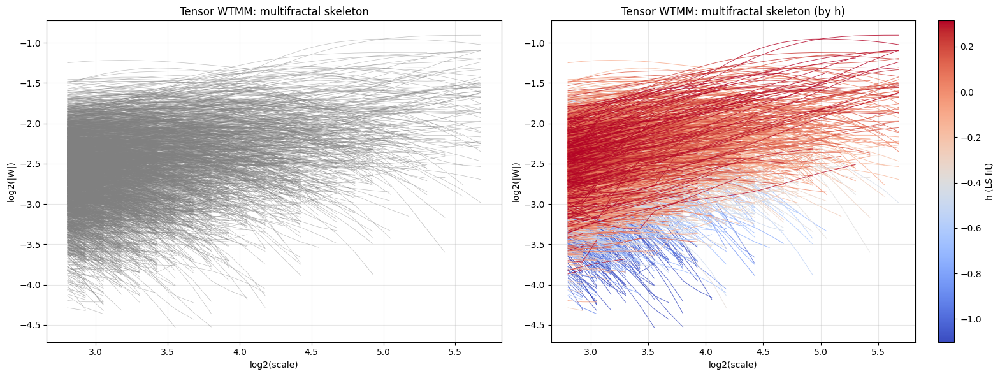

In [ ]:
# Cell 11d - Tensor skeleton plot
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
log2_s = np.log2(scales)

for ch in t_chains[:3000]:
    n = len(ch['mod'])
    if n < 2:
        continue
    lm = np.log2(np.maximum(np.abs(ch['mod']), 1e-30))
    axes[0].plot(log2_s[:n], lm, '-', color='gray', alpha=0.5, lw=0.5)
axes[0].set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'{t_label} skeleton')
axes[0].grid(True, alpha=0.3)

items = []
for ch in t_chains[:3000]:
    n = len(ch['mod'])
    if n < 2:
        continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = t_h_fit_lookup.get(key, np.nan)
    if np.isfinite(h):
        items.append((h, n, np.log2(np.maximum(np.abs(ch['mod']), 1e-30))))

if items:
    items.sort(key=lambda t: t[0])
    hv = np.array([t[0] for t in items])
    vn, vx = np.percentile(hv, [5, 95])
    if vn == vx: vn, vx = hv.min(), hv.max()
    nm = Normalize(vmin=vn, vmax=vx)
    cm = plt.cm.coolwarm
    for h, n, lm in items:
        axes[1].plot(log2_s[:n], lm, '-', color=cm(nm(h)), alpha=0.8, lw=0.7)
    sm = ScalarMappable(norm=nm, cmap=cm); sm.set_array([])
    plt.colorbar(sm, ax=axes[1], label='h (LS fit)')

axes[1].set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'{t_label} skeleton (by h)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 11e - Interactive partition function for tensor WTMM
%matplotlib widget
from IPython.display import display, clear_output
import ipywidgets as widgets
from xsmurf_wrapper.partition import compute_HD_per_scale, extract_hq_Dq_from_plateaus

t_spectra = xsm.compute_spectra(t_ext_images, scales)

# Build per-scale h/D/tau
q_list = t_spectra['q_list']
n_q = len(q_list)
n_sc = len(scales)
log2 = np.log(2.0)

STq = np.zeros((n_q, n_sc), dtype=np.float64)
STqlogT = np.zeros((n_q, n_sc), dtype=np.float64)

for j, ext in enumerate(t_ext_images):
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    mods = []
    for k in range(ext.extr_nb):
        if on_vc[k]:
            m = abs(float(data['mod'][k]))
            if m > 0:
                mods.append(m)
    if not mods:
        continue
    mod = np.array(mods, dtype=np.float64)
    log_mod = np.log(mod)
    for i, q in enumerate(q_list):
        mod_q = mod ** q if q != 0 else np.ones(len(mod))
        STq[i, j] = np.sum(mod_q)
        STqlogT[i, j] = np.sum(log_mod * mod_q)

tau_qa = np.full((n_q, n_sc), np.nan)
h_qa = np.full((n_q, n_sc), np.nan)
D_qa = np.full((n_q, n_sc), np.nan)
valid_Z = STq > 0
tau_qa[valid_Z] = np.log(STq[valid_Z]) / log2
h_qa[valid_Z] = STqlogT[valid_Z] / (log2 * STq[valid_Z])
for i, q in enumerate(q_list):
    for j in range(n_sc):
        if STq[i, j] > 0:
            D_qa[i, j] = (q * STqlogT[i, j] - STq[i, j] * np.log(STq[i, j])) / (STq[i, j] * log2)

hd = {'tau_qa': tau_qa, 'h_qa': h_qa, 'D_qa': D_qa,
      'q_list': q_list, 'scales': np.array(scales),
      'log2_scales': np.log2(np.array(scales))}

fit_state = {'scale_min': scales[0], 'scale_max': scales[-1]}
log2_s = hd['log2_scales']

output_pf = widgets.Output()
output_sp = widgets.Output()

q_show = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def draw_all():
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (np.array(scales) >= smin) & (np.array(scales) <= smax)

    with output_pf:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
            ax = axes[panel]
            for qi, color in zip(q_show, colors_q):
                idx = np.argmin(np.abs(hd['q_list'] - qi))
                y = hd[key][idx]; v = np.isfinite(y)
                if v.sum() < 2: continue
                ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')
                yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
                if vf.sum() >= 2:
                    try:
                        sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                        xl = log2_s[v]
                        ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                        ax.text(xl[-1]+0.05, sl*xl[-1]+ic, f'{qi:g}', color=color, fontsize=7, va='center')
                    except: pass
            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
            ax.grid(True, alpha=0.2)
        fig.suptitle(f'{t_label} -- L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()

        def on_click(event):
            if event.inaxes is None or event.xdata is None: return
            a = 2 ** event.xdata
            if event.button == 1: fit_state['scale_min'] = a
            elif event.button == 3: fit_state['scale_max'] = a
            if fit_state['scale_min'] > fit_state['scale_max']:
                fit_state['scale_min'], fit_state['scale_max'] = fit_state['scale_max'], fit_state['scale_min']
            draw_all()
        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

    if s_mask.sum() < 2: return
    res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
    q = res['q_list']
    valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

    with output_sp:
        clear_output(wait=True)
        if not valid.any():
            print("No valid spectra"); return
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax1 = axes[0]
        ax1.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                     fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
        ax1.set(xlabel='q', ylabel='tau(q)')
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)
        ax2 = ax1.twinx()
        ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                     fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
        ax2.set(ylabel='h(q)')
        ax2.tick_params(axis='y', labelcolor='red')
        h_w = res['h'][valid].max() - res['h'][valid].min()
        ax1.set_title(f'tau(q) & h(q) -- dh={h_w:.3f}')
        l1, lb1 = ax1.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8)

        ax = axes[1]
        sc = ax.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                        s=60, edgecolors='black', linewidths=0.5, zorder=5)
        ax.errorbar(res['h'][valid], res['D'][valid],
                    xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                    fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)
        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        pk = np.argmax(res['D'][valid])
        ax.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
        ax.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                    xy=(res['h'][valid][pk], res['D'][valid][pk]),
                    xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', fc='lightyellow'))
        ax.set(xlabel='h', ylabel='D(h)', title=f'D(h) -- {t_label}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
        fig.tight_layout(); plt.show()

print("LEFT-click = min scale | RIGHT-click = max scale")
display(output_pf)
display(output_sp)
draw_all()

LEFT-click = min scale | RIGHT-click = max scale


Output()

Output()

In [ ]:
# Cell 12a - Synthetic conjugate fault system (3-component velocity field)
# Two conjugate fault planes at +/-30 from north, with strike-slip + vertical component
# Models a compressional regime with E-W shortening producing conjugate shear zones

def fault_velocity(X, Y, fault_x, fault_y, fault_angle, slip_rate, width=0.02, h_exponent=0.5):
    """Velocity field for a single fault with power-law singularity.
    
    fault_angle: angle of fault trace from x-axis (radians)
    slip_rate: magnitude of slip
    h_exponent: Holder exponent of the singularity (0=step, 0.5=cusp)
    """
    nx_f = -np.sin(fault_angle)
    ny_f = np.cos(fault_angle)
    d = (X - fault_x) * nx_f + (Y - fault_y) * ny_f  # signed perpendicular distance
    sx = np.cos(fault_angle)
    sy = np.sin(fault_angle)
    profile = np.sign(d) * (np.abs(d) + np.float32(0.001)) ** h_exponent
    along = (X - fault_x) * sx + (Y - fault_y) * sy
    taper = np.exp(-along**2 / np.float32(0.25))
    vx = (slip_rate * sx * profile * taper).astype(np.float32)
    vy = (slip_rate * sy * profile * taper).astype(np.float32)
    return vx, vy

# Conjugate pair at +/-30 from N
vx1, vy1 = fault_velocity(X, Y, -0.15, 0.1, np.radians(60), 1.0, h_exponent=0.3)
vx2, vy2 = fault_velocity(X, Y, 0.15, -0.1, np.radians(120), 0.8, h_exponent=0.3)
vx3, vy3 = fault_velocity(X, Y, 0.0, 0.3, np.radians(45), 0.3, h_exponent=0.5)

# Background: E-W shortening + N-S extension (pure shear)
bg_vx = np.float32(-0.05) * X
bg_vy = np.float32(0.05) * Y

conj_vNS = (vy1 + vy2 + vy3 + bg_vy).astype(np.float32)
conj_vEW = (vx1 + vx2 + vx3 + bg_vx).astype(np.float32)

# Vertical: oblique slip on each fault (reverse component = uplift on hanging wall)
# Each fault has a dip-slip component proportional to the strike-slip
# For conjugate thrust-strike-slip: rake ~ 30 deg from horizontal
# v_up across fault = slip_rate * sin(rake) * same singularity profile
rake = np.radians(20)  # 20 deg from horizontal = mostly strike-slip with reverse component

def fault_vertical(X, Y, fault_x, fault_y, fault_angle, slip_rate, h_exponent):
    """Vertical (reverse) component of oblique slip on a fault."""
    nx_f = -np.sin(fault_angle)
    ny_f = np.cos(fault_angle)
    d = (X - fault_x) * nx_f + (Y - fault_y) * ny_f
    along = (X - fault_x) * np.cos(fault_angle) + (Y - fault_y) * np.sin(fault_angle)
    taper = np.exp(-along**2 / np.float32(0.25))
    # Reverse sense: positive on one side (hanging wall up), negative on other
    profile = np.sign(d) * (np.abs(d) + np.float32(0.001)) ** h_exponent
    return (slip_rate * np.sin(rake) * profile * taper).astype(np.float32)

vz1 = fault_vertical(X, Y, -0.15, 0.1, np.radians(60), 1.0, 0.3)
vz2 = fault_vertical(X, Y, 0.15, -0.1, np.radians(120), 0.8, 0.3)
vz3 = fault_vertical(X, Y, 0.0, 0.3, np.radians(45), 0.3, 0.5)
conj_vUp = (vz1 + vz2 + vz3).astype(np.float32)

# Add fBm noise
conj_vNS = (conj_vNS + generate_fbm_numpy(N, 0.6, seed=500) * 0.02).astype(np.float32)
conj_vEW = (conj_vEW + generate_fbm_numpy(N, 0.6, seed=501) * 0.02).astype(np.float32)
conj_vUp = (conj_vUp + generate_fbm_numpy(N, 0.7, seed=502) * 0.01).astype(np.float32)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, (img, title) in zip(axes[0], [
    (conj_vNS, 'v_NS'), (conj_vEW, 'v_EW'), (conj_vUp, 'v_Up')]):
    sc = ax.imshow(img, origin='lower', cmap='RdBu_r', rasterized=True)
    plt.colorbar(sc, ax=ax); ax.set_title(title); ax.axis('off')

horiz_speed = np.sqrt(conj_vNS**2 + conj_vEW**2)
axes[1, 0].imshow(horiz_speed, origin='lower', cmap='hot', rasterized=True)
axes[1, 0].set_title('|v_horiz|'); axes[1, 0].axis('off')

# Deformation gradient tensor components (L = grad v)
# Use finite differences for visualization (CWT derivatives are scale-dependent)
dvNS_dx = np.gradient(conj_vNS, axis=1).astype(np.float32)  # d(vNS)/dx
dvNS_dy = np.gradient(conj_vNS, axis=0).astype(np.float32)  # d(vNS)/dy
dvEW_dx = np.gradient(conj_vEW, axis=1).astype(np.float32)  # d(vEW)/dx
dvEW_dy = np.gradient(conj_vEW, axis=0).astype(np.float32)  # d(vEW)/dy

# Strain rate (symmetric part): e_xx, e_yy, e_xy
e_xx = dvEW_dx
e_yy = dvNS_dy
e_xy = np.float32(0.5) * (dvEW_dy + dvNS_dx)
# Vorticity (antisymmetric part)
omega = np.float32(0.5) * (dvEW_dy - dvNS_dx)

# Plot strain rate invariant (second invariant = effective strain rate)
strain_rate = np.sqrt(e_xx**2 + e_yy**2 + np.float32(2) * e_xy**2)
axes[1, 1].imshow(strain_rate, origin='lower', cmap='magma', rasterized=True)
axes[1, 1].set_title('Strain rate magnitude'); axes[1, 1].axis('off')

# Vorticity (rotation rate)
v_lim = np.nanpercentile(np.abs(omega), 98)
axes[1, 2].imshow(omega, origin='lower', cmap='RdBu_r', vmin=-v_lim, vmax=v_lim, rasterized=True)
axes[1, 2].set_title('Vorticity (curl/2)'); axes[1, 2].axis('off')

plt.suptitle('Conjugate fault system (h=0.3, +/-30 from N)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12b - 3x2 Tensor WTMM with SVD on conjugate fault system

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

# Ensure scales are defined (in case cells ran out of order)
if 'scales' not in dir():
    n_oct = 3
    n_vox = 8
    scales = compute_scales(n_oct, n_vox)
    print(f'{len(scales)} scales: [{scales[0]:.1f}, {scales[-1]:.1f}]')

print('Computing CWT for 3 components...')
deriv_NS = cwt_2d_f32(conj_vNS, scales, pad=32, derivs='first', verbose=False)
deriv_EW = cwt_2d_f32(conj_vEW, scales, pad=32, derivs='first', verbose=False)
deriv_Up = cwt_2d_f32(conj_vUp, scales, pad=32, derivs='first', verbose=False)

print('3x2 SVD + NMS extrema...')
t_ext_images = []
t_sigma_max_all = []
t_sigma_min_all = []

for i, scale in enumerate(scales):
    sigma_max, sigma_min, arg_svd = tensor_svd_3x2(
        deriv_NS['dx'][i], deriv_NS['dy'][i],
        deriv_EW['dx'][i], deriv_EW['dy'][i],
        deriv_Up['dx'][i], deriv_Up['dy'][i])
    t_sigma_max_all.append(sigma_max)
    t_sigma_min_all.append(sigma_min)
    dx_svd = (sigma_max * np.cos(arg_svd)).astype(np.float32)
    dy_svd = (sigma_max * np.sin(arg_svd)).astype(np.float32)
    ext, _, _ = xsm.wtmm2d(
        xsm.XImage.from_numpy(dx_svd),
        xsm.XImage.from_numpy(dy_svd),
        scale, thresh=1e-6)
    t_ext_images.append(ext)

print(f'Extrema per octave: {[t_ext_images[i].extr_nb for i in range(0, len(scales), n_vox)]}')

for i in range(len(t_ext_images)):
    t_ext_images[i] = xsm.cut_edge(t_ext_images[i], border_percent=0.80)

print('Chaining...')
xsm.chain(t_ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
t_chains = xsm.extract_vertical_chains(t_ext_images, scales)
t_holders_fit = xsm.compute_holder_exponents(t_chains)

h_vals = np.array([h['h'] for h in t_holders_fit])
print(f'\n=== 3x2 Tensor WTMM on conjugate faults ===')
print(f'  {len(t_chains)} chains, median h = {np.nanmedian(h_vals):.3f}')
print(f'  h range (5-95%): [{np.nanpercentile(h_vals, 5):.2f}, {np.nanpercentile(h_vals, 95):.2f}]')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
show_si = [0, len(scales)//3, 2*len(scales)//3]
for col, si in enumerate(show_si):
    axes[0, col].imshow(t_sigma_max_all[si], origin='lower', cmap='hot', rasterized=True)
    axes[0, col].set_title(f'sigma_max a={scales[si]:.1f}'); axes[0, col].axis('off')
    axes[1, col].imshow(t_sigma_min_all[si], origin='lower', cmap='hot', rasterized=True)
    axes[1, col].set_title(f'sigma_min a={scales[si]:.1f}'); axes[1, col].axis('off')
plt.suptitle('3x2 Tensor WTMM: singular values', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12c - Spectra and Holder map for conjugate faults
spectra_conj = xsm.compute_spectra(t_ext_images, scales)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
q_show = np.arange(-3, 4, 1.0)
for q in q_show:
    qi = np.argmin(np.abs(spectra_conj['q_list'] - q))
    axes[0].plot(spectra_conj['log2_scales'], spectra_conj['log2_Z'][qi], '.-',
                 label=f'q={q:.0f}', lw=1)
axes[0].set(xlabel='log2(a)', ylabel='log2(Z)', title='Z(q,a)')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)

axes[1].errorbar(spectra_conj['q_list'], spectra_conj['tau'],
                 yerr=spectra_conj['tau_err'], fmt='.-', capsize=2)
axes[1].set(xlabel='q', ylabel='tau(q)', title='tau(q)'); axes[1].grid(True, alpha=0.3)

axes[2].plot(spectra_conj['q_list'], spectra_conj['h'], '.-')
axes[2].set(xlabel='q', ylabel='h(q)', title='h(q)'); axes[2].grid(True, alpha=0.3)

valid = np.isfinite(spectra_conj['D']) & np.isfinite(spectra_conj['h'])
axes[3].plot(spectra_conj['h'][valid], spectra_conj['D'][valid], '.-')
axes[3].set(xlabel='h', ylabel='D(h)', title='D(h)'); axes[3].grid(True, alpha=0.3)

plt.suptitle('Conjugate faults: 3x2 tensor WTMM spectrum', fontsize=14)
plt.tight_layout()
plt.show()

# Holder map
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(np.sqrt(conj_vNS**2 + conj_vEW**2), origin='lower', cmap='gray',
               alpha=0.5, rasterized=True)
long_ch = [(h, ch) for h, ch in zip(t_holders_fit, t_chains) if len(ch['mod']) >= 5]
if long_ch:
    xs = np.array([h['x'] for h, _ in long_ch])
    ys = np.array([h['y'] for h, _ in long_ch])
    hs = np.array([h['h'] for h, _ in long_ch])
    vmin, vmax = np.nanpercentile(hs, [5, 95])
    sc = axes[0].scatter(xs, ys, c=hs, cmap='RdBu_r', s=3, vmin=vmin, vmax=vmax, alpha=0.7)
    plt.colorbar(sc, ax=axes[0], label='h')
axes[0].set_title(f'Holder map ({len(long_ch)} chains >= 5 scales)'); axes[0].axis('off')

axes[1].hist(h_vals[np.isfinite(h_vals)], bins=150, color='steelblue', edgecolor='k', alpha=0.7)
axes[1].axvline(0.3, color='red', ls='--', lw=2, label='Expected h=0.3')
axes[1].axvline(np.nanmedian(h_vals), color='orange', ls='--', lw=2,
                label=f'Median h={np.nanmedian(h_vals):.2f}')
axes[1].set(xlabel='h', ylabel='count', title='Holder distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12d - Manifold-based conjugate fracture system (3D deformation, surface observation)
# 
# The deformation gradient F defines the full 3D flow. Fractures develop along
# the manifolds (eigenvectors) of the velocity gradient L = dv/dx.
# We observe only the SURFACE velocity (v_x, v_y, v_z at z=0).
#
# Following Hobbs & Ord Fig 2.3/8.14: an affine deformation + localized 
# nonlinear shear zones that develop along the unstable/stable manifolds.

N = 512
x = np.linspace(-1, 1, N, dtype=np.float32)
X, Y = np.meshgrid(x, x)

# --- 3D velocity gradient tensor L (observed at z=0 surface) ---
# Pure shear with simple shear component (transpression):
#   L = [[L_xx, L_xy, L_xz],
#        [L_yx, L_yy, L_yz],
#        [L_zx, L_zy, L_zz]]
#
# Isochoric (det=1): L_xx + L_yy + L_zz = 0
# Transpression: E-W shortening + N-S extension + vertical thickening + shear

# Background velocity gradient (uniform, 3D)
L_xx = np.float32(-0.8)   # E-W shortening
L_yy = np.float32(0.5)    # N-S extension
L_zz = np.float32(0.3)    # vertical thickening (isochoric: Lxx+Lyy+Lzz=0)
L_xy = np.float32(0.3)    # simple shear component (makes manifolds non-orthogonal)
L_yx = np.float32(0.1)    # asymmetric shear
L_xz = np.float32(0.0)    # no vertical shear in x
L_yz = np.float32(0.0)    # no vertical shear in y
L_zx = np.float32(0.05)   # slight vertical coupling
L_zy = np.float32(-0.03)  # slight vertical coupling

# 2D surface velocity gradient (what we observe at z=0)
# v_x(x,y) = L_xx * x + L_xy * y  (+ nonlinear terms)
# v_y(x,y) = L_yx * x + L_yy * y
# v_z(x,y) = L_zx * x + L_zy * y + L_zz * 0 (z=0 at surface)

# Compute eigenvectors of the 2D surface velocity gradient
L_2d = np.array([[L_xx, L_xy], [L_yx, L_yy]], dtype=np.float64)
eigvals, eigvecs = np.linalg.eig(L_2d)
print(f"2D velocity gradient eigenvalues: {eigvals}")
print(f"Eigenvector 1 (unstable manifold): {eigvecs[:,0]}")
print(f"Eigenvector 2 (stable manifold): {eigvecs[:,1]}")

# Manifold angles
theta_unstable = np.arctan2(eigvecs[1,0], eigvecs[0,0])
theta_stable = np.arctan2(eigvecs[1,1], eigvecs[0,1])
print(f"Unstable manifold angle: {np.degrees(theta_unstable):.1f} deg")
print(f"Stable manifold angle: {np.degrees(theta_stable):.1f} deg")

# --- Nonlinear localization: fractures along manifolds ---
# Add power-law singularities (h=0.3) along lines parallel to each manifold
# These represent strain localization into conjugate shear zones

def manifold_fracture(X, Y, center_x, center_y, angle, slip_rate, h_exp, n_fractures=3, spacing=0.3):
    """Create a set of parallel fractures along a manifold direction."""
    vx_total = np.zeros_like(X)
    vy_total = np.zeros_like(Y)
    nx_f = -np.sin(angle)
    ny_f = np.cos(angle)
    sx = np.cos(angle)
    sy = np.sin(angle)
    for k in range(n_fractures):
        offset = (k - n_fractures // 2) * spacing
        cx = center_x + offset * nx_f
        cy = center_y + offset * ny_f
        d = (X - cx) * nx_f + (Y - cy) * ny_f
        along = (X - cx) * sx + (Y - cy) * sy
        taper = np.exp(-along**2 / np.float32(0.4))
        profile = np.sign(d) * (np.abs(d) + np.float32(0.001)) ** h_exp
        slip_var = slip_rate * (1.0 - 0.3 * abs(k - n_fractures // 2))
        vx_total += slip_var * sx * profile * taper
        vy_total += slip_var * sy * profile * taper
    return vx_total.astype(np.float32), vy_total.astype(np.float32)

# Fractures along unstable manifold (extensional fractures / normal faults in 3D)
vx_u, vy_u = manifold_fracture(X, Y, 0.0, 0.0, theta_unstable, 0.8, 0.3,
                                 n_fractures=4, spacing=0.25)
# Fractures along stable manifold (compressional / thrust in 3D)
vx_s, vy_s = manifold_fracture(X, Y, 0.0, 0.0, theta_stable, 0.6, 0.3,
                                 n_fractures=3, spacing=0.3)

# Combine: background linear flow + nonlinear fracture localization
man_vEW = (L_xx * X + L_xy * Y + vx_u + vx_s).astype(np.float32)
man_vNS = (L_yx * X + L_yy * Y + vy_u + vy_s).astype(np.float32)

# Vertical: from 3D gradient + oblique slip on fractures
# Background vertical at surface: v_z = L_zx * x + L_zy * y
# Fracture vertical: reverse component proportional to horizontal slip
rake = np.radians(25)
def fracture_vertical(X, Y, center_x, center_y, angle, slip_rate, h_exp, n_fractures, spacing):
    vz = np.zeros_like(X)
    nx_f = -np.sin(angle)
    ny_f = np.cos(angle)
    for k in range(n_fractures):
        offset = (k - n_fractures // 2) * spacing
        cx = center_x + offset * nx_f
        cy = center_y + offset * ny_f
        d = (X - cx) * nx_f + (Y - cy) * ny_f
        along = (X - cx) * np.cos(angle) + (Y - cy) * np.sin(angle)
        taper = np.exp(-along**2 / np.float32(0.4))
        profile = np.sign(d) * (np.abs(d) + np.float32(0.001)) ** h_exp
        slip_var = slip_rate * (1.0 - 0.3 * abs(k - n_fractures // 2))
        vz += slip_var * np.sin(rake) * profile * taper
    return vz.astype(np.float32)

vz_u = fracture_vertical(X, Y, 0.0, 0.0, theta_unstable, 0.8, 0.3, 4, 0.25)
vz_s = fracture_vertical(X, Y, 0.0, 0.0, theta_stable, 0.6, 0.3, 3, 0.3)
man_vUp = (L_zx * X + L_zy * Y + vz_u + vz_s).astype(np.float32)

# Add noise
man_vEW = (man_vEW + generate_fbm_numpy(N, 0.6, seed=600) * 0.015).astype(np.float32)
man_vNS = (man_vNS + generate_fbm_numpy(N, 0.6, seed=601) * 0.015).astype(np.float32)
man_vUp = (man_vUp + generate_fbm_numpy(N, 0.7, seed=602) * 0.008).astype(np.float32)

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (img, title) in zip(axes[0], [
    (man_vEW, 'v_EW (x)'), (man_vNS, 'v_NS (y)'), (man_vUp, 'v_Up (z)')]):
    sc = ax.imshow(img, origin='lower', cmap='RdBu_r', rasterized=True)
    plt.colorbar(sc, ax=ax); ax.set_title(title); ax.axis('off')

# Strain rate from finite differences
dvEW_dx = np.gradient(man_vEW, axis=1)
dvEW_dy = np.gradient(man_vEW, axis=0)
dvNS_dx = np.gradient(man_vNS, axis=1)
dvNS_dy = np.gradient(man_vNS, axis=0)
e_xx = dvEW_dx
e_yy = dvNS_dy
e_xy = 0.5 * (dvEW_dy + dvNS_dx)
omega = 0.5 * (dvEW_dy - dvNS_dx)
strain_rate = np.sqrt(e_xx**2 + e_yy**2 + 2 * e_xy**2)

axes[1, 0].imshow(np.sqrt(man_vEW**2 + man_vNS**2), origin='lower', cmap='hot', rasterized=True)
axes[1, 0].set_title('|v_horiz|'); axes[1, 0].axis('off')

axes[1, 1].imshow(strain_rate, origin='lower', cmap='magma', rasterized=True)
# Overlay manifold directions
cx, cy = N//2, N//2
L_arrow = N * 0.35
for ev, color, label in [(0, 'cyan', 'unstable'), (1, 'lime', 'stable')]:
    dx_m = eigvecs[0, ev] * L_arrow
    dy_m = eigvecs[1, ev] * L_arrow
    axes[1, 1].annotate('', xy=(cx+dx_m, cy+dy_m), xytext=(cx-dx_m, cy-dy_m),
                         arrowprops=dict(arrowstyle='->', color=color, lw=2))
    axes[1, 1].text(cx+dx_m*1.05, cy+dy_m*1.05, label, color=color, fontsize=9, fontweight='bold')
axes[1, 1].set_title('Strain rate + manifolds'); axes[1, 1].axis('off')

v_lim = np.nanpercentile(np.abs(omega), 98)
axes[1, 2].imshow(omega, origin='lower', cmap='RdBu_r', vmin=-v_lim, vmax=v_lim, rasterized=True)
axes[1, 2].set_title('Vorticity'); axes[1, 2].axis('off')

plt.suptitle(f'Manifold-based conjugate fractures (3D L, surface obs)\n'
             f'Unstable: {np.degrees(theta_unstable):.0f} deg, '
             f'Stable: {np.degrees(theta_stable):.0f} deg', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12e - 3x2 Tensor WTMM on manifold-based fractures

if 'scales' not in dir():
    n_oct = 3
    n_vox = 8
    scales = compute_scales(n_oct, n_vox)

print('Computing CWT for manifold fracture system...')
deriv_NS_m = cwt_2d_f32(man_vNS, scales, pad=32, derivs='first', verbose=False)
deriv_EW_m = cwt_2d_f32(man_vEW, scales, pad=32, derivs='first', verbose=False)
deriv_Up_m = cwt_2d_f32(man_vUp, scales, pad=32, derivs='first', verbose=False)

print('3x2 SVD + NMS...')
m_ext_images = []
m_sigma_max_all = []

for i, scale in enumerate(scales):
    sigma_max, sigma_min, arg_svd = tensor_svd_3x2(
        deriv_NS_m['dx'][i], deriv_NS_m['dy'][i],
        deriv_EW_m['dx'][i], deriv_EW_m['dy'][i],
        deriv_Up_m['dx'][i], deriv_Up_m['dy'][i])
    m_sigma_max_all.append(sigma_max)
    dx_svd = (sigma_max * np.cos(arg_svd)).astype(np.float32)
    dy_svd = (sigma_max * np.sin(arg_svd)).astype(np.float32)
    ext, _, _ = xsm.wtmm2d(
        xsm.XImage.from_numpy(dx_svd),
        xsm.XImage.from_numpy(dy_svd),
        scale, thresh=1e-6)
    m_ext_images.append(ext)

print(f'Extrema per octave: {[m_ext_images[i].extr_nb for i in range(0, len(scales), n_vox)]}')

# Cut edges
try:
    for i in range(len(m_ext_images)):
        m_ext_images[i] = xsm.cut_edge(m_ext_images[i], border_percent=0.80)
except AttributeError:
    print("WARNING: cut_edge not available, rebuild wrapper. Skipping edge cut.")

print('Chaining...')
xsm.chain(m_ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox, verbose=False)
m_chains = xsm.extract_vertical_chains(m_ext_images, scales)
m_holders = xsm.compute_holder_exponents(m_chains)

h_m = np.array([h['h'] for h in m_holders])
print(f'\n=== Manifold fractures: 3x2 tensor WTMM ===')
print(f'  {len(m_chains)} chains, median h = {np.nanmedian(h_m):.3f}')

# Spectra
spectra_man = xsm.compute_spectra(m_ext_images, scales)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
q_show = np.arange(-3, 4, 1.0)
for q in q_show:
    qi = np.argmin(np.abs(spectra_man['q_list'] - q))
    axes[0].plot(spectra_man['log2_scales'], spectra_man['log2_Z'][qi], '.-',
                 label=f'q={q:.0f}', lw=1)
axes[0].set(xlabel='log2(a)', ylabel='log2(Z)', title='Z(q,a)')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)

axes[1].plot(spectra_man['q_list'], spectra_man['tau'], '.-')
axes[1].set(xlabel='q', ylabel='tau(q)', title='tau(q)'); axes[1].grid(True, alpha=0.3)

axes[2].plot(spectra_man['q_list'], spectra_man['h'], '.-')
axes[2].set(xlabel='q', ylabel='h(q)', title='h(q)'); axes[2].grid(True, alpha=0.3)

valid = np.isfinite(spectra_man['D']) & np.isfinite(spectra_man['h'])
axes[3].plot(spectra_man['h'][valid], spectra_man['D'][valid], '.-')
axes[3].set(xlabel='h', ylabel='D(h)', title='D(h)'); axes[3].grid(True, alpha=0.3)

plt.suptitle('Manifold fractures: 3x2 tensor WTMM spectrum', fontsize=14)
plt.tight_layout()
plt.show()

# Holder map with manifold directions overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(strain_rate, origin='lower', cmap='gray', alpha=0.5, rasterized=True)
long_ch = [(h, ch) for h, ch in zip(m_holders, m_chains) if len(ch['mod']) >= 5]
if long_ch:
    xs = np.array([h['x'] for h, _ in long_ch])
    ys = np.array([h['y'] for h, _ in long_ch])
    hs = np.array([h['h'] for h, _ in long_ch])
    vmin, vmax = np.nanpercentile(hs, [5, 95])
    sc = axes[0].scatter(xs, ys, c=hs, cmap='RdBu_r', s=3, vmin=vmin, vmax=vmax, alpha=0.7)
    plt.colorbar(sc, ax=axes[0], label='h')
    # Overlay manifolds
    cx, cy = N//2, N//2
    L_a = N * 0.35
    for ev, color in [(0, 'cyan'), (1, 'lime')]:
        dx_m = eigvecs[0, ev] * L_a
        dy_m = eigvecs[1, ev] * L_a
        axes[0].plot([cx-dx_m, cx+dx_m], [cy-dy_m, cy+dy_m], color=color, lw=2, ls='--')
axes[0].set_title(f'Holder map + manifolds ({len(long_ch)} chains)'); axes[0].axis('off')

axes[1].hist(h_m[np.isfinite(h_m)], bins=150, color='steelblue', edgecolor='k', alpha=0.7)
axes[1].axvline(0.3, color='red', ls='--', lw=2, label='Expected h=0.3')
axes[1].axvline(np.nanmedian(h_m), color='orange', ls='--', lw=2,
                label=f'Median h={np.nanmedian(h_m):.2f}')
axes[1].set(xlabel='h', ylabel='count', title='Holder distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12f - Interactive partition function fitting for manifold fractures
%matplotlib widget
from IPython.display import display, clear_output
import ipywidgets as widgets
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Build per-scale h/D/tau from the manifold fracture results
q_list = spectra_man['q_list']
n_q_m = len(q_list)
n_sc_m = len(scales)
log2_val = np.log(2.0)

STq_m = np.zeros((n_q_m, n_sc_m), dtype=np.float64)
STqlogT_m = np.zeros((n_q_m, n_sc_m), dtype=np.float64)

for j, ext in enumerate(m_ext_images):
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    mods = []
    for k in range(ext.extr_nb):
        if on_vc[k]:
            m = abs(float(data['mod'][k]))
            if m > 0:
                mods.append(m)
    if not mods:
        continue
    mod = np.array(mods, dtype=np.float64)
    log_mod = np.log(mod)
    for i, q in enumerate(q_list):
        mod_q = mod ** q if q != 0 else np.ones(len(mod))
        STq_m[i, j] = np.sum(mod_q)
        STqlogT_m[i, j] = np.sum(log_mod * mod_q)

tau_qa = np.full((n_q_m, n_sc_m), np.nan)
h_qa = np.full((n_q_m, n_sc_m), np.nan)
D_qa = np.full((n_q_m, n_sc_m), np.nan)
valid_Z = STq_m > 0
tau_qa[valid_Z] = np.log(STq_m[valid_Z]) / log2_val
h_qa[valid_Z] = STqlogT_m[valid_Z] / (log2_val * STq_m[valid_Z])
for i, q in enumerate(q_list):
    for j in range(n_sc_m):
        if STq_m[i, j] > 0:
            D_qa[i, j] = (q * STqlogT_m[i, j] - STq_m[i, j] * np.log(STq_m[i, j])) / (STq_m[i, j] * log2_val)

hd_man = {'tau_qa': tau_qa, 'h_qa': h_qa, 'D_qa': D_qa,
           'q_list': q_list, 'scales': np.array(scales),
           'log2_scales': np.log2(np.array(scales))}

fit_state = {'scale_min': scales[0], 'scale_max': scales[-1]}
log2_s = hd_man['log2_scales']

output_pf = widgets.Output()
output_sp = widgets.Output()

q_show = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def draw_all():
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (np.array(scales) >= smin) & (np.array(scales) <= smax)

    with output_pf:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
            ax = axes[panel]
            for qi, color in zip(q_show, colors_q):
                idx = np.argmin(np.abs(hd_man['q_list'] - qi))
                y = hd_man[key][idx]; v = np.isfinite(y)
                if v.sum() < 2: continue
                ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')
                yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
                if vf.sum() >= 2:
                    try:
                        sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                        xl = log2_s[v]
                        ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                        ax.text(xl[-1]+0.05, sl*xl[-1]+ic, f'{qi:g}', color=color, fontsize=7, va='center')
                    except: pass
            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
            ax.grid(True, alpha=0.2)
        fig.suptitle(f'Manifold fractures -- L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()

        def on_click(event):
            if event.inaxes is None or event.xdata is None: return
            a = 2 ** event.xdata
            if event.button == 1: fit_state['scale_min'] = a
            elif event.button == 3: fit_state['scale_max'] = a
            if fit_state['scale_min'] > fit_state['scale_max']:
                fit_state['scale_min'], fit_state['scale_max'] = fit_state['scale_max'], fit_state['scale_min']
            draw_all()
        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

    if s_mask.sum() < 2: return
    res = extract_hq_Dq_from_plateaus(hd_man, scale_range=(smin, smax))
    q = res['q_list']
    valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

    with output_sp:
        clear_output(wait=True)
        if not valid.any():
            print("No valid spectra"); return
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax1 = axes[0]
        ax1.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                     fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
        ax1.set(xlabel='q', ylabel='tau(q)')
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)
        ax2 = ax1.twinx()
        ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                     fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
        ax2.set(ylabel='h(q)')
        ax2.tick_params(axis='y', labelcolor='red')
        h_w = res['h'][valid].max() - res['h'][valid].min()
        ax1.set_title(f'tau(q) & h(q) -- dh={h_w:.3f}')
        l1, lb1 = ax1.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8)

        ax = axes[1]
        sc = ax.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                        s=60, edgecolors='black', linewidths=0.5, zorder=5)
        ax.errorbar(res['h'][valid], res['D'][valid],
                    xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                    fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)
        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        pk = np.argmax(res['D'][valid])
        ax.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
        ax.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                    xy=(res['h'][valid][pk], res['D'][valid][pk]),
                    xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', fc='lightyellow'))
        ax.set(xlabel='h', ylabel='D(h)', title='D(h) -- manifold fractures')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
        fig.tight_layout(); plt.show()

print("LEFT-click = min scale | RIGHT-click = max scale")
display(output_pf)
display(output_sp)
draw_all()

Ascending InSAR: 1052 x 475
  Location: 30.00N, 83.71E (Nepal/Tibet)
  Pixel size: 0.1 x 0.1 km
  LOS vector (mean): E=-0.686, N=-0.120, U=0.718
  Velocity range: [-33.4, 25.2] mm/yr


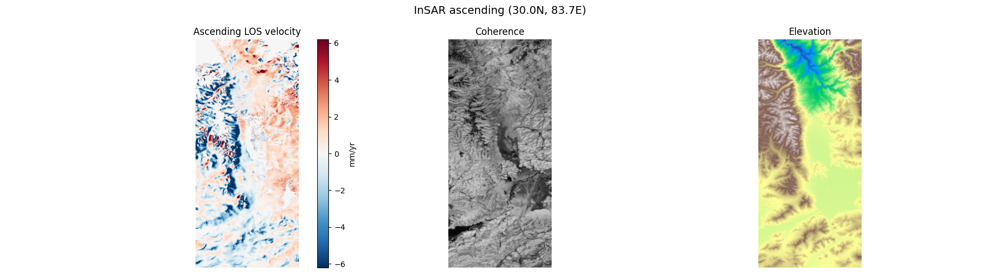


Descending loaded: Descending_cum_filt.h5, shape=(1052, 475)
  LOS vector: E=0.691, N=-0.120, U=0.713

>>> Both ascending + descending available! Can decompose to E-W + Up.


In [ ]:
# Cell 13a - Load real InSAR data (Nepal/Tibet ascending)
# LiCSBAS cumulative filtered output
# Once descending arrives: decompose to E-W + Up for tensor WTMM
import h5py
import os

asc_path = '/Users/amasaryk/Downloads/Asc_cum_filt.h5'
desc_path = '/Users/amasaryk/Downloads/Descending_cum_filt.h5'
# desc_path = '/Users/amasaryk/Downloads/desc_cum_filt.h5'  # uncomment when available

with h5py.File(asc_path, 'r') as f:
    vel_asc = f['vel'][:].astype(np.float32)
    mask_asc = f['mask'][:]
    coh_asc = f['coh_avg'][:]
    E_asc = f['E.geo'][:]  # LOS unit vector components
    N_asc = f['N.geo'][:]
    U_asc = f['U.geo'][:]
    corner_lat = float(f['corner_lat'][()])
    corner_lon = float(f['corner_lon'][()])
    post_lat = float(f['post_lat'][()])
    post_lon = float(f['post_lon'][()])
    hgt = f['hgt'][:].astype(np.float32)

# Apply mask: set invalid pixels to 0 (for CWT padding compatibility)
vel_asc_clean = np.where(mask_asc == 1, vel_asc, np.float32(0))
vel_asc_clean = np.nan_to_num(vel_asc_clean, nan=0.0).astype(np.float32)

ny_insar, nx_insar = vel_asc_clean.shape
print(f'Ascending InSAR: {ny_insar} x {nx_insar}')
print(f'  Location: {corner_lat:.2f}N, {corner_lon:.2f}E (Nepal/Tibet)')
print(f'  Pixel size: {abs(post_lat)*111:.1f} x {abs(post_lon)*111:.1f} km')
print(f'  LOS vector (mean): E={np.nanmean(E_asc):.3f}, N={np.nanmean(N_asc):.3f}, U={np.nanmean(U_asc):.3f}')
print(f'  Velocity range: [{vel_asc_clean[mask_asc==1].min():.1f}, {vel_asc_clean[mask_asc==1].max():.1f}] mm/yr')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
v_lim = np.nanpercentile(np.abs(vel_asc_clean[mask_asc==1]), 95)
sc = axes[0].imshow(vel_asc_clean, origin='lower', cmap='RdBu_r', vmin=-v_lim, vmax=v_lim, rasterized=True)
plt.colorbar(sc, ax=axes[0], label='mm/yr')
axes[0].set_title('Ascending LOS velocity')

axes[1].imshow(coh_asc, origin='lower', cmap='gray', vmin=0, vmax=1, rasterized=True)
axes[1].set_title('Coherence')

axes[2].imshow(hgt, origin='lower', cmap='terrain', rasterized=True)
axes[2].set_title('Elevation')

for ax in axes:
    ax.axis('off')
plt.suptitle(f'InSAR ascending ({corner_lat:.1f}N, {corner_lon:.1f}E)', fontsize=14)
plt.tight_layout()
plt.show()

# Check if descending is available
desc_available = False
if os.path.exists(desc_path):
    try:
        with h5py.File(desc_path, 'r') as f:
            vel_desc = f['vel'][:].astype(np.float32)
            mask_desc = f['mask'][:]
            E_desc = f['E.geo'][:]
            N_desc = f['N.geo'][:]
            U_desc = f['U.geo'][:]
        vel_desc_clean = np.where(mask_desc == 1, vel_desc, np.float32(0))
        vel_desc_clean = np.nan_to_num(vel_desc_clean, nan=0.0).astype(np.float32)
        desc_available = True
        print(f'\nDescending loaded: {desc_path.split("/")[-1]}, shape={vel_desc.shape}')
        print(f'  LOS vector: E={np.nanmean(E_desc):.3f}, N={np.nanmean(N_desc):.3f}, U={np.nanmean(U_desc):.3f}')
    except Exception as e:
        print(f'  Descending failed: {e}')

if desc_available:
    print('\n>>> Both ascending + descending available! Can decompose to E-W + Up.')
else:
    print('\n>>> Only ascending available. Running scalar WTMM on LOS velocity.')
    print('>>> Download descending to enable 2-component decomposition + tensor WTMM.')

Loaded CS super-resolution (SR=2x): (2104, 950) -> downsampled to (1052, 475)
  v_EW range: [-14.9, 12.6] mm/yr
  v_Up range: [-14.6, 8.1] mm/yr


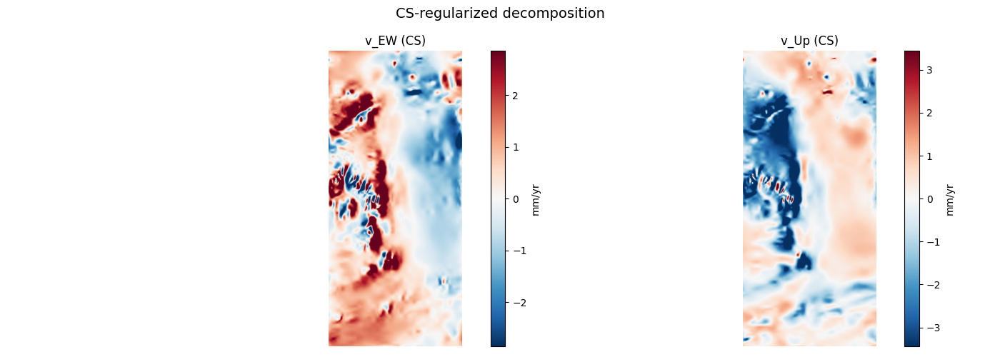

In [ ]:
# Cell 13b - Load decomposed velocities
# Option 1: Load CS-regularized decomposition from insar_decompose_cs.ipynb
# Option 2: Fall back to naive Cramer's rule if CS file not available
import os

cs_path = '/Users/amasaryk/projects/Creep/wavelet/decomposed_cs_sr.npz'

if os.path.exists(cs_path):
    data = np.load(cs_path)
    sr = int(data.get('SR_FACTOR', 1))
    
    if sr > 1:
        # Super-resolution: downsample to original grid for WTMM
        v_EW = data['v_EW_sr'][::sr, ::sr][:vel_asc_clean.shape[0], :vel_asc_clean.shape[1]].astype(np.float32)
        v_Up = data['v_Up_sr'][::sr, ::sr][:vel_asc_clean.shape[0], :vel_asc_clean.shape[1]].astype(np.float32)
        # Also keep SR versions if needed
        v_EW_sr = data['v_EW_sr'].astype(np.float32)
        v_Up_sr = data['v_Up_sr'].astype(np.float32)
        print(f'Loaded CS super-resolution (SR={sr}x): {v_EW_sr.shape} -> downsampled to {v_EW.shape}')
    else:
        v_EW = data['v_EW_sr'].astype(np.float32)
        v_Up = data['v_Up_sr'].astype(np.float32)
        print(f'Loaded CS decomposition: {v_EW.shape}')
    
    decomposed = True
    print(f'  v_EW range: [{v_EW.min():.1f}, {v_EW.max():.1f}] mm/yr')
    print(f'  v_Up range: [{v_Up.min():.1f}, {v_Up.max():.1f}] mm/yr')
    
    # Also load naive for comparison if available
    if 'v_EW_naive' in data:
        v_EW_naive = data['v_EW_naive'].astype(np.float32)
        v_Up_naive = data['v_Up_naive'].astype(np.float32)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ew_lim = np.nanpercentile(np.abs(v_EW), 95)
    up_lim = np.nanpercentile(np.abs(v_Up), 95)
    sc = axes[0].imshow(v_EW, origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
    plt.colorbar(sc, ax=axes[0], label='mm/yr'); axes[0].set_title('v_EW (CS)'); axes[0].axis('off')
    sc = axes[1].imshow(v_Up, origin='lower', cmap='RdBu_r', vmin=-up_lim, vmax=up_lim, rasterized=True)
    plt.colorbar(sc, ax=axes[1], label='mm/yr'); axes[1].set_title('v_Up (CS)'); axes[1].axis('off')
    plt.suptitle('CS-regularized decomposition', fontsize=14)
    plt.tight_layout(); plt.show()

elif desc_available:
    # Fallback: naive Cramer's rule
    print('CS file not found, using naive decomposition...')
    if vel_asc_clean.shape != vel_desc_clean.shape:
        print(f'WARNING: shape mismatch asc={vel_asc_clean.shape} desc={vel_desc_clean.shape}')
        decomposed = False
    else:
        det_A = E_asc * U_desc - U_asc * E_desc
        valid_decomp = (np.abs(det_A) > 0.01) & (mask_asc == 1) & (mask_desc == 1)
        v_EW = np.zeros_like(vel_asc_clean)
        v_Up = np.zeros_like(vel_asc_clean)
        v_EW[valid_decomp] = (vel_asc_clean[valid_decomp] * U_desc[valid_decomp] -
                               vel_desc_clean[valid_decomp] * U_asc[valid_decomp]) / det_A[valid_decomp]
        v_Up[valid_decomp] = (E_asc[valid_decomp] * vel_desc_clean[valid_decomp] -
                               E_desc[valid_decomp] * vel_asc_clean[valid_decomp]) / det_A[valid_decomp]
        v_EW = v_EW.astype(np.float32)
        v_Up = v_Up.astype(np.float32)
        decomposed = True
        print(f'Naive decomposition: v_EW range [{v_EW.min():.1f}, {v_EW.max():.1f}]')
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ew_lim = np.nanpercentile(np.abs(v_EW[valid_decomp]), 95)
        up_lim = np.nanpercentile(np.abs(v_Up[valid_decomp]), 95)
        axes[0].imshow(v_EW, origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
        axes[0].set_title('v_EW (naive)'); axes[0].axis('off')
        axes[1].imshow(v_Up, origin='lower', cmap='RdBu_r', vmin=-up_lim, vmax=up_lim, rasterized=True)
        axes[1].set_title('v_Up (naive)'); axes[1].axis('off')
        plt.suptitle('Naive decomposition (CS file not found)', fontsize=14)
        plt.tight_layout(); plt.show()
else:
    decomposed = False
    print('No descending data and no CS file. Use scalar WTMM on ascending LOS.')
    insar_field = vel_asc_clean

40 scales: [14.0, 208.3]
Method: wtmm2d, Wavelet: mexican, Smooth: False

Computing CWT on v_EW, v_Up (derivs=first, wavelet=mexican)...
  Scale 0/39: a=14.0
  Scale 5/39: a=19.7
  Scale 10/39: a=27.9
  Scale 15/39: a=39.5
  Scale 20/39: a=55.8
  Scale 25/39: a=78.9
  Scale 30/39: a=111.6
  Scale 35/39: a=157.9
  Scale 39/39: a=208.3
  Scale 0/39: a=14.0
  Scale 5/39: a=19.7
  Scale 10/39: a=27.9
  Scale 15/39: a=39.5
  Scale 20/39: a=55.8
  Scale 25/39: a=78.9
  Scale 30/39: a=111.6
  Scale 35/39: a=157.9
  Scale 39/39: a=208.3

Extrema detection (wtmm2d)...
Extrema per octave: [62762, 37090, 21751, 12643]
Chaining...

=== InSAR Tensor (v_EW, v_Up) [wtmm2d, mexican] ===
  2417 chains, median h = 1.201


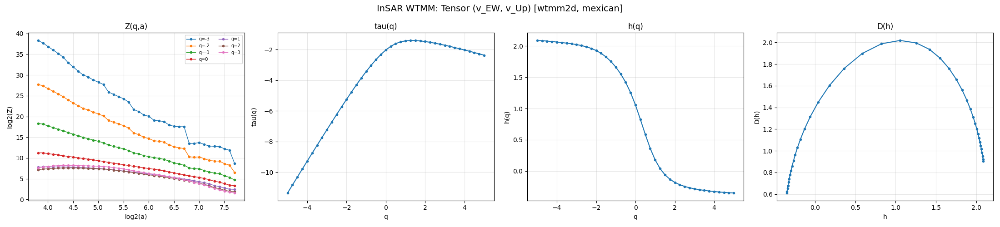

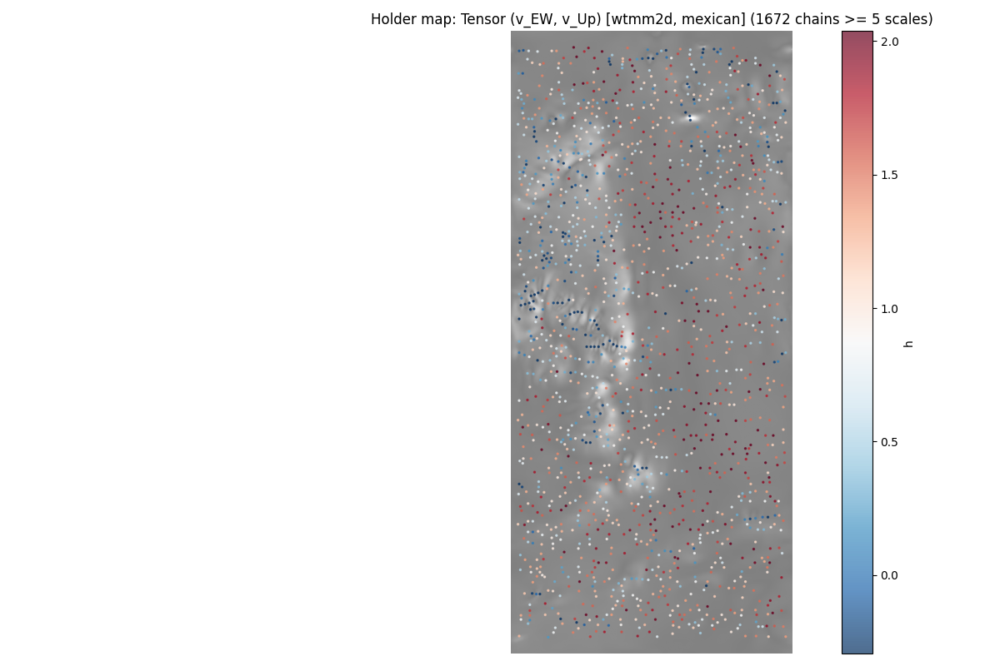

In [ ]:
# Cell 13c - WTMM on real InSAR data
# Options: method (wtmm2d/follow), wavelet (gaussian/mexican), smooth chains

# ===== PARAMETERS =====
EXTREMA_METHOD = 'wtmm2d'   # 'wtmm2d' (NMS, fast) or 'follow' (kapa/kapap, xsmurf default)
WAVELET = 'mexican'         # 'gaussian' (g1, 1 vanishing moment) or 'mexican' (g2, 3 vanishing moments)
SMOOTH_CHAINS = False        # True = smooth modulus dips before ssm
n_oct_insar = 4
n_vox_insar = 10
# ======================

scales_insar = compute_scales(n_oct_insar, n_vox_insar)
print(f'{len(scales_insar)} scales: [{scales_insar[0]:.1f}, {scales_insar[-1]:.1f}]')
print(f'Method: {EXTREMA_METHOD}, Wavelet: {WAVELET}, Smooth: {SMOOTH_CHAINS}')

need_all_derivs = (EXTREMA_METHOD == 'follow')
derivs_mode = 'all' if need_all_derivs else 'first'

if decomposed:
    print(f'\nComputing CWT on v_EW, v_Up (derivs={derivs_mode}, wavelet={WAVELET})...')
    deriv_EW_i = cwt_2d_f32(v_EW, scales_insar, pad=32, derivs=derivs_mode, wavelet=WAVELET, verbose=True)
    deriv_Up_i = cwt_2d_f32(v_Up, scales_insar, pad=32, derivs=derivs_mode, wavelet=WAVELET, verbose=True)
    
    print(f'\nExtrema detection ({EXTREMA_METHOD})...')
    insar_ext_images = []
    for i, scale in enumerate(scales_insar):
        if EXTREMA_METHOD == 'follow':
            # Scalar follow on each component separately, then combine via tensor SVD modulus
            # For follow we need kapa/kapap — only works on scalar fields
            # So we run follow on the scalar gradient modulus of the tensor SVD
            # Step 1: compute tensor SVD modulus
            dx1 = xsm.XImage.from_numpy(deriv_EW_i['dx'][i])
            dy1 = xsm.XImage.from_numpy(deriv_EW_i['dy'][i])
            dx2 = xsm.XImage.from_numpy(deriv_Up_i['dx'][i])
            dy2 = xsm.XImage.from_numpy(deriv_Up_i['dy'][i])
            gx1d = dx1.duplicate(); gy1d = dy1.duplicate()
            mod_img, arg_img = xsm.tensor_wtmm_2d(gx1d, gy1d, dx2, dy2, svd_type=xsm.SVD_MAX)
            
            # Step 2: compute gradient of SVD modulus for follow
            mod_arr = mod_img.to_numpy()
            deriv_svd = cwt_2d_f32(mod_arr, [scale], pad=16, derivs='all', wavelet=WAVELET, verbose=False)
            kapa = gkapa_numpy(deriv_svd['dx'][0], deriv_svd['dy'][0],
                               deriv_svd['dxx'][0], deriv_svd['dxy'][0], deriv_svd['dyy'][0])
            kapap = gkapap_numpy(deriv_svd['dx'][0], deriv_svd['dy'][0],
                                 deriv_svd['dxx'][0], deriv_svd['dxy'][0], deriv_svd['dyy'][0],
                                 deriv_svd['dxxx'][0], deriv_svd['dxxy'][0],
                                 deriv_svd['dxyy'][0], deriv_svd['dyyy'][0])
            ext = xsm.find_extrema_follow(
                xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
                xsm.XImage.from_numpy(deriv_svd['mod'][0]),
                xsm.XImage.from_numpy(deriv_svd['arg'][0]),
                scale, thresh=1e-6)
        else:
            # wtmm2d_vector: tensor NMS with SVD
            dx1 = xsm.XImage.from_numpy(deriv_EW_i['dx'][i])
            dy1 = xsm.XImage.from_numpy(deriv_EW_i['dy'][i])
            dx2 = xsm.XImage.from_numpy(deriv_Up_i['dx'][i])
            dy2 = xsm.XImage.from_numpy(deriv_Up_i['dy'][i])
            ext, _, _ = xsm.wtmm2d_vector(dx1, dy1, dx2, dy2,
                                            scale, svd_type=xsm.SVD_MAX, thresh=1e-5)
        insar_ext_images.append(ext)
    insar_label = f'Tensor (v_EW, v_Up) [{EXTREMA_METHOD}, {WAVELET}]'
    insar_bg = np.sqrt(v_EW**2 + v_Up**2)

else:
    print(f'\nComputing CWT on LOS velocity (derivs={derivs_mode}, wavelet={WAVELET})...')
    deriv_los = cwt_2d_f32(insar_field, scales_insar, pad=32, derivs=derivs_mode, wavelet=WAVELET, verbose=True)
    
    print(f'\nExtrema detection ({EXTREMA_METHOD})...')
    insar_ext_images = []
    for i, scale in enumerate(scales_insar):
        if EXTREMA_METHOD == 'follow':
            kapa = gkapa_numpy(deriv_los['dx'][i], deriv_los['dy'][i],
                               deriv_los['dxx'][i], deriv_los['dxy'][i], deriv_los['dyy'][i])
            kapap = gkapap_numpy(deriv_los['dx'][i], deriv_los['dy'][i],
                                 deriv_los['dxx'][i], deriv_los['dxy'][i], deriv_los['dyy'][i],
                                 deriv_los['dxxx'][i], deriv_los['dxxy'][i],
                                 deriv_los['dxyy'][i], deriv_los['dyyy'][i])
            ext = xsm.find_extrema_follow(
                xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
                xsm.XImage.from_numpy(deriv_los['mod'][i]),
                xsm.XImage.from_numpy(deriv_los['arg'][i]),
                scale, thresh=1e-6)
        else:
            dx_img = xsm.XImage.from_numpy(deriv_los['dx'][i])
            dy_img = xsm.XImage.from_numpy(deriv_los['dy'][i])
            ext, _, _ = xsm.wtmm2d(dx_img, dy_img, scale, thresh=1e-6)
        insar_ext_images.append(ext)
    insar_label = f'Scalar (LOS) [{EXTREMA_METHOD}, {WAVELET}]'
    insar_bg = insar_field

print(f'Extrema per octave: {[insar_ext_images[i].extr_nb for i in range(0, len(scales_insar), n_vox_insar)]}')

# Cut edges
try:
    for i in range(len(insar_ext_images)):
        insar_ext_images[i] = xsm.cut_edge(insar_ext_images[i], border_percent=.95)
except AttributeError:
    print("WARNING: cut_edge not available. Rebuild wrapper.")

# Chain
print('Chaining...')
xsm.chain(insar_ext_images, a_min=1.0, n_oct=n_oct_insar, n_vox=n_vox_insar,
           smooth=SMOOTH_CHAINS, verbose=False)
insar_chains = xsm.extract_vertical_chains(insar_ext_images, scales_insar)
insar_holders = xsm.compute_holder_exponents(insar_chains)

h_insar = np.array([h['h'] for h in insar_holders])
print(f'\n=== InSAR {insar_label} ===')
print(f'  {len(insar_chains)} chains, median h = {np.nanmedian(h_insar):.3f}')

# Quick spectra
spectra_insar = xsm.compute_spectra(insar_ext_images, scales_insar)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
q_show = np.arange(-3, 4, 1.0)
for q in q_show:
    qi = np.argmin(np.abs(spectra_insar['q_list'] - q))
    axes[0].plot(spectra_insar['log2_scales'], spectra_insar['log2_Z'][qi], '.-',
                 label=f'q={q:.0f}', lw=1)
axes[0].set(xlabel='log2(a)', ylabel='log2(Z)', title='Z(q,a)')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(True, alpha=0.3)

axes[1].plot(spectra_insar['q_list'], spectra_insar['tau'], '.-')
axes[1].set(xlabel='q', ylabel='tau(q)', title='tau(q)'); axes[1].grid(True, alpha=0.3)

axes[2].plot(spectra_insar['q_list'], spectra_insar['h'], '.-')
axes[2].set(xlabel='q', ylabel='h(q)', title='h(q)'); axes[2].grid(True, alpha=0.3)

valid = np.isfinite(spectra_insar['D']) & np.isfinite(spectra_insar['h'])
axes[3].plot(spectra_insar['h'][valid], spectra_insar['D'][valid], '.-')
axes[3].set(xlabel='h', ylabel='D(h)', title='D(h)'); axes[3].grid(True, alpha=0.3)

plt.suptitle(f'InSAR WTMM: {insar_label}', fontsize=14)
plt.tight_layout()
plt.show()

# Holder map
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(insar_bg, origin='lower', cmap='gray', alpha=0.5, rasterized=True)
long_ch = [(h, ch) for h, ch in zip(insar_holders, insar_chains) if len(ch['mod']) >= 5]
if long_ch:
    xs = np.array([h['x'] for h, _ in long_ch])
    ys = np.array([h['y'] for h, _ in long_ch])
    hs = np.array([h['h'] for h, _ in long_ch])
    vmin, vmax = np.nanpercentile(hs, [5, 95])
    sc = ax.scatter(xs, ys, c=hs, cmap='RdBu_r', s=2, vmin=vmin, vmax=vmax, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='h')
ax.set_title(f'Holder map: {insar_label} ({len(long_ch)} chains >= 5 scales)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13d - Precompute InSAR chains for interactive viewer
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

insar_holders_slope = xsm.compute_holder_local_slope(insar_chains, method='max')
insar_h_fit_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in insar_holders}
insar_h_slope_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in insar_holders_slope}

insar_chain_lookup = {}
for ch in insar_chains:
    vc_len = len(ch['mod'])
    if vc_len == 0: continue
    anchor = (int(ch['x'][0]), int(ch['y'][0]))
    for si in range(min(vc_len, len(scales_insar))):
        insar_chain_lookup[(si, int(ch['x'][si]), int(ch['y'][si]))] = (vc_len, anchor)

i_lines_by_scale = []
i_lines_hfit = [
i_lines_hslope = []
i_lines_maxvc = []

for si in range(len(scales_insar)):
    ext = insar_ext_images[si]
    line_list = ext.get_lines()
    lx_ext = ext.lx
    segs, s_hfit, s_hslope, s_maxvc = [], [], [], []
    for line in line_list:
        pos = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(pos) < 2: continue
        xs = (pos % lx_ext).astype(np.float64)
        ys = (pos // lx_ext).astype(np.float64)
        segs.append(np.column_stack([xs, ys]))
        mvc, bhf, bhs = 0, np.nan, np.nan
        for j in range(len(pos)):
            info = insar_chain_lookup.get((si, int(xs[j]), int(ys[j])), (0, None))
            if info[0] > mvc:
                mvc = info[0]
                if info[1] is not None:
                    bhf = insar_h_fit_lookup.get(info[1], np.nan)
                    bhs = insar_h_slope_lookup.get(info[1], np.nan)
        s_hfit.append(bhf); s_hslope.append(bhs); s_maxvc.append(mvc)
    i_lines_by_scale.append(segs)
    i_lines_hfit.append(np.array(s_hfit, dtype=np.float32))
    i_lines_hslope.append(np.array(s_hslope, dtype=np.float32))
    i_lines_maxvc.append(np.array(s_maxvc, dtype=np.int32))

i_wtmmm = []
for si in range(len(scales_insar)):
    ext = insar_ext_images[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    if ext.extr_nb == 0:
        i_wtmmm.append({'x': np.array([]), 'y': np.array([]), 'mod': np.array([]), 'arg': np.array([])})
        continue
    m = on_vc.astype(bool)
    i_wtmmm.append({'x': data['x'][m].astype(np.float64), 'y': data['y'][m].astype(np.float64),
                     'mod': data['mod'][m], 'arg': data['arg'][m]})

print(f"Precomputed {sum(len(s) for s in i_lines_by_scale)} segments, "
      f"{sum(len(w['x']) for w in i_wtmmm)} WTMMM")

Precomputed 39876 segments, 23021 WTMMM


In [ ]:
# Cell 13e - Interactive InSAR extrema viewer
from ipywidgets import interact, IntRangeSlider, IntSlider, Checkbox, Dropdown, FloatSlider, Layout
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

i_scale_cmap = plt.cm.plasma
i_scale_norm = Normalize(vmin=0, vmax=len(scales_insar)-1)
ny_i, nx_i = insar_bg.shape
ds_bg_i = max(1, max(ny_i, nx_i) // 800)

bg_vel = insar_bg.astype(np.float64)
bg_vel_log = np.log1p(bg_vel - bg_vel.min())
def _hist_eq(img):
    flat = img.ravel()
    h, bins = np.histogram(flat[np.isfinite(flat)], bins=1000)
    cdf = h.cumsum().astype(np.float64); cdf = cdf / cdf[-1]
    return np.interp(flat, bins[:-1], cdf).reshape(img.shape)
bg_vel_heq = _hist_eq(bg_vel)
bg_dict = {'Velocity (linear)': bg_vel, 'Velocity (log)': bg_vel_log, 'Velocity (hist EQ)': bg_vel_heq}
if 'hgt' in dir():
    bg_dem = hgt.astype(np.float64)
    bg_dict['DEM (linear)'] = bg_dem
    bg_dict['DEM (hist EQ)'] = _hist_eq(np.nan_to_num(bg_dem, nan=0.0))
if 'coh_asc' in dir():
    bg_dict['Coherence'] = coh_asc.astype(np.float64)
bg_dict['None'] = None

def i_robust(vals, lo=5, hi=95, default=(-1,1)):
    return (np.percentile(vals, lo), np.percentile(vals, hi)) if len(vals) > 0 else default

def i_draw(scale_range, min_hchain, min_vc, min_h, h_method,
           color_by, cmap_name, show_mode, show_bg, line_width, arrow_scale, log2_arrows):
    fig, ax = plt.subplots(figsize=(14, 10))
    if show_bg != 'None':
        bg_img = bg_dict.get(show_bg, bg_vel)
        if bg_img is not None:
            ax.imshow(bg_img[::ds_bg_i, ::ds_bg_i], origin='lower', cmap='gray', rasterized=True,
                      extent=[0, nx_i, 0, ny_i], alpha=0.6)
        ax.set_facecolor('black')
    else:
        ax.set_facecolor('white')
    si_lo, si_hi = scale_range
    n_pts = 0
    if show_mode in ('Horizontal chains', 'Chains + arrows'):
        for si in range(si_lo, si_hi + 1):
            segs = i_lines_by_scale[si]
            hfit = i_lines_hfit[si]; hslope = i_lines_hslope[si]; maxvc = i_lines_maxvc[si]
            if not segs: continue
            keep = np.ones(len(segs), dtype=bool)
            for j, seg in enumerate(segs):
                if len(seg) < min_hchain: keep[j] = False
            if min_vc > 0: keep &= (maxvc >= min_vc)
            if min_h > -4.9:
                hr = hfit if h_method == 'LS fit' else hslope
                keep &= (hr >= min_h) | np.isnan(hr)
            filt = [segs[j] for j in range(len(segs)) if keep[j]]
            if not filt: continue
            if color_by in ('h (LS fit)', 'h (max slope)'):
                hv = hfit[keep] if color_by == 'h (LS fit)' else hslope[keep]
                vh = hv[np.isfinite(hv)]
                vn, vx = i_robust(vh, 5, 95) if len(vh) > 0 else (-1, 1)
                lc = LineCollection(filt, cmap=cmap_name, norm=Normalize(vmin=vn, vmax=vx),
                                    linewidths=line_width, alpha=0.8)
                lc.set_array(hv); ax.add_collection(lc)
                if si == si_hi: plt.colorbar(lc, ax=ax, label=color_by, shrink=0.6)
            else:
                sc_c = i_scale_cmap(i_scale_norm(si))
                lc = LineCollection(filt, colors=[sc_c]*len(filt), linewidths=line_width, alpha=0.8)
                ax.add_collection(lc)
            n_pts += sum(len(s) for s in filt)
        if show_mode == 'Chains + arrows':
            for si in range(si_lo, si_hi + 1):
                w = i_wtmmm[si]
                if len(w['x']) == 0: continue
                if log2_arrows:
                    lm = np.log2(np.maximum(w['mod'], 1e-30))
                    mn, rng = lm.min(), lm.max()-lm.min()
                    mod_n = (lm-mn)/(rng+1e-30)
                else:
                    mod_n = w['mod'] / (w['mod'].max()+1e-30)
                dxa = np.cos(w['arg'])*mod_n*arrow_scale
                dya = np.sin(w['arg'])*mod_n*arrow_scale
                sc_c = i_scale_cmap(i_scale_norm(si))
                sq = max(1, len(w['x'])//8000)
                ax.quiver(w['x'][::sq], w['y'][::sq], dxa[::sq], dya[::sq],
                          color=sc_c, scale_units='xy', scale=1, width=0.003,
                          headwidth=4, headlength=3, alpha=0.9, zorder=5)
        if color_by == 'scale':
            sm = plt.cm.ScalarMappable(norm=i_scale_norm, cmap=i_scale_cmap)
            sm.set_array([]); plt.colorbar(sm, ax=ax, label='scale index', shrink=0.6)
    else:
        vc_x = np.array([int(ch['x'][0]) for ch in insar_chains], dtype=np.int32)
        vc_y = np.array([int(ch['y'][0]) for ch in insar_chains], dtype=np.int32)
        vc_len = np.array([len(ch['mod']) for ch in insar_chains], dtype=np.int32)
        vc_h = np.array([insar_h_fit_lookup.get((int(ch['x'][0]),int(ch['y'][0])), np.nan)
                         for ch in insar_chains], dtype=np.float32)
        mk = vc_len >= max(min_vc, 2)
        if min_h > -4.9: mk &= (vc_h >= min_h) | np.isnan(vc_h)
        c = vc_h[mk]; v = ~np.isnan(c)
        xm, ym, c = vc_x[mk][v], vc_y[mk][v], c[v]
        if len(xm) > 0:
            vn, vx = i_robust(c, 5, 95)
            sc = ax.scatter(xm, ym, c=c, s=8, cmap=cmap_name, vmin=vn, vmax=vx, rasterized=True)
            plt.colorbar(sc, ax=ax, label='h', shrink=0.6)
        n_pts = len(xm)
    scope = f'scales {si_lo}-{si_hi} (a={scales_insar[si_lo]:.1f}-{scales_insar[si_hi]:.1f})'
    ax.set_title(f'InSAR {insar_label} | {show_mode} | {color_by} -- {n_pts} pts ({scope})')
    ax.set_xlim(0, nx_i); ax.set_ylim(0, ny_i)
    ax.set_aspect('equal')
    try:
        add_geo_labels(ax, nx_i, ny_i)
    except: pass
    plt.tight_layout(); plt.show()

interact(
    i_draw,
    scale_range=IntRangeSlider(value=[len(scales_insar)//2, len(scales_insar)//2],
                               min=0, max=len(scales_insar)-1,
                               description='Scale range:', layout=Layout(width='70%'), continuous_update=False),
    min_hchain=IntSlider(value=10, min=1, max=500, step=5,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=0, min=0, max=len(scales_insar), step=1,
                     description='Min vc:', layout=Layout(width='60%'), continuous_update=False),
    min_h=FloatSlider(value=-5.0, min=-5.0, max=5.0, step=0.1,
                      description='Min h:', layout=Layout(width='60%'), continuous_update=False),
    h_method=Dropdown(options=['Max slope', 'LS fit'], value='Max slope', description='h filter:'),
    color_by=Dropdown(options=['scale', 'h (LS fit)', 'h (max slope)'], value='scale', description='Color by:'),
    cmap_name=Dropdown(options=['RdBu_r', 'coolwarm', 'viridis', 'plasma', 'turbo'],
                       value='RdBu_r', description='Colormap:'),
    show_mode=Dropdown(options=['Chains + arrows', 'Horizontal chains', 'VC origin points'],
                       value='Chains + arrows', description='Show:'),
    show_bg=Dropdown(options=list(bg_dict.keys()), value=list(bg_dict.keys())[0], description='Background:'),
    line_width=FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1,
                           description='Line width:', layout=Layout(width='60%'), continuous_update=False),
    arrow_scale=FloatSlider(value=5.0, min=0.5, max=50.0, step=0.5,
                            description='Arrow scale:', layout=Layout(width='60%'), continuous_update=False),
    log2_arrows=Checkbox(value=False, description='log2(mod) arrows'));

interactive(children=(IntRangeSlider(value=(20, 20), continuous_update=False, description='Scale range:', layo…

Chains: 9 sup-at-finest, 952 genuine


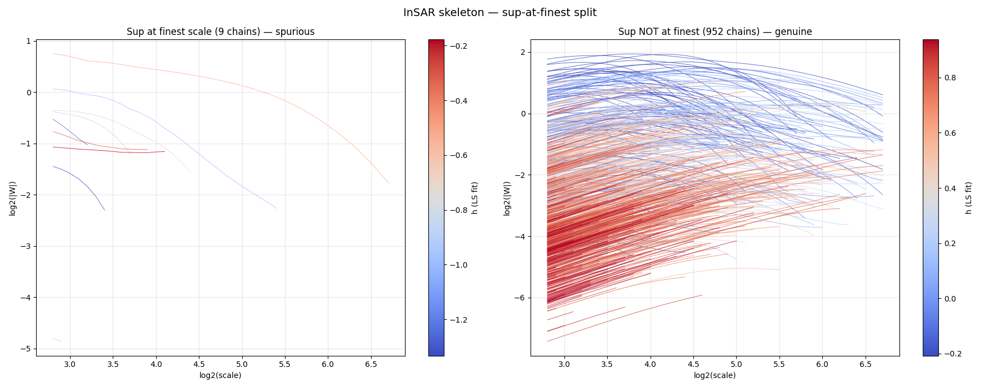

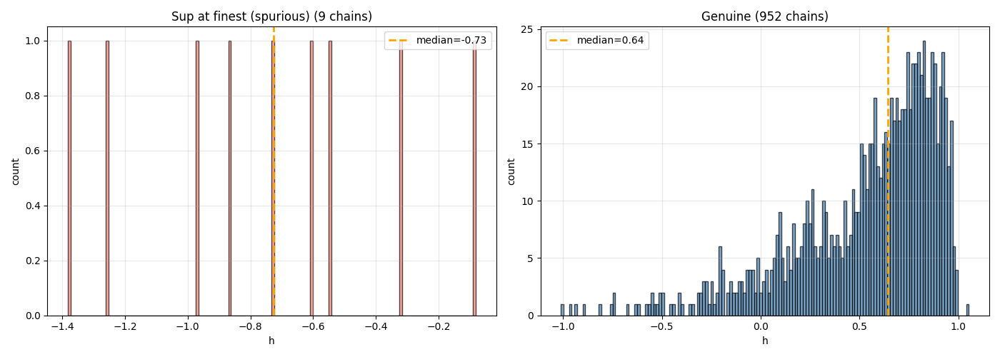

In [ ]:
# Cell 13f - InSAR skeleton plot (split: sup-at-finest vs genuine)
from matplotlib.cm import ScalarMappable

# Classify chains
chain_sup_finest = set()
chain_genuine = set()
for ch in insar_chains:
    n = len(ch['mod'])
    if n < 2: continue
    anchor = (int(ch['x'][0]), int(ch['y'][0]))
    sup_idx = np.argmax(np.abs(ch['mod']))
    if sup_idx == 0:
        chain_sup_finest.add(anchor)
    else:
        chain_genuine.add(anchor)

print(f"Chains: {len(chain_sup_finest)} sup-at-finest, {len(chain_genuine)} genuine")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
log2_s_i = np.log2(scales_insar)

for col, (ax, title, anchor_set) in enumerate([
    (axes[0], f'Sup at finest scale ({len(chain_sup_finest)} chains) — spurious', chain_sup_finest),
    (axes[1], f'Sup NOT at finest ({len(chain_genuine)} chains) — genuine', chain_genuine)]):
    
    items = []
    for ch in insar_chains[:5000]:
        n = len(ch['mod'])
        if n < 2: continue
        anchor = (int(ch['x'][0]), int(ch['y'][0]))
        if anchor not in anchor_set: continue
        h = insar_h_fit_lookup.get(anchor, np.nan)
        if not np.isfinite(h): continue
        items.append((h, n, ch['log2_mod']))
    
    if items:
        items.sort(key=lambda t: t[0])
        hv = np.array([t[0] for t in items])
        vn, vx = np.percentile(hv, [5, 95])
        if vn == vx: vn, vx = hv.min(), hv.max()
        nm = Normalize(vmin=vn, vmax=vx)
        cm = plt.cm.coolwarm
        for h, n, lm in items:
            ax.plot(log2_s_i[:n], lm, '-', color=cm(nm(h)), alpha=0.8, lw=0.7)
        sm = ScalarMappable(norm=nm, cmap=cm); sm.set_array([])
        plt.colorbar(sm, ax=ax, label='h (LS fit)')
    
    ax.set(xlabel='log2(scale)', ylabel='log2(|W|)', title=title)
    ax.grid(True, alpha=0.3)

plt.suptitle('InSAR skeleton — sup-at-finest split', fontsize=14)
plt.tight_layout()
plt.show()

# Holder histograms
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
for col, (ax, title, anchor_set) in enumerate([
    (axes2[0], 'Sup at finest (spurious)', chain_sup_finest),
    (axes2[1], 'Genuine', chain_genuine)]):
    h_vals = []
    for ch in insar_chains:
        anchor = (int(ch['x'][0]), int(ch['y'][0]))
        if anchor not in anchor_set: continue
        h = insar_h_fit_lookup.get(anchor, np.nan)
        if np.isfinite(h): h_vals.append(h)
    h_vals = np.array(h_vals)
    if len(h_vals) > 0:
        ax.hist(h_vals, bins=150, color='steelblue' if col == 1 else 'salmon', edgecolor='k', alpha=0.7)
        ax.axvline(np.median(h_vals), color='orange', ls='--', lw=2,
                   label=f'median={np.median(h_vals):.2f}')
    ax.set(xlabel='h', ylabel='count', title=f'{title} ({len(h_vals)} chains)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Filtered: 952 / 961 chains
  log2(mod) >= -16.0, min_vc >= 0, remove_sup_finest=True
  14664 total filtered vc points


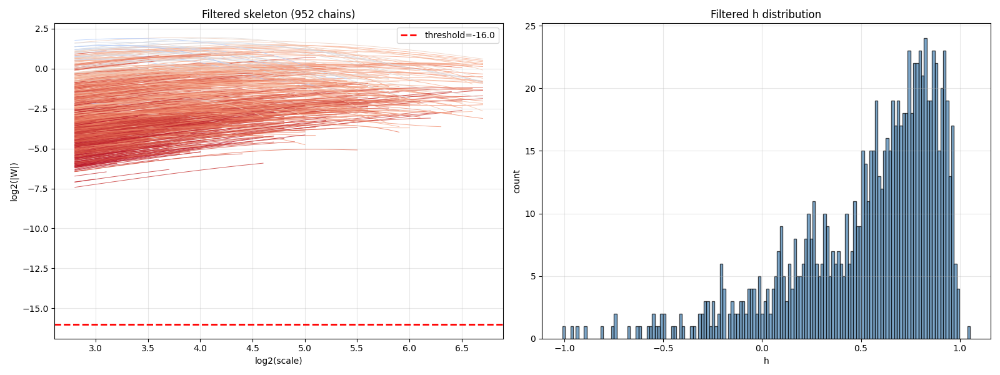

In [ ]:
# Cell 13f2 - Filter chains by log2(mod) threshold + chainmax option
# Remove spurious low-modulus chains before computing partition function
# Also compute chainmax (running max along each chain)

# --- Filter parameters (adjust based on skeleton plot) ---
log2_mod_min = -16.0     # remove chains with mean log2(|W|) below this
min_vc_pf = 0           # minimum vertical chain length for partition function
min_h_pf = -2.0         # minimum Holder exponent (-5 = no filter)
remove_sup_at_finest = True  # remove chains whose max modulus is at the first (finest) scale

# Filter chains
filtered_insar_chains = []
for ch in insar_chains:
    n = len(ch['mod'])
    if n < min_vc_pf:
        continue
    mean_log2_mod = np.mean(ch['log2_mod'])
    if mean_log2_mod < log2_mod_min:
        continue
    # Remove chains whose supremum (max |W|) is at the finest scale
    # These are typically noise — real singularities have modulus increasing with scale
    if remove_sup_at_finest and n >= 2:
        sup_idx = np.argmax(np.abs(ch['mod']))
        if sup_idx == 0:
            continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = insar_h_fit_lookup.get(key, np.nan)
    if min_h_pf > -4.9 and (np.isnan(h) or h < min_h_pf):
        continue
    filtered_insar_chains.append(ch)

print(f"Filtered: {len(filtered_insar_chains)} / {len(insar_chains)} chains")
print(f"  log2(mod) >= {log2_mod_min}, min_vc >= {min_vc_pf}, remove_sup_finest={remove_sup_at_finest}")

# Build filtered positions set
filtered_insar_positions = set()
for ch in filtered_insar_chains:
    n_ch = len(ch['mod'])
    for si in range(min(n_ch, len(scales_insar))):
        filtered_insar_positions.add((si, int(ch['x'][si]), int(ch['y'][si])))
print(f"  {len(filtered_insar_positions)} total filtered vc points")

# Build chainmax lookup (running max modulus along each chain)
chainmax_insar = [{} for _ in range(len(scales_insar))]
for ch in filtered_insar_chains:
    n_ch = len(ch['mod'])
    running_max = 0.0
    for si in range(min(n_ch, len(scales_insar))):
        m = abs(float(ch['mod'][si]))
        if m > running_max:
            running_max = m
        chainmax_insar[si][(int(ch['x'][si]), int(ch['y'][si]))] = running_max

# Show filtered skeleton
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
log2_s_i = np.log2(scales_insar)

for ch in filtered_insar_chains[:3000]:
    n = len(ch['mod'])
    if n < 2: continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = insar_h_fit_lookup.get(key, np.nan)
    if not np.isfinite(h): continue
    lm = ch['log2_mod']
    vn, vx = -2.0, 1.0
    from matplotlib.colors import Normalize as Norm
    color = plt.cm.coolwarm(Norm(vmin=vn, vmax=vx)(h))
    axes[0].plot(log2_s_i[:n], lm, '-', color=color, alpha=0.8, lw=0.7)

axes[0].axhline(log2_mod_min, color='red', ls='--', lw=2, label=f'threshold={log2_mod_min}')
axes[0].set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'Filtered skeleton ({len(filtered_insar_chains)} chains)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

h_filt = np.array([insar_h_fit_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
                    for ch in filtered_insar_chains])
axes[1].hist(h_filt[np.isfinite(h_filt)], bins=150, color='steelblue', edgecolor='k', alpha=0.7)
axes[1].set(xlabel='h', ylabel='count', title='Filtered h distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 13g - Interactive partition function with chainmax toggle
%matplotlib widget
from IPython.display import display, clear_output
import ipywidgets as widgets
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

q_list_i = spectra_insar['q_list']
n_q_i = len(q_list_i)
n_sc_i = len(scales_insar)
log2_c = np.log(2.0)

# Standard partition function (filtered chains only)
STq_i = np.zeros((n_q_i, n_sc_i), dtype=np.float64)
STqlogT_i = np.zeros((n_q_i, n_sc_i), dtype=np.float64)

# Chainmax partition function
STq_sup = np.zeros((n_q_i, n_sc_i), dtype=np.float64)
STqlogT_sup = np.zeros((n_q_i, n_sc_i), dtype=np.float64)

for j, ext in enumerate(insar_ext_images):
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    mod_list, mod_sup_list = [], []
    for k in range(ext.extr_nb):
        if on_vc[k]:
            pos_key = (j, int(data['x'][k]), int(data['y'][k]))
            if pos_key in filtered_insar_positions:
                m = abs(float(data['mod'][k]))
                if m > 0:
                    mod_list.append(m)
                    xy_key = (int(data['x'][k]), int(data['y'][k]))
                    m_sup = chainmax_insar[j].get(xy_key, m)
                    mod_sup_list.append(max(m_sup, 1e-30))
    if not mod_list: continue
    mod = np.array(mod_list, dtype=np.float64)
    mod_sup = np.array(mod_sup_list, dtype=np.float64)
    log_mod = np.log(mod)
    log_mod_sup = np.log(mod_sup)
    for i, q in enumerate(q_list_i):
        mod_q = mod ** q if q != 0 else np.ones(len(mod))
        STq_i[i, j] = np.sum(mod_q)
        STqlogT_i[i, j] = np.sum(log_mod * mod_q)
        mod_q_sup = mod_sup ** q if q != 0 else np.ones(len(mod_sup))
        STq_sup[i, j] = np.sum(mod_q_sup)
        STqlogT_sup[i, j] = np.sum(log_mod_sup * mod_q_sup)

def build_hd_insar(STq_in, STqlogT_in):
    tau = np.full((n_q_i, n_sc_i), np.nan)
    h = np.full((n_q_i, n_sc_i), np.nan)
    D = np.full((n_q_i, n_sc_i), np.nan)
    vZ = STq_in > 0
    tau[vZ] = np.log(STq_in[vZ]) / log2_c
    h[vZ] = STqlogT_in[vZ] / (log2_c * STq_in[vZ])
    for i, q in enumerate(q_list_i):
        for j in range(n_sc_i):
            if STq_in[i, j] > 0:
                D[i, j] = (q * STqlogT_in[i, j] - STq_in[i, j] * np.log(STq_in[i, j])) / (STq_in[i, j] * log2_c)
    return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
            'q_list': q_list_i, 'scales': np.array(scales_insar),
            'log2_scales': np.log2(np.array(scales_insar))}

hd_std = build_hd_insar(STq_i, STqlogT_i)
hd_cmax = build_hd_insar(STq_sup, STqlogT_sup)

print(f"Standard: extrema per scale = {[int(STq_i[n_q_i//2, j]) for j in range(0, n_sc_i, n_sc_i//4)]}")
print(f"Chainmax: extrema per scale = {[int(STq_sup[n_q_i//2, j]) for j in range(0, n_sc_i, n_sc_i//4)]}")

fit_st = {'scale_min': scales_insar[0], 'scale_max': scales_insar[-1]}
log2_si = hd_std['log2_scales']

chainmax_toggle = widgets.ToggleButtons(
    options=['Standard (-vc)', 'Chainmax (-vc_max)'],
    value='Standard (-vc)', description='Method:')

out_pf = widgets.Output()
out_sp = widgets.Output()

q_sh = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
col_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_sh)))

def get_hd_i():
    return hd_std if 'Standard' in chainmax_toggle.value else hd_cmax

def draw_i():
    smin, smax = fit_st['scale_min'], fit_st['scale_max']
    s_mask = (np.array(scales_insar) >= smin) & (np.array(scales_insar) <= smax)
    hd_cur = get_hd_i()
    method = chainmax_toggle.value

    with out_pf:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for panel, (key, yl, tl) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
            ax = axes[panel]
            for qi, color in zip(q_sh, col_q):
                idx = np.argmin(np.abs(hd_cur['q_list'] - qi))
                y = hd_cur[key][idx]; v = np.isfinite(y)
                if v.sum() < 2: continue
                ax.plot(log2_si[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')
                yf = y[s_mask]; xf = log2_si[s_mask]; vf = np.isfinite(yf)
                if vf.sum() >= 2:
                    try:
                        sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                        xl = log2_si[v]
                        ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                        ax.text(xl[-1]+0.05, sl*xl[-1]+ic, f'{qi:g}', color=color, fontsize=7, va='center')
                    except: pass
            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel='log2(a)', ylabel=yl, title=tl); ax.grid(True, alpha=0.2)
        fig.suptitle(f'{method} -- L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()
        def on_click(event):
            if event.inaxes is None or event.xdata is None: return
            a = 2 ** event.xdata
            if event.button == 1: fit_st['scale_min'] = a
            elif event.button == 3: fit_st['scale_max'] = a
            if fit_st['scale_min'] > fit_st['scale_max']:
                fit_st['scale_min'], fit_st['scale_max'] = fit_st['scale_max'], fit_st['scale_min']
            draw_i()
        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

    if s_mask.sum() < 2: return
    res = extract_hq_Dq_from_plateaus(hd_cur, scale_range=(smin, smax))
    q = res['q_list']
    valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

    with out_sp:
        clear_output(wait=True)
        if not valid.any(): print("No valid spectra"); return
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax1 = axes[0]
        ax1.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                     fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
        ax1.set(xlabel='q', ylabel='tau(q)'); ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)
        ax2 = ax1.twinx()
        ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                     fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
        ax2.set(ylabel='h(q)'); ax2.tick_params(axis='y', labelcolor='red')
        hw = res['h'][valid].max() - res['h'][valid].min()
        ax1.set_title(f'tau(q) & h(q) -- {method} -- dh={hw:.3f}')
        l1, lb1 = ax1.get_legend_handles_labels()
        l2, lb2 = ax2.get_legend_handles_labels()
        ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8)

        ax = axes[1]
        sc = ax.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                        s=60, edgecolors='black', linewidths=0.5, zorder=5)
        ax.errorbar(res['h'][valid], res['D'][valid],
                    xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                    fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)
        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        pk = np.argmax(res['D'][valid])
        ax.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
        ax.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                    xy=(res['h'][valid][pk], res['D'][valid][pk]),
                    xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', fc='lightyellow'))
        ax.set(xlabel='h', ylabel='D(h)', title=f'D(h) -- {method}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
        fig.tight_layout(); plt.show()

def on_toggle(change): draw_i()
chainmax_toggle.observe(on_toggle, names='value')

print("LEFT-click = min scale | RIGHT-click = max scale")
display(chainmax_toggle)
display(out_pf)
display(out_sp)
draw_i()

Standard: extrema per scale = [952, 571, 277, 105]
Chainmax: extrema per scale = [952, 571, 277, 105]
LEFT-click = min scale | RIGHT-click = max scale


ToggleButtons(description='Method:', options=('Standard (-vc)', 'Chainmax (-vc_max)'), value='Standard (-vc)')

Output()

Output()

DEM: (1052, 475), range [0, 6383] m
24 scales: [7.0, 51.2]

Computing CWT on DEM...
  Scale 0/23: a=7.0
  Scale 3/23: a=9.0
  Scale 6/23: a=11.7
  Scale 9/23: a=15.2
  Scale 12/23: a=19.7
  Scale 15/23: a=25.6
  Scale 18/23: a=33.2
  Scale 21/23: a=43.0
  Scale 23/23: a=51.2

Extrema detection (follow)...
Extrema per octave: [67137, 38005, 20579]
Chaining...

=== DEM WTMM ===
  3818 chains, median h = 0.153


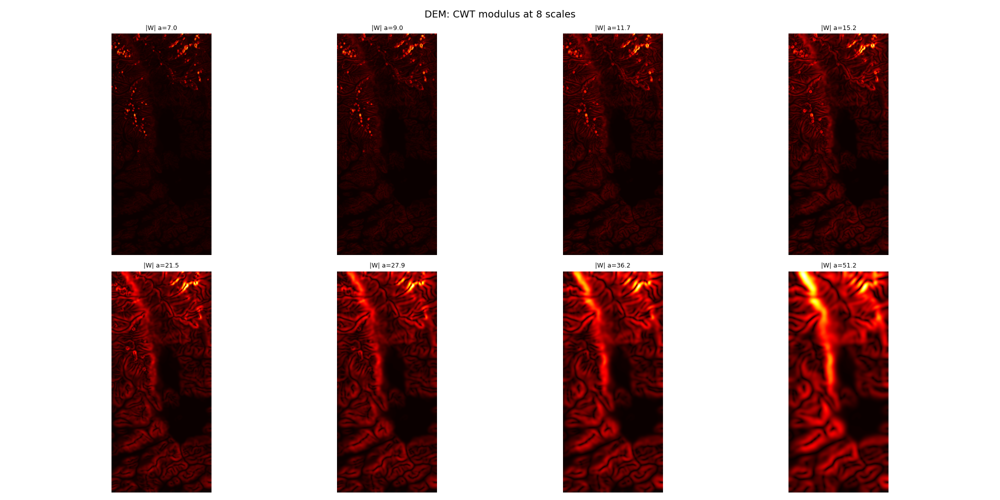

In [ ]:
# Cell 14a - Scalar WTMM on the DEM (elevation)
# No cropping needed — cwt_2d_f32 handles mirror padding internally

dem_image = np.nan_to_num(hgt, nan=0.0).astype(np.float32)
print(f'DEM: {dem_image.shape}, range [{dem_image.min():.0f}, {dem_image.max():.0f}] m')

n_oct_dem = 3
n_vox_dem = 8
scales_dem = compute_scales(n_oct_dem, n_vox_dem)
print(f'{len(scales_dem)} scales: [{scales_dem[0]:.1f}, {scales_dem[-1]:.1f}]')

# Full CWT with all 9 derivatives for follow method
print('\nComputing CWT on DEM...')
deriv_dem = cwt_2d_f32(dem_image, scales_dem, pad=32, derivs='all', verbose=True)

# Extrema detection via follow
print('\nExtrema detection (follow)...')
dem_ext_images = []
for i, scale in enumerate(scales_dem):
    kapa = gkapa_numpy(deriv_dem['dx'][i], deriv_dem['dy'][i],
                       deriv_dem['dxx'][i], deriv_dem['dxy'][i], deriv_dem['dyy'][i])
    kapap = gkapap_numpy(deriv_dem['dx'][i], deriv_dem['dy'][i],
                         deriv_dem['dxx'][i], deriv_dem['dxy'][i], deriv_dem['dyy'][i],
                         deriv_dem['dxxx'][i], deriv_dem['dxxy'][i],
                         deriv_dem['dxyy'][i], deriv_dem['dyyy'][i])
    ext = xsm.find_extrema_follow(
        xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
        xsm.XImage.from_numpy(deriv_dem['mod'][i]),
        xsm.XImage.from_numpy(deriv_dem['arg'][i]),
        scale, thresh=1e-6)
    dem_ext_images.append(ext)

print(f'Extrema per octave: {[dem_ext_images[i].extr_nb for i in range(0, len(scales_dem), n_vox_dem)]}')

# Cut edges
try:
    for i in range(len(dem_ext_images)):
        dem_ext_images[i] = xsm.cut_edge(dem_ext_images[i], border_percent=0.80)
except AttributeError:
    print("WARNING: cut_edge not available")

# Chain
print('Chaining...')
xsm.chain(dem_ext_images, a_min=1.0, n_oct=n_oct_dem, n_vox=n_vox_dem, verbose=False)
dem_chains = xsm.extract_vertical_chains(dem_ext_images, scales_dem)
dem_holders = xsm.compute_holder_exponents(dem_chains)
dem_holders_slope = xsm.compute_holder_local_slope(dem_chains, method='max')

h_dem = np.array([h['h'] for h in dem_holders])
print(f'\n=== DEM WTMM ===')
print(f'  {len(dem_chains)} chains, median h = {np.nanmedian(h_dem):.3f}')

# Scalogram preview
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
show_idx = np.linspace(0, len(scales_dem)-1, 8, dtype=int)
for ax, si in zip(axes.flat, show_idx):
    ax.imshow(deriv_dem['mod'][si], origin='lower', cmap='hot', rasterized=True)
    ax.set_title(f'|W| a={scales_dem[si]:.1f}', fontsize=9); ax.axis('off')
plt.suptitle('DEM: CWT modulus at 8 scales', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 14b - DEM interactive viewer + skeleton
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

dem_h_fit_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in dem_holders}
dem_h_slope_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in dem_holders_slope}

dem_chain_lookup = {}
for ch in dem_chains:
    vc_len = len(ch['mod'])
    if vc_len == 0: continue
    anchor = (int(ch['x'][0]), int(ch['y'][0]))
    for si in range(min(vc_len, len(scales_dem))):
        dem_chain_lookup[(si, int(ch['x'][si]), int(ch['y'][si]))] = (vc_len, anchor)

d_lines_by_scale = []
d_lines_hfit = []
d_lines_maxvc = []

for si in range(len(scales_dem)):
    ext = dem_ext_images[si]
    line_list = ext.get_lines()
    lx_ext = ext.lx
    segs, s_hfit, s_maxvc = [], [], []
    for line in line_list:
        pos = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(pos) < 2: continue
        xs = (pos % lx_ext).astype(np.float64)
        ys = (pos // lx_ext).astype(np.float64)
        segs.append(np.column_stack([xs, ys]))
        mvc, bhf = 0, np.nan
        for j in range(len(pos)):
            info = dem_chain_lookup.get((si, int(xs[j]), int(ys[j])), (0, None))
            if info[0] > mvc:
                mvc = info[0]
                if info[1] is not None:
                    bhf = dem_h_fit_lookup.get(info[1], np.nan)
        s_hfit.append(bhf); s_maxvc.append(mvc)
    d_lines_by_scale.append(segs)
    d_lines_hfit.append(np.array(s_hfit, dtype=np.float32))
    d_lines_maxvc.append(np.array(s_maxvc, dtype=np.int32))

d_wtmmm = []
for si in range(len(scales_dem)):
    ext = dem_ext_images[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    if ext.extr_nb == 0:
        d_wtmmm.append({'x': np.array([]), 'y': np.array([]), 'mod': np.array([]), 'arg': np.array([])})
        continue
    m = on_vc.astype(bool)
    d_wtmmm.append({'x': data['x'][m].astype(np.float64), 'y': data['y'][m].astype(np.float64),
                     'mod': data['mod'][m], 'arg': data['arg'][m]})

print(f"Precomputed {sum(len(s) for s in d_lines_by_scale)} segments, "
      f"{sum(len(w['x']) for w in d_wtmmm)} WTMMM")

# --- Interactive viewer ---
from ipywidgets import interact, IntRangeSlider, Checkbox, Dropdown, FloatSlider, Layout

d_cmap = plt.cm.plasma
d_norm = Normalize(vmin=0, vmax=len(scales_dem)-1)
ny_d, nx_d = dem_image.shape
ds_d = max(1, max(ny_d, nx_d) // 800)

bg_dem_lin = dem_image.astype(np.float64)
bg_dem_log = np.log1p(bg_dem_lin - np.nanmin(bg_dem_lin))

def d_robust(vals, lo=5, hi=95, default=(-1,1)):
    return (np.percentile(vals, lo), np.percentile(vals, hi)) if len(vals) > 0 else default

def d_draw(scale_range, min_hchain, min_vc, color_by, show_mode, bg_type,
           line_width, arrow_scale, log2_arrows):
    fig, ax = plt.subplots(figsize=(12, 9))
    if bg_type != 'None':
        bg = bg_dem_lin if bg_type == 'DEM (linear)' else bg_dem_log
        ax.imshow(bg[::ds_d, ::ds_d], origin='lower', cmap='terrain', rasterized=True,
                  extent=[0, nx_d, 0, ny_d], alpha=0.6)
        ax.set_facecolor('black')
    else:
        ax.set_facecolor('white')

    si_lo, si_hi = scale_range
    n_pts = 0
    if show_mode in ('Horizontal chains', 'Chains + arrows'):
        for si in range(si_lo, si_hi + 1):
            segs = d_lines_by_scale[si]
            hfit = d_lines_hfit[si]
            maxvc = d_lines_maxvc[si]
            if not segs: continue
            keep = np.ones(len(segs), dtype=bool)
            for j, seg in enumerate(segs):
                if len(seg) < min_hchain: keep[j] = False
            if min_vc > 0: keep &= (maxvc >= min_vc)
            filt = [segs[j] for j in range(len(segs)) if keep[j]]
            if not filt: continue
            if color_by == 'h (LS fit)':
                hv = hfit[keep]
                vh = hv[np.isfinite(hv)]
                vn, vx = d_robust(vh, 5, 95) if len(vh) > 0 else (-1, 1)
                lc = LineCollection(filt, cmap='RdBu_r', norm=Normalize(vmin=vn, vmax=vx),
                                    linewidths=line_width, alpha=0.8)
                lc.set_array(hv); ax.add_collection(lc)
                if si == si_hi: plt.colorbar(lc, ax=ax, label='h', shrink=0.6)
            else:
                sc_c = d_cmap(d_norm(si))
                lc = LineCollection(filt, colors=[sc_c]*len(filt), linewidths=line_width, alpha=0.8)
                ax.add_collection(lc)
            n_pts += sum(len(s) for s in filt)

        if show_mode == 'Chains + arrows':
            for si in range(si_lo, si_hi + 1):
                w = d_wtmmm[si]
                if len(w['x']) == 0: continue
                if log2_arrows:
                    lm = np.log2(np.maximum(w['mod'], 1e-30))
                    mn, rng = lm.min(), lm.max() - lm.min()
                    mod_n = (lm - mn) / (rng + 1e-30)
                else:
                    mod_n = w['mod'] / (w['mod'].max() + 1e-30)
                dxa = np.cos(w['arg']) * mod_n * arrow_scale
                dya = np.sin(w['arg']) * mod_n * arrow_scale
                sq = max(1, len(w['x']) // 8000)
                ax.quiver(w['x'][::sq], w['y'][::sq], dxa[::sq], dya[::sq],
                          color=d_cmap(d_norm(si)), scale_units='xy', scale=1,
                          width=0.003, headwidth=4, headlength=3, alpha=0.9, zorder=5)

        if color_by == 'scale':
            sm = plt.cm.ScalarMappable(norm=d_norm, cmap=d_cmap)
            sm.set_array([]); plt.colorbar(sm, ax=ax, label='scale index', shrink=0.6)
    else:
        vc_x = np.array([int(ch['x'][0]) for ch in dem_chains], dtype=np.int32)
        vc_y = np.array([int(ch['y'][0]) for ch in dem_chains], dtype=np.int32)
        vc_len = np.array([len(ch['mod']) for ch in dem_chains], dtype=np.int32)
        vc_h = np.array([dem_h_fit_lookup.get((int(ch['x'][0]),int(ch['y'][0])), np.nan)
                         for ch in dem_chains], dtype=np.float32)
        mk = vc_len >= max(min_vc, 2)
        c = vc_h[mk]; v = ~np.isnan(c)
        xm, ym, c = vc_x[mk][v], vc_y[mk][v], c[v]
        if len(xm) > 50000:
            step = max(1, len(xm)//50000); xm, ym, c = xm[::step], ym[::step], c[::step]
        if len(xm) > 0:
            vn, vx = d_robust(c, 5, 95)
            sc = ax.scatter(xm, ym, c=c, s=8, cmap='RdBu_r', vmin=vn, vmax=vx, rasterized=True)
            plt.colorbar(sc, ax=ax, label='h', shrink=0.6)
        n_pts = len(xm)

    scope = f'scales {si_lo}-{si_hi} (a={scales_dem[si_lo]:.1f}-{scales_dem[si_hi]:.1f})'
    ax.set_title(f'DEM WTMM | {show_mode} | {color_by} -- {n_pts} pts ({scope})')
    ax.set_xlim(0, nx_d); ax.set_ylim(0, ny_d)
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()

interact(
    d_draw,
    scale_range=IntRangeSlider(value=[len(scales_dem)//2, len(scales_dem)//2],
                               min=0, max=len(scales_dem)-1,
                               description='Scale range:', layout=Layout(width='70%'), continuous_update=False),
    min_hchain=IntSlider(value=10, min=1, max=500, step=5,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=0, min=0, max=len(scales_dem), step=1,
                     description='Min vc:', layout=Layout(width='60%'), continuous_update=False),
    color_by=Dropdown(options=['scale', 'h (LS fit)'], value='scale', description='Color by:'),
    show_mode=Dropdown(options=['Chains + arrows', 'Horizontal chains', 'VC origin points'],
                       value='Chains + arrows', description='Show:'),
    bg_type=Dropdown(options=['DEM (linear)', 'DEM (log)', 'None'],
                     value='DEM (linear)', description='Background:'),
    line_width=FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1,
                           description='Line width:', layout=Layout(width='60%'), continuous_update=False),
    arrow_scale=FloatSlider(value=5.0, min=0.5, max=50.0, step=0.5,
                            description='Arrow scale:', layout=Layout(width='60%'), continuous_update=False),
    log2_arrows=Checkbox(value=False, description='log2(mod) arrows'));

Precomputed 7237 segments, 5169 WTMMM


interactive(children=(IntRangeSlider(value=(12, 12), continuous_update=False, description='Scale range:', layo…

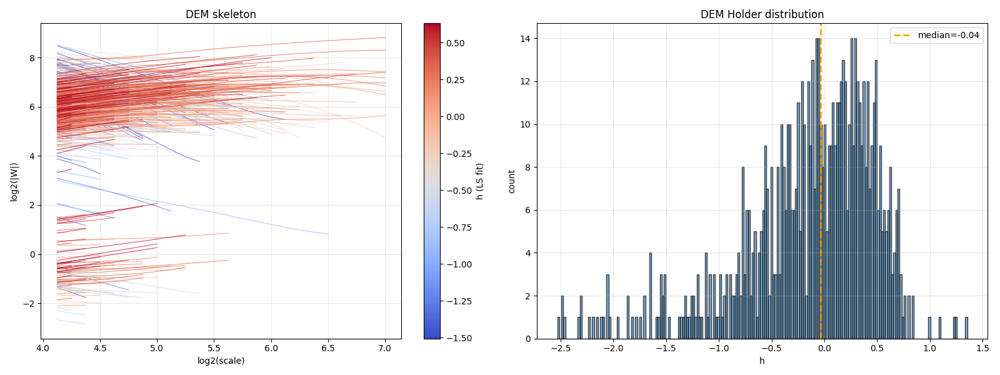

In [ ]:
# Cell 14c - DEM skeleton + spectra
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
log2_s_d = np.log2(scales_dem)

items = []
for ch in dem_chains[:5000]:
    n = len(ch['mod'])
    if n < 2: continue
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h = dem_h_fit_lookup.get(key, np.nan)
    if not np.isfinite(h): continue
    items.append((h, n, ch['log2_mod']))

if items:
    items.sort(key=lambda t: t[0])
    hv = np.array([t[0] for t in items])
    vn, vx = np.percentile(hv, [5, 95])
    if vn == vx: vn, vx = hv.min(), hv.max()
    nm = Normalize(vmin=vn, vmax=vx)
    cm = plt.cm.coolwarm
    for h, n, lm in items:
        axes[0].plot(log2_s_d[:n], lm, '-', color=cm(nm(h)), alpha=0.8, lw=0.7)
    sm = ScalarMappable(norm=nm, cmap=cm); sm.set_array([])
    plt.colorbar(sm, ax=axes[0], label='h (LS fit)')
axes[0].set(xlabel='log2(scale)', ylabel='log2(|W|)', title='DEM skeleton')
axes[0].grid(True, alpha=0.3)

axes[1].hist(h_dem[np.isfinite(h_dem)], bins=200, color='steelblue', edgecolor='k', alpha=0.7)
axes[1].axvline(np.nanmedian(h_dem), color='orange', ls='--', lw=2,
                label=f'median={np.nanmedian(h_dem):.2f}')
axes[1].set(xlabel='h', ylabel='count', title='DEM Holder distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 14d - DEM interactive partition function
%matplotlib widget
from IPython.display import display, clear_output
import ipywidgets as widgets
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Filter DEM chains
log2_mod_min_dem = -8.0
dem_filtered = [ch for ch in dem_chains
                if len(ch['mod']) >= 3 and np.mean(ch['log2_mod']) >= log2_mod_min_dem]
print(f"DEM filtered: {len(dem_filtered)} / {len(dem_chains)} chains")

dem_filt_pos = set()
for ch in dem_filtered:
    for si in range(min(len(ch['mod']), len(scales_dem))):
        dem_filt_pos.add((si, int(ch['x'][si]), int(ch['y'][si])))

# Chainmax lookup
dem_chainmax = [{} for _ in range(len(scales_dem))]
for ch in dem_filtered:
    running_max = 0.0
    for si in range(min(len(ch['mod']), len(scales_dem))):
        m = abs(float(ch['mod'][si]))
        if m > running_max: running_max = m
        dem_chainmax[si][(int(ch['x'][si]), int(ch['y'][si]))] = running_max

q_dem = np.concatenate([np.arange(-4, -2, 0.5), np.arange(-2, 5.1, 0.1), np.arange(5.5, 10, 0.5)])
n_q_d = len(q_dem)
n_sc_d = len(scales_dem)
log2_c = np.log(2.0)

STq_d = np.zeros((n_q_d, n_sc_d), dtype=np.float64)
STqlogT_d = np.zeros((n_q_d, n_sc_d), dtype=np.float64)
STq_ds = np.zeros((n_q_d, n_sc_d), dtype=np.float64)
STqlogT_ds = np.zeros((n_q_d, n_sc_d), dtype=np.float64)

for j, ext in enumerate(dem_ext_images):
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    ml, msl = [], []
    for k in range(ext.extr_nb):
        if on_vc[k]:
            pk = (j, int(data['x'][k]), int(data['y'][k]))
            if pk in dem_filt_pos:
                m = abs(float(data['mod'][k]))
                if m > 0:
                    ml.append(m)
                    xy = (int(data['x'][k]), int(data['y'][k]))
                    msl.append(max(dem_chainmax[j].get(xy, m), 1e-30))
    if not ml: continue
    mod = np.array(ml, dtype=np.float64)
    mod_s = np.array(msl, dtype=np.float64)
    lm, lms = np.log(mod), np.log(mod_s)
    for i, q in enumerate(q_dem):
        mq = mod ** q if q != 0 else np.ones(len(mod))
        STq_d[i,j] = np.sum(mq); STqlogT_d[i,j] = np.sum(lm * mq)
        mqs = mod_s ** q if q != 0 else np.ones(len(mod_s))
        STq_ds[i,j] = np.sum(mqs); STqlogT_ds[i,j] = np.sum(lms * mqs)

def build_hd_dem(S, Sl):
    t = np.full((n_q_d, n_sc_d), np.nan)
    h = np.full((n_q_d, n_sc_d), np.nan)
    D = np.full((n_q_d, n_sc_d), np.nan)
    v = S > 0
    t[v] = np.log(S[v]) / log2_c
    h[v] = Sl[v] / (log2_c * S[v])
    for i, q in enumerate(q_dem):
        for j in range(n_sc_d):
            if S[i,j] > 0:
                D[i,j] = (q * Sl[i,j] - S[i,j] * np.log(S[i,j])) / (S[i,j] * log2_c)
    return {'tau_qa': t, 'h_qa': h, 'D_qa': D, 'q_list': q_dem,
            'scales': np.array(scales_dem), 'log2_scales': np.log2(np.array(scales_dem))}

hd_dem_std = build_hd_dem(STq_d, STqlogT_d)
hd_dem_cmax = build_hd_dem(STq_ds, STqlogT_ds)

fit_dem = {'scale_min': scales_dem[0], 'scale_max': scales_dem[-1]}
log2_sd = hd_dem_std['log2_scales']

cm_toggle = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='Method:')
out_pf_d = widgets.Output()
out_sp_d = widgets.Output()
q_sh = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
col_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_sh)))

def get_hd_dem(): return hd_dem_std if cm_toggle.value == 'Standard' else hd_dem_cmax

def draw_dem():
    smin, smax = fit_dem['scale_min'], fit_dem['scale_max']
    smask = (np.array(scales_dem) >= smin) & (np.array(scales_dem) <= smax)
    hd = get_hd_dem(); meth = cm_toggle.value

    with out_pf_d:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for p, (k, yl, tl) in enumerate([('tau_qa','log2 Z','tau(q,a)'),
                                           ('h_qa','h(q,a)','h(q,a)'),
                                           ('D_qa','D(q,a)','D(q,a)')]):
            ax = axes[p]
            for qi, c in zip(q_sh, col_q):
                idx = np.argmin(np.abs(hd['q_list'] - qi))
                y = hd[k][idx]; v = np.isfinite(y)
                if v.sum() < 2: continue
                ax.plot(log2_sd[v], y[v], 'o', color=c, ms=3, alpha=0.7, mec='none')
                yf = y[smask]; xf = log2_sd[smask]; vf = np.isfinite(yf)
                if vf.sum() >= 2:
                    try:
                        sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                        xl = log2_sd[v]
                        ax.plot(xl, sl*xl+ic, '-', color=c, lw=1.2, alpha=0.5)
                        ax.text(xl[-1]+0.05, sl*xl[-1]+ic, f'{qi:g}', color=c, fontsize=7, va='center')
                    except: pass
            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel='log2(a)', ylabel=yl, title=tl); ax.grid(True, alpha=0.2)
        fig.suptitle(f'DEM {meth} -- L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()
        def on_click(e):
            if e.inaxes is None or e.xdata is None: return
            a = 2 ** e.xdata
            if e.button == 1: fit_dem['scale_min'] = a
            elif e.button == 3: fit_dem['scale_max'] = a
            if fit_dem['scale_min'] > fit_dem['scale_max']:
                fit_dem['scale_min'], fit_dem['scale_max'] = fit_dem['scale_max'], fit_dem['scale_min']
            draw_dem()
        fig.canvas.mpl_connect('button_press_event', on_click); plt.show()

    if smask.sum() < 2: return
    res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
    q = res['q_list']; val = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])
    with out_sp_d:
        clear_output(wait=True)
        if not val.any(): print("No valid spectra"); return
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax1 = axes[0]
        ax1.errorbar(q[val], res['tau'][val], yerr=res['tau_err'][val],
                     fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
        ax1.set(xlabel='q', ylabel='tau(q)'); ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)
        ax2 = ax1.twinx()
        ax2.errorbar(q[val], res['h'][val], yerr=res['h_err'][val],
                     fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
        ax2.set(ylabel='h(q)'); ax2.tick_params(axis='y', labelcolor='red')
        hw = res['h'][val].max() - res['h'][val].min()
        ax1.set_title(f'tau(q) & h(q) -- DEM {meth} -- dh={hw:.3f}')
        l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
        ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8)
        ax = axes[1]
        sc = ax.scatter(res['h'][val], res['D'][val], c=q[val], cmap='coolwarm',
                        s=60, edgecolors='black', linewidths=0.5, zorder=5)
        ax.errorbar(res['h'][val], res['D'][val], xerr=res['h_err'][val], yerr=res['D_err'][val],
                    fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)
        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        pk = np.argmax(res['D'][val])
        ax.plot(res['h'][val][pk], res['D'][val][pk], 'r*', ms=18, zorder=10)
        ax.annotate(f"h*={res['h'][val][pk]:.3f}\nD*={res['D'][val][pk]:.3f}",
                    xy=(res['h'][val][pk], res['D'][val][pk]),
                    xytext=(res['h'][val][pk]+0.05, res['D'][val][pk]-0.15),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', fc='lightyellow'))
        ax.set(xlabel='h', ylabel='D(h)', title=f'D(h) -- DEM {meth}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
        fig.tight_layout(); plt.show()

def on_t(change): draw_dem()
cm_toggle.observe(on_t, names='value')
print("LEFT-click = min scale | RIGHT-click = max scale")
display(cm_toggle); display(out_pf_d); display(out_sp_d)
draw_dem()

DEM filtered: 3505 / 3961 chains
LEFT-click = min scale | RIGHT-click = max scale


ToggleButtons(description='Method:', options=('Standard', 'Chainmax'), value='Standard')

Output()

Output()

In [ ]:
# Cell 15 - Phase-resolved WTMM viewer (chain-level weights over fitted scale range)
# Each vertical chain's contribution to Z(q) is integrated over the fit scale range.
# Classification by which q regime a chain dominates in.

from ipywidgets import interact, IntRangeSlider, IntSlider, FloatSlider, FloatRangeSlider, Dropdown, Checkbox, Layout
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

# Auto-detect which analysis was run last
try:
    phase_ext_images = insar_ext_images
    phase_scales = scales_insar
    phase_chains = insar_chains
    phase_bg_raw = insar_bg.astype(np.float64)
    phase_label = 'InSAR'
    phase_hgt = hgt.astype(np.float64) if 'hgt' in dir() else None
    phase_coh = coh_asc.astype(np.float64) if 'coh_asc' in dir() else None
    phase_h_lookup = insar_h_fit_lookup if 'insar_h_fit_lookup' in dir() else {}
    phase_chain_lookup = insar_chain_lookup if 'insar_chain_lookup' in dir() else {}
except NameError:
    try:
        phase_ext_images = dem_ext_images
        phase_scales = scales_dem
        phase_chains = dem_chains
        phase_bg_raw = dem_image.astype(np.float64)
        phase_label = 'DEM'
        phase_hgt = dem_image.astype(np.float64)
        phase_coh = None
        phase_h_lookup = dem_h_fit_lookup if 'dem_h_fit_lookup' in dir() else {}
        phase_chain_lookup = dem_chain_lookup if 'dem_chain_lookup' in dir() else {}
    except NameError:
        phase_ext_images = t_ext_images
        phase_scales = scales
        phase_chains = t_chains
        phase_bg_raw = (t_image if 't_image' in dir() else np.zeros((512,512))).astype(np.float64)
        phase_label = 'Tensor'
        phase_hgt = None
        phase_coh = None
        phase_h_lookup = t_h_fit_lookup if 't_h_fit_lookup' in dir() else {}
        phase_chain_lookup = t_chain_lookup if 't_chain_lookup' in dir() else {}

n_ps = len(phase_scales)
ny_p, nx_p = phase_bg_raw.shape
ds_p = max(1, max(ny_p, nx_p) // 800)

# Background options
def _heq(img):
    flat = img.ravel()
    h, bins = np.histogram(flat[np.isfinite(flat)], bins=1000)
    cdf = h.cumsum().astype(np.float64); cdf /= cdf[-1]
    return np.interp(flat, bins[:-1], cdf).reshape(img.shape)

phase_bg_dict = {
    'Image (linear)': phase_bg_raw,
    'Image (log)': np.log1p(phase_bg_raw - np.nanmin(phase_bg_raw)),
    'Image (hist EQ)': _heq(np.nan_to_num(phase_bg_raw, nan=0.0)),
}
if phase_hgt is not None:
    phase_bg_dict['DEM (linear)'] = phase_hgt
    phase_bg_dict['DEM (log)'] = np.log1p(phase_hgt - np.nanmin(phase_hgt))
    phase_bg_dict['DEM (hist EQ)'] = _heq(np.nan_to_num(phase_hgt, nan=0.0))
if phase_coh is not None:
    phase_bg_dict['Coherence'] = phase_coh
phase_bg_dict['None'] = None

# Precompute line segments per scale
phase_line_segs = []
for si in range(n_ps):
    ext = phase_ext_images[si]
    line_list = ext.get_lines()
    lx_ext = ext.lx
    segs, seg_li = [], []
    for li, line in enumerate(line_list):
        pos = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(pos) < 2: continue
        xs = (pos % lx_ext).astype(np.float64)
        ys = (pos // lx_ext).astype(np.float64)
        segs.append(np.column_stack([xs, ys]))
        seg_li.append(li)
    phase_line_segs.append({'segs': segs, 'li': np.array(seg_li, dtype=np.int32)})

# Precompute chain data: for each chain, store (anchor, scales, mods, positions per scale)
chain_data = []
for ci, ch in enumerate(phase_chains):
    n = len(ch['mod'])
    if n < 2: continue
    chain_data.append({
        'anchor': (int(ch['x'][0]), int(ch['y'][0])),
        'x': ch['x'], 'y': ch['y'],
        'mod': np.abs(ch['mod']).astype(np.float64),
        'n_scales': n,
        'ci': ci,
    })

print(f"Phase viewer: {n_ps} scales, {len(chain_data)} chains (>= 2 scales), "
      f"{sum(len(l['segs']) for l in phase_line_segs)} line segments")

def compute_chain_phase_weights(chain_data, phase_scales, q_neg, q_pos, fit_range, use_sup=False):
    """For each chain, compute integrated Boltzmann weight over fit scale range at 3 q values.
    If use_sup=True, uses running max (supremum) of modulus along each chain (chainmax method).
    Returns array of (n_chains, 3) with weights at q_neg, q_mid, q_pos."""
    s_arr = np.array(phase_scales)
    fit_mask = (s_arr >= fit_range[0]) & (s_arr <= fit_range[1])
    fit_indices = np.where(fit_mask)[0]
    q_mid = (q_neg + q_pos) / 2
    
    n_chains = len(chain_data)
    chain_weights = np.zeros((n_chains, 3), dtype=np.float64)
    
    # Precompute running max if using supremum
    if use_sup:
        chain_sup = []
        for cd in chain_data:
            running_max = np.maximum.accumulate(cd['mod'])
            chain_sup.append(running_max)
    
    # For each scale in fit range, compute Z(q) and weights
    for si in fit_indices:
        # Collect moduli of all chains at this scale
        mods_at_scale = []
        chain_indices_at_scale = []
        for ci, cd in enumerate(chain_data):
            if si < cd['n_scales']:
                if use_sup:
                    mods_at_scale.append(chain_sup[ci][si])
                else:
                    mods_at_scale.append(cd['mod'][si])
                chain_indices_at_scale.append(ci)
        
        if not mods_at_scale:
            continue
        
        mods = np.array(mods_at_scale, dtype=np.float64)
        mods = np.maximum(mods, 1e-30)
        log_mods = np.log(mods)
        
        for qi, q_val in enumerate([q_neg, q_mid, q_pos]):
            log_w = q_val * log_mods
            log_w -= np.max(log_w)
            w = np.exp(log_w)
            Z = np.sum(w)
            if Z > 0:
                w /= Z
            for j, ci in enumerate(chain_indices_at_scale):
                chain_weights[ci, qi] += w[j]
    
    # Normalize over scales
    n_fit = len(fit_indices)
    if n_fit > 0:
        chain_weights /= n_fit
    
    return chain_weights

def draw_phase(scale_range, fit_range, q_boundaries, min_hchain, min_vc,
               use_sup, show_mode, bg_type, line_width, arrow_scale, point_size, cmap_name):
    
    si_lo, si_hi = scale_range
    fit_lo, fit_hi = fit_range
    fit_scales = (phase_scales[fit_lo], phase_scales[fit_hi])
    q_lo, q_hi = q_boundaries
    # Three representative q values: center of each region
    q_neg = q_lo - 1.0     # center of q < q_lo region
    q_mid = (q_lo + q_hi) / 2  # center of transition region
    q_pos = q_hi + 1.0     # center of q > q_hi region
    
    # Compute chain-level weights over fit range
    cw = compute_chain_phase_weights(chain_data, phase_scales, q_neg, q_pos, fit_scales, use_sup=use_sup)
    # cw columns: [0]=weight at q_neg, [1]=weight at q_mid, [2]=weight at q_pos
    
    # Classify chains
    chain_phase = np.argmax(cw, axis=1)  # 0=weak, 1=mid, 2=strong
    chain_max_w = np.max(cw, axis=1)
    
    # Build chain -> phase lookup by anchor
    anchor_phase = {}
    anchor_weight = {}
    for ci, cd in enumerate(chain_data):
        if cd['n_scales'] < min_vc:
            continue
        anchor_phase[cd['anchor']] = chain_phase[ci]
        anchor_weight[cd['anchor']] = chain_max_w[ci]
    
    # Build line -> phase lookup via chain_lookup
    q_mid = (q_neg + q_pos) / 2
    phase_colors = ['#2196F3', '#4CAF50', '#F44336']
    phase_labels = [f'q<{q_lo:.1f} (weak)', f'{q_lo:.1f}<q<{q_hi:.1f} (trans.)', f'q>{q_hi:.1f} (strong)']
    
    # --- Top: 3 panels showing weight at each q ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    for col, (q_val, title) in enumerate([
        (q_neg, f'q={q_neg:.1f} (q<{q_lo:.1f})'),
        (q_mid, f'q={q_mid:.1f} ({q_lo:.1f}<q<{q_hi:.1f})'),
        (q_pos, f'q={q_pos:.1f} (q>{q_hi:.1f})')]):
        
        ax = axes[col]
        bg = phase_bg_dict.get(bg_type)
        if bg is not None:
            cm_bg = 'terrain' if 'DEM' in bg_type else 'gray'
            ax.imshow(bg[::ds_p, ::ds_p], origin='lower', cmap=cm_bg,
                      rasterized=True, extent=[0, nx_p, 0, ny_p], alpha=0.5)
            ax.set_facecolor('black')
        else:
            ax.set_facecolor('white')
        
        n_pts = 0
        for si in range(si_lo, si_hi + 1):
            ls = phase_line_segs[si]
            if not ls['segs']:
                continue
            
            # Color lines by their chain's weight at this q
            filt_segs = []
            filt_w = []
            for j, seg in enumerate(ls['segs']):
                if len(seg) < min_hchain:
                    continue
                # Find which chain this line belongs to via chain_lookup
                li = ls['li'][j]
                best_w = 0
                for px, py in zip(seg[::max(1,len(seg)//3), 0].astype(int),
                                   seg[::max(1,len(seg)//3), 1].astype(int)):
                    info = phase_chain_lookup.get((si, px, py), (0, None))
                    if info[1] is not None and info[1] in anchor_weight:
                        best_w = max(best_w, cw[next((ci for ci, cd in enumerate(chain_data)
                                                       if cd['anchor'] == info[1]), -1), col]
                                     if next((ci for ci, cd in enumerate(chain_data)
                                              if cd['anchor'] == info[1]), -1) >= 0 else 0)
                        break
                filt_segs.append(seg)
                filt_w.append(best_w)
            
            if filt_segs:
                fw = np.array(filt_w)
                fw_n = fw / (fw.max() + 1e-30)
                lc = LineCollection(filt_segs, cmap=cmap_name,
                                    norm=Normalize(vmin=0, vmax=1),
                                    linewidths=line_width, alpha=0.8)
                lc.set_array(fw_n)
                ax.add_collection(lc)
                n_pts += sum(len(s) for s in filt_segs)
        
        ax.set_title(f'{title}\n{n_pts} pts', fontsize=10)
        ax.set_xlim(0, nx_p); ax.set_ylim(0, ny_p); ax.set_aspect('equal')
    
    plt.suptitle(f'{phase_label} — Boltzmann weights ({"chainmax" if use_sup else "standard"}, fit: a={fit_scales[0]:.1f}-{fit_scales[1]:.1f})',
                 fontsize=13)
    plt.tight_layout()
    plt.show()
    
    # --- Bottom row: 3 separate phase maps ---
    fig2, axes2 = plt.subplots(1, 3, figsize=(20, 7))
    
    all_phase_segs = [[], [], []]
    for si in range(si_lo, si_hi + 1):
        ls = phase_line_segs[si]
        if not ls['segs']: continue
        for j, seg in enumerate(ls['segs']):
            if len(seg) < min_hchain: continue
            phase_val = 1
            for px, py in zip(seg[::max(1,len(seg)//3), 0].astype(int),
                               seg[::max(1,len(seg)//3), 1].astype(int)):
                info = phase_chain_lookup.get((si, px, py), (0, None))
                if info[1] is not None and info[1] in anchor_phase:
                    phase_val = anchor_phase[info[1]]
                    break
            all_phase_segs[phase_val].append(seg)
    
    scope = f'scales {si_lo}-{si_hi} (a={phase_scales[si_lo]:.1f}-{phase_scales[si_hi]:.1f})'
    
    for pv, (ax, color, label) in enumerate(zip(axes2, phase_colors, phase_labels)):
        bg = phase_bg_dict.get(bg_type)
        if bg is not None:
            cm_bg = 'terrain' if 'DEM' in bg_type else 'gray'
            ax.imshow(bg[::ds_p, ::ds_p], origin='lower', cmap=cm_bg,
                      rasterized=True, extent=[0, nx_p, 0, ny_p], alpha=0.5)
            ax.set_facecolor('black')
        else:
            ax.set_facecolor('white')
        if all_phase_segs[pv]:
            lc = LineCollection(all_phase_segs[pv], colors=[color] * len(all_phase_segs[pv]),
                                linewidths=line_width, alpha=0.8)
            ax.add_collection(lc)
        ax.set_title(f'{label}\n{len(all_phase_segs[pv])} chains', fontsize=11)
        ax.set_xlim(0, nx_p); ax.set_ylim(0, ny_p); ax.set_aspect('equal')
    
    plt.suptitle(f'{phase_label} — Phase maps ({scope})', fontsize=13)
    plt.tight_layout()
    plt.show()

bg_options = list(phase_bg_dict.keys())

interact(
    draw_phase,
    scale_range=IntRangeSlider(value=[0, n_ps-1], min=0, max=n_ps-1,
                               description='View scales:', layout=Layout(width='70%'), continuous_update=False),
    fit_range=IntRangeSlider(value=[0, n_ps-1], min=0, max=n_ps-1,
                             description='Fit range:', layout=Layout(width='70%'), continuous_update=False),
    q_boundaries=FloatRangeSlider(value=[-1.0, 1.0], min=-10.0, max=10.0, step=0.1,
                                 description='q boundaries:', layout=Layout(width='70%'),
                                 continuous_update=False),
    min_hchain=IntSlider(value=10, min=1, max=500, step=5,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=20, step=1,
                     description='Min vc len:', layout=Layout(width='60%'), continuous_update=False),
    use_sup=Checkbox(value=False, description='Chainmax (supremum)'),
    show_mode=Dropdown(options=['Horizontal chains', 'Chains + arrows', 'WTMMM points'],
                       value='Horizontal chains', description='Show:'),
    bg_type=Dropdown(options=bg_options, value=bg_options[0], description='Background:'),
    line_width=FloatSlider(value=0.8, min=0.1, max=3.0, step=0.1,
                           description='Line width:', layout=Layout(width='60%'), continuous_update=False),
    arrow_scale=FloatSlider(value=5.0, min=0.5, max=50.0, step=0.5,
                            description='Arrow scale:', layout=Layout(width='60%'), continuous_update=False),
    point_size=FloatSlider(value=20.0, min=1.0, max=100.0, step=1.0,
                           description='Point size:', layout=Layout(width='60%'), continuous_update=False),
    cmap_name=Dropdown(options=['hot', 'magma', 'inferno', 'viridis', 'plasma', 'YlOrRd'],
                       value='hot', description='Weight cmap:'));

Phase viewer: 40 scales, 7043 chains (>= 2 scales), 92896 line segments


interactive(children=(IntRangeSlider(value=(0, 39), continuous_update=False, description='View scales:', layou…

In [ ]:
# Cell 15a - Precompute data for phase viewer (fast version)
import time
t0 = time.time()

# Auto-detect dataset
try:
    ph_ext = insar_ext_images; ph_s = scales_insar; ph_ch = insar_chains
    ph_bg_raw = insar_bg.astype(np.float64); ph_label = 'InSAR'
    ph_hgt = hgt.astype(np.float64) if 'hgt' in dir() else None
    ph_coh = coh_asc.astype(np.float64) if 'coh_asc' in dir() else None
    ph_cl = insar_chain_lookup if 'insar_chain_lookup' in dir() else {}
except NameError:
    try:
        ph_ext = dem_ext_images; ph_s = scales_dem; ph_ch = dem_chains
        ph_bg_raw = dem_image.astype(np.float64); ph_label = 'DEM'
        ph_hgt = dem_image.astype(np.float64); ph_coh = None
        ph_cl = dem_chain_lookup if 'dem_chain_lookup' in dir() else {}
    except NameError:
        ph_ext = t_ext_images; ph_s = scales; ph_ch = t_chains
        ph_bg_raw = (t_image if 't_image' in dir() else np.zeros((512,512))).astype(np.float64)
        ph_label = 'Tensor'; ph_hgt = None; ph_coh = None
        ph_cl = t_chain_lookup if 't_chain_lookup' in dir() else {}

# Use filtered chains if available
if 'filtered_insar_chains' in dir() and ph_label == 'InSAR':
    ph_ch = filtered_insar_chains
    print(f"Using filtered chains: {len(ph_ch)}")
else:
    print(f"Using all chains: {len(ph_ch)}")

nps = len(ph_s)
nyp, nxp = ph_bg_raw.shape
dsp = max(1, max(nyp, nxp) // 800)

def _heq(img):
    f = img.ravel()
    h, b = np.histogram(f[np.isfinite(f)], bins=1000)
    c = h.cumsum().astype(np.float64)
    c /= c[-1]
    return np.interp(f, b[:-1], c).reshape(img.shape)

bgd = {'Image (linear)': ph_bg_raw,
       'Image (log)': np.log1p(ph_bg_raw - np.nanmin(ph_bg_raw)),
       'Image (hist EQ)': _heq(np.nan_to_num(ph_bg_raw, nan=0.0))}
if ph_hgt is not None:
    bgd['DEM (linear)'] = ph_hgt
    bgd['DEM (hist EQ)'] = _heq(np.nan_to_num(ph_hgt, nan=0.0))
if ph_coh is not None:
    bgd['Coherence'] = ph_coh
bgd['None'] = None

# Per-scale: line segments (precomputed pts arrays)
ph_seg_pts = []
for si in range(nps):
    ext = ph_ext[si]
    ll = ext.get_lines()
    lx = ext.lx
    segs = []
    for li, line in enumerate(ll):
        pos = np.asarray(line['extrema_pos'], dtype=np.int64)
        if len(pos) < 2:
            continue
        segs.append(np.column_stack([
            (pos % lx).astype(np.float64),
            (pos // lx).astype(np.float64)
        ]))
    ph_seg_pts.append(segs)

# Per-scale: WTMMM log_mods + line indices
ph_log_mods = []
ph_wt_x = []
ph_wt_y = []
ph_wt_li = []

for si in range(nps):
    ext = ph_ext[si]
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    lx = ext.lx
    ll = ext.get_lines()
    pos_to_li = {}
    for li, line in enumerate(ll):
        for p in line['extrema_pos']:
            pos_to_li[int(p)] = li
    m = on_vc.astype(bool)
    if m.sum() > 0:
        wt_mod = np.maximum(np.abs(data['mod'][m]).astype(np.float64), 1e-30)
        ph_log_mods.append(np.log(wt_mod))
        ph_wt_x.append(data['x'][m].astype(np.float64))
        ph_wt_y.append(data['y'][m].astype(np.float64))
        ph_wt_li.append(np.array(
            [pos_to_li.get(int(data['pos'][m][j]), -1) for j in range(m.sum())],
            dtype=np.int32
        ))
    else:
        ph_log_mods.append(np.array([]))
        ph_wt_x.append(np.array([]))
        ph_wt_y.append(np.array([]))
        ph_wt_li.append(np.array([], dtype=np.int32))

# Earthquake data
import csv
eq_catalog = []
for ef in ['/Users/amasaryk/projects/Creep/wavelet/nepal_tensor_eqs_M0_alldepth.csv',
           '/Users/amasaryk/projects/Creep/wavelet/nepal_crop_eqs_M2_depth30.csv']:
    try:
        with open(ef) as f:
            for row in csv.DictReader(f):
                eq_catalog.append({
                    'lat': float(row['latitude']),
                    'lon': float(row['longitude']),
                    'mag': float(row['magnitude']),
                    'depth': float(row['depth_km']) if row['depth_km'] else None,
                    'time': row['time'][:10]
                })
        break
    except FileNotFoundError:
        continue

eq_px, eq_py, eq_mag, eq_label = [], [], [], []
if eq_catalog:
    try:
        import h5py
        with h5py.File('/Users/amasaryk/Downloads/Asc_cum_filt.h5', 'r') as f:
            clat, clon = float(f['corner_lat'][()]), float(f['corner_lon'][()])
            plat, plon = float(f['post_lat'][()]), float(f['post_lon'][()])
        for eq in eq_catalog:
            px = (eq['lon'] - clon) / plon
            py = (eq['lat'] - clat) / plat
            if 0 <= px < nxp and 0 <= py < nyp:
                eq_px.append(px)
                eq_py.append(py)
                eq_mag.append(eq['mag'])
                d_str = f"{eq['depth']:.0f}km" if eq.get('depth') else '?km'
                eq_label.append(f"M{eq['mag']:.1f} {eq['time']} {d_str}")
    except:
        pass
eq_px, eq_py, eq_mag = np.array(eq_px), np.array(eq_py), np.array(eq_mag)

q_spec = np.arange(-4, 4.25, 0.25)
log2_scales_ph = np.log2(np.array(ph_s))

# Georeferencing for coordinate labels + scale bar
try:
    import h5py
    with h5py.File('/Users/amasaryk/Downloads/Asc_cum_filt.h5', 'r') as _f:
        geo_clat = float(_f['corner_lat'][()])
        geo_clon = float(_f['corner_lon'][()])
        geo_plat = float(_f['post_lat'][()])
        geo_plon = float(_f['post_lon'][()])
    geo_pixel_km = abs(geo_plat) * 111.0  # approximate km per pixel
    has_geo = True
except:
    has_geo = False
    geo_clat, geo_clon, geo_plat, geo_plon, geo_pixel_km = 0, 0, -0.001, 0.001, 0.111

def px_to_latlon(px, py):
    """Convert pixel coords to lat/lon."""
    return geo_clat + py * geo_plat, geo_clon + px * geo_plon

def add_geo_labels(ax, nx, ny):
    """Add corner coordinates and scale bar to an axis."""
    if not has_geo:
        return
    # Corner labels
    corners = [(0, 0), (nx, 0), (0, ny), (nx, ny)]
    for px, py in corners:
        lat, lon = px_to_latlon(px, py)
        ax.annotate(f'{lat:.2f}N\n{lon:.2f}E', (px, py),
                    fontsize=6, color='white', alpha=0.8,
                    ha='left' if px < nx/2 else 'right',
                    va='bottom' if py < ny/2 else 'top',
                    bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.5))
    # Scale bar (bottom center)
    bar_km = 10  # 10 km scale bar
    bar_px = bar_km / geo_pixel_km
    bar_x = nx * 0.1
    bar_y = ny * 0.03
    ax.plot([bar_x, bar_x + bar_px], [bar_y, bar_y], 'w-', lw=3)
    ax.plot([bar_x, bar_x + bar_px], [bar_y, bar_y], 'k-', lw=1.5)
    ax.text(bar_x + bar_px / 2, bar_y + ny * 0.02, f'{bar_km} km',
            ha='center', fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.5))

# Fast rasterized rendering (like xsmurf's XImage approach)
# Pre-render chains to numpy RGBA buffer, display with imshow = 1 draw call
from PIL import Image, ImageDraw

def render_chains_to_image(bg_array, segs_by_scale, wtmmm_by_scale,
                           scale_range, min_hchain,
                           weights_by_scale=None, weight_thresh=1.0,
                           dom_color=(255, 60, 60), non_color=(80, 80, 80),
                           dom_width=1, non_width=1,
                           dom_alpha=0.70, non_alpha=0.18,
                           show_eqs=True, eq_color=(0, 255, 0)):
    """Render chains to a PIL image (fast rasterization like xsmurf).

    Returns RGBA numpy array ready for imshow.
    """
    ny, nx = bg_array.shape[:2]

    # Start with background
    if bg_array is None:
        bg_rgba = np.zeros((ny, nx, 4), dtype=np.uint8)
        bg_rgba[..., 3] = 255
        img = Image.fromarray(bg_rgba, mode='RGBA')
    elif bg_array.ndim == 2:
        bg_min = np.nanmin(bg_array)
        bg_max = np.nanmax(bg_array)
        bg_norm = ((bg_array - bg_min) / (bg_max - bg_min + 1e-30) * 200).astype(np.uint8)
        rgb = np.stack([bg_norm] * 3, axis=-1)
        alpha = np.full((ny, nx, 1), 255, dtype=np.uint8)
        img = Image.fromarray(np.concatenate([rgb, alpha], axis=-1), mode='RGBA')
    else:
        arr = bg_array[..., :3].astype(np.uint8)
        alpha = np.full((ny, nx, 1), 255, dtype=np.uint8)
        img = Image.fromarray(np.concatenate([arr, alpha], axis=-1), mode='RGBA')

    draw = ImageDraw.Draw(img, 'RGBA')
    si_lo, si_hi = scale_range

    dom_a = int(np.clip(dom_alpha, 0.0, 1.0) * 255)
    non_a = int(np.clip(non_alpha, 0.0, 1.0) * 255)

    # PIL line widths are effectively integer pixels
    dom_w = 0 if dom_width <= 0 else max(1, int(np.ceil(dom_width)))
    non_w = 0 if non_width <= 0 else max(1, int(np.ceil(non_width)))

    n_dom, n_non = 0, 0
    for si in range(si_lo, si_hi + 1):
        if si >= len(segs_by_scale):
            continue
        segs = segs_by_scale[si]

        # Get weights if available
        w = weights_by_scale[si] if weights_by_scale and si < len(weights_by_scale) else None
        dom_li = set()
        if w is not None and len(w) > 0:
            N = len(w)
            cutoff = weight_thresh / max(N, 1)
            wt_li = ph_wt_li[si] if si < len(ph_wt_li) else np.array([])
            for j in range(min(len(w), len(wt_li))):
                if w[j] >= cutoff and wt_li[j] >= 0:
                    dom_li.add(int(wt_li[j]))

        for seg_idx, pts in enumerate(segs):
            if len(pts) < min_hchain:
                continue

            is_dom = seg_idx in dom_li if dom_li else True
            color = dom_color if is_dom else non_color
            alpha = dom_a if is_dom else non_a
            width = dom_w if is_dom else non_w

            # Draw polyline directly to pixel buffer
            coords = [(int(x), int(ny - 1 - y)) for x, y in pts[::max(1, len(pts)//200)]]
            if len(coords) >= 2 and width > 0 and alpha > 0:
                draw.line(coords, fill=(*color, alpha), width=width)
                if is_dom:
                    n_dom += 1
                else:
                    n_non += 1

    # Draw earthquakes
    if show_eqs and len(eq_px) > 0:
        eqc = tuple(eq_color)
        for j in range(len(eq_px)):
            ex, ey = int(eq_px[j]), int(ny - 1 - eq_py[j])
            r = int(eq_mag[j] * 3)
            draw.ellipse([ex-r, ey-r, ex+r, ey+r], outline=(*eqc, 160), width=2)
            draw.text((ex+r+2, ey-5), eq_label[j], fill=(*eqc, 255))

    return np.array(img), n_dom, n_non

print(f"Ready: {nps} scales, {sum(len(x) for x in ph_wt_x)} WTMMM, "
      f"{sum(len(s) for s in ph_seg_pts)} segments, {len(eq_px)} earthquakes")
print(f"  Time: {time.time()-t0:.1f}s")

Using filtered chains: 952
Ready: 40 scales, 14798 WTMMM, 28844 segments, 7 earthquakes
  Time: 0.8s


In [ ]:
# Cell 15b - Map viewer: WTMMM classified at a single scale
# SELF-CONTAINED: builds skel_chains + classification inline (no need to run 16a/16b first)
from ipywidgets import interact, IntRangeSlider, IntSlider, FloatSlider, Dropdown, Checkbox, Layout
from PIL import Image, ImageDraw

# --- Build skel_chains + classification arrays from ph_ch (same as 16a) ---
try:
    _use_filt = len(filtered_insar_positions) > 0
except NameError:
    _use_filt = False

q_grid_skel = np.arange(-5, 5.25, 0.25)
n_q_skel = len(q_grid_skel)

skel_chains = []
for ch in ph_ch:
    n = len(ch['mod'])
    if n < 3: continue
    if _use_filt:
        in_filter = any((si, int(ch['x'][si]), int(ch['y'][si])) in filtered_insar_positions
                        for si in range(min(n, len(ph_s))))
        if not in_filter: continue
    mods = np.maximum(np.abs(ch['mod']).astype(np.float64), 1e-30)
    skel_chains.append({
        'log2_s': np.log2(np.array(ph_s[:n])),
        'log2_m': np.log2(mods),
        'mod': mods,
        'n': n,
        'x0': int(ch['x'][0]), 'y0': int(ch['y'][0]),
    })

n_ch = len(skel_chains)
nps = len(ph_s)
chain_n = np.array([sc['n'] for sc in skel_chains], dtype=np.int32)

# mod_matrix: (n_ch, nps)
mod_matrix = np.full((n_ch, nps), np.nan, dtype=np.float64)
for ci, sc in enumerate(skel_chains):
    mod_matrix[ci, :sc['n']] = sc['mod']

mod_safe = np.where(np.isnan(mod_matrix), np.nan, np.maximum(mod_matrix, 1e-30))
log2_mod_matrix = np.log2(mod_safe)
valid_mask = ~np.isnan(mod_safe)

running_max_matrix = np.full_like(mod_safe, np.nan)
for ci in range(n_ch):
    n = chain_n[ci]
    if n > 0:
        running_max_matrix[ci, :n] = np.maximum.accumulate(mod_safe[ci, :n])
log2_running_max_matrix = np.log2(running_max_matrix)

# Z(q,a)
Z_qa = np.zeros((n_q_skel, nps), dtype=np.float64)
for i_q, q in enumerate(q_grid_skel):
    for si in range(nps):
        v = mod_matrix[:, si]
        ok = ~np.isnan(v)
        if ok.any():
            Z_qa[i_q, si] = np.nansum(v[ok] ** q) if q != 0 else float(ok.sum())

print(f"15b: {n_ch} chains, {nps} scales, Z_qa ready")

# --- Helper functions (same as 16b) ---
def _mods_for_mode(use_chainmax):
    return (running_max_matrix, log2_running_max_matrix) if use_chainmax else (mod_safe, log2_mod_matrix)

def _weights_at_scale(i_q, scale_idx, classify_chainmax, min_vc):
    q = q_grid_skel[i_q]
    mods_mat, _ = _mods_for_mode(classify_chainmax)
    w = np.zeros(n_ch, dtype=np.float64)
    valid = (chain_n >= min_vc) & valid_mask[:, scale_idx]
    if not np.any(valid): return w
    z = Z_qa[i_q, scale_idx]
    if z <= 0: return w
    if q == 0:
        w[valid] = 1.0 / z
    else:
        w[valid] = np.power(mods_mat[valid, scale_idx], q) / z
    return w

def _threshold_values(i_q, scale_idx, classify_chainmax, thresh_mode, min_vc):
    q = q_grid_skel[i_q]
    mods_mat, log2mods_mat = _mods_for_mode(classify_chainmax)
    vals = np.zeros(n_ch, dtype=np.float64)
    vc = (chain_n >= min_vc)
    if thresh_mode == 'None (all dominant)': return vals
    if thresh_mode == '|M|^q at scale':
        ok = vc & valid_mask[:, scale_idx]
        vals[ok] = np.power(mods_mat[ok, scale_idx], q) if q != 0 else 1.0
    elif thresh_mode == 'log2|M| at scale':
        ok = vc & valid_mask[:, scale_idx]
        vals[ok] = log2mods_mat[ok, scale_idx]
    elif thresh_mode == 'sup |M|^q (all scales)':
        if q == 0: vals[vc] = 1.0
        else:
            with np.errstate(invalid='ignore'):
                vals = np.nanmax(np.power(mods_mat, q), axis=1)
            vals[~vc] = 0.0
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
    elif thresh_mode == 'W(q,a) at scale':
        z = Z_qa[i_q, scale_idx]
        if z > 0:
            ok = vc & valid_mask[:, scale_idx]
            if q == 0:
                vals[ok] = 1.0 / z
            else:
                vals[ok] = np.power(mods_mat[ok, scale_idx], q) / z
    elif thresh_mode == 'sup W(q,a)':
        for si in range(nps):
            z = Z_qa[i_q, si]
            if z <= 0: continue
            ok = vc & valid_mask[:, si]
            if q == 0:
                w_si = np.where(ok, 1.0 / z, 0.0)
            else:
                w_si = np.zeros(n_ch)
                w_si[ok] = np.power(mods_mat[ok, si], q) / z
            vals = np.maximum(vals, w_si)
    return vals

def _dominant_mask(w_all, coeff_vals, thresh_mode, weight_thresh):
    if thresh_mode == 'None (all dominant)': return w_all > 0
    return coeff_vals >= weight_thresh

# ---- Interactive viewer ----
def draw_map(scale_idx, fit_range, q_val, min_vc, classify_chainmax, display_chainmax,
             thresh_mode, weight_thresh,
             show_mode, bg_type, show_eqs, eq_color,
             dom_color, dom_alpha, non_color_name, non_alpha,
             dom_width, non_width, point_size):
    
    i_q = int(np.argmin(np.abs(q_grid_skel - q_val)))
    
    w_all = _weights_at_scale(i_q, scale_idx, classify_chainmax, min_vc)
    coeff_vals = _threshold_values(i_q, scale_idx, classify_chainmax, thresh_mode, min_vc)
    is_dom = _dominant_mask(w_all, coeff_vals, thresh_mode, weight_thresh)
    valid_draw = (chain_n >= min_vc) & (w_all > 0)
    is_dom &= valid_draw
    
    _cm = {'red':(255,60,60), 'yellow':(255,255,0), 'cyan':(0,255,255),
           'lime':(0,255,0), 'magenta':(255,0,255), 'orange':(255,165,0),
           'white':(255,255,255), 'gray':(120,120,120), 'dark gray':(60,60,60),
           'blue':(50,100,255), 'green':(50,200,50)}
    dc = _cm.get(dom_color, (255,60,60))
    nc = _cm.get(non_color_name, (60,60,60))
    da = int(np.clip(dom_alpha, 0, 1) * 255)
    na = int(np.clip(non_alpha, 0, 1) * 255)
    dw = max(1, int(dom_width))
    nw = max(0, int(non_width))
    
    # Background
    bg = bgd.get(bg_type)
    if bg is None:
        rendered = np.full((nyp, nxp, 3), 128, dtype=np.uint8)
    elif bg.ndim == 2:
        bg_n = ((bg - np.nanmin(bg)) / (np.nanmax(bg) - np.nanmin(bg) + 1e-30) * 200).astype(np.uint8)
        rendered = np.stack([bg_n]*3, axis=-1)
    else:
        rendered = bg[..., :3].astype(np.uint8)
    
    img = Image.fromarray(rendered).convert('RGBA')
    draw = ImageDraw.Draw(img, 'RGBA')
    
    n_dom_pts, n_non_pts = 0, 0
    
    # H-chains
    if show_mode in ('Chains + WTMMM', 'Chains + maxima lines', 'Chains only'):
        for seg_idx, pts in enumerate(ph_seg_pts[scale_idx]):
            if len(pts) < 10: continue
            has_dom = False
            wt_li = ph_wt_li[scale_idx] if scale_idx < len(ph_wt_li) else np.array([])
            for j in range(len(wt_li)):
                if int(wt_li[j]) == seg_idx and is_dom[j] if j < len(is_dom) else False:
                    has_dom = True; break
            color_seg = dc if has_dom else nc
            alpha_seg = da if has_dom else na
            width_seg = dw if has_dom else nw
            if width_seg <= 0 or alpha_seg <= 0: continue
            coords = [(int(x), int(nyp-1-y)) for x, y in pts[::max(1, len(pts)//200)]]
            if len(coords) >= 2:
                draw.line(coords, fill=(*color_seg, alpha_seg), width=width_seg)
    
    # WTMMM points
    if show_mode in ('Chains + WTMMM', 'WTMMM only', 'Arrows (argument)'):
        wx = ph_wt_x[scale_idx] if scale_idx < len(ph_wt_x) else np.array([])
        wy = ph_wt_y[scale_idx] if scale_idx < len(ph_wt_y) else np.array([])
        for j in range(len(wx)):
            if j >= len(w_all) or w_all[j] <= 0: continue
            if chain_n[j] < min_vc if j < len(chain_n) else True: continue
            is_d = is_dom[j] if j < len(is_dom) else False
            color_pt = dc if is_d else nc
            alpha_pt = da if is_d else na
            if alpha_pt <= 0: continue
            px, py = int(wx[j]), int(nyp - 1 - wy[j])
            if show_mode == 'Arrows (argument)':
                mod_val = np.exp(ph_log_mods[scale_idx][j]) if j < len(ph_log_mods[scale_idx]) else 0
                mod_max_s = np.exp(np.max(ph_log_mods[scale_idx])) if len(ph_log_mods[scale_idx]) > 0 else 1
                mod_n = mod_val / (mod_max_s + 1e-30)
                try:
                    ext_data = ph_ext[scale_idx].get_extrema_arrays()
                    on_vc = ph_ext[scale_idx].get_on_vertical_chain()
                    vc_idx = np.where(on_vc)[0]
                    arg_val = float(ext_data['arg'][vc_idx[j]]) if j < len(vc_idx) else 0
                except: arg_val = 0
                arrow_len = mod_n * point_size
                dx_a, dy_a = np.cos(arg_val)*arrow_len, -np.sin(arg_val)*arrow_len
                draw.line([(px, py), (int(px+dx_a), int(py+dy_a))], fill=(*color_pt, alpha_pt), width=max(1, dw))
                draw.ellipse([px-2, py-2, px+2, py+2], fill=(*color_pt, alpha_pt))
            else:
                r = max(2, int(point_size / 10))
                w_n = w_all[j] / (w_all.max() + 1e-30)
                r_scaled = max(1, int(r * (0.3 + 0.7 * w_n)))
                draw.ellipse([px-r_scaled, py-r_scaled, px+r_scaled, py+r_scaled], fill=(*color_pt, alpha_pt))
            if is_d: n_dom_pts += 1
            else: n_non_pts += 1
    
    # Maxima lines
    if show_mode in ('Maxima lines', 'Chains + maxima lines'):
        for ci in range(n_ch):
            if chain_n[ci] < min_vc or not valid_draw[ci]: continue
            is_d = is_dom[ci]
            color_ml, alpha_ml, width_ml = (dc, da, dw) if is_d else (nc, na, nw)
            if width_ml <= 0 or alpha_ml <= 0: continue
            n = chain_n[ci]
            xs = [int(ph_ch[ci]['x'][si]) for si in range(min(n, nps))]
            ys = [int(nyp - 1 - ph_ch[ci]['y'][si]) for si in range(min(n, nps))]
            coords = list(zip(xs, ys))
            if len(coords) >= 2:
                draw.line(coords, fill=(*color_ml, alpha_ml), width=width_ml)
    
    # Earthquakes
    if show_eqs and len(eq_px) > 0:
        eqc = _cm.get(eq_color, (0,255,0))
        for j in range(len(eq_px)):
            ex, ey = int(eq_px[j]), int(nyp - 1 - eq_py[j])
            r = int(eq_mag[j] * 3)
            draw.ellipse([ex-r, ey-r, ex+r, ey+r], outline=(*eqc, 100), width=2)
            draw.text((ex+r+2, ey-5), eq_label[j], fill=(*eqc, 255))
    
    rendered = np.array(img.convert('RGB'))
    
    # ---- FIGURE: map + |M|^q profile + D(h) spectrum ----
    fig, (ax_map, ax_prof, ax_dh) = plt.subplots(1, 3, figsize=(26, 10),
                                                   gridspec_kw={'width_ratios': [3, 1, 1]})
    
    # Left: map
    ax_map.imshow(rendered, origin='upper', extent=[0, nxp, 0, nyp], aspect='equal')
    method = 'chainmax' if classify_chainmax else 'standard'
    ax_map.set_title(f'q={q_val:.2f} scale {scale_idx} (a={ph_s[scale_idx]:.1f}) | '
                     f'{method} | {n_dom_pts} dom, {n_non_pts} non-dom WTMMM', fontsize=11)
    ax_map.set_xlim(0, nxp); ax_map.set_ylim(0, nyp)
    try: add_geo_labels(ax_map, nxp, nyp)
    except: pass
    
    # Middle: |M(a)|^q profile colored by Boltzmann weight
    log2_s = np.log2(np.array(ph_s))
    fit_lo, fit_hi = fit_range
    q = q_grid_skel[i_q]
    mods_mat, _ = _mods_for_mode(classify_chainmax)
    cmap_prof = plt.cm.brg
    
    # Boltzmann weight for coloring
    w_color = np.zeros(n_ch, dtype=np.float64)
    for ci in range(n_ch):
        if chain_n[ci] < min_vc or not valid_draw[ci]: continue
        sc = skel_chains[ci]
        if classify_chainmax:
            best_w = 0.0
            for si in range(sc['n']):
                if Z_qa[i_q, si] <= 0: continue
                m = running_max_matrix[ci, si]
                if np.isnan(m): continue
                ww = (m ** q / Z_qa[i_q, si]) if q != 0 else (1.0 / Z_qa[i_q, si])
                if ww > best_w: best_w = ww
            w_color[ci] = best_w
        else:
            w_color[ci] = w_all[ci]
    
    w_max = w_color.max() if w_color.max() > 0 else 1.0
    
    # Draw chains: y = |M(a)|^q, log y-scale, colored by W
    draw_order = np.argsort(w_color)
    for ci in draw_order:
        if chain_n[ci] < min_vc or ci >= len(valid_draw) or not valid_draw[ci]: continue
        sc = skel_chains[ci]
        n_sc = sc['n']
        if n_sc < 2: continue
        l2s = sc['log2_s']
        if display_chainmax:
            mvals = running_max_matrix[ci, :n_sc]
        else:
            mvals = sc['mod'][:n_sc]
        yvals = np.power(mvals, q) if q != 0 else mvals
        
        wn = w_color[ci] / w_max
        ax_prof.plot(l2s, yvals, '-', color=cmap_prof(wn),
                     lw=0.3 + 1.5*wn, alpha=0.15 + 0.85*wn,
                     zorder=1 + int(wn*10))
    
    ax_prof.axvline(log2_s[scale_idx], color='blue', ls='--', alpha=0.6, lw=1.5, label=f'scale {scale_idx}')
    ax_prof.axvspan(log2_s[fit_lo], log2_s[fit_hi], alpha=0.08, color='yellow', label='fit range')
    if thresh_mode != 'None (all dominant)' and weight_thresh != 0:
        ax_prof.axhline(weight_thresh, color='cyan', ls=':', lw=1.5, alpha=0.8,
                        label=f'thresh={weight_thresh:.1f}')
    
    sm = plt.cm.ScalarMappable(cmap=cmap_prof, norm=plt.Normalize(0, w_max))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax_prof, fraction=0.03, pad=0.02)
    cb.set_label('W(q,a)', fontsize=9)
    
    classify_label = 'classify:chainmax' if classify_chainmax else 'classify:raw'
    display_label = 'display:chainmax' if display_chainmax else 'display:raw'
    mode_label = f'{display_label}'
    qlabel = f'|M|^{q:.1f}' if q != 0 else '|M|'
    ax_prof.set(xlabel='log2(scale)', ylabel=qlabel,
                title=f'{qlabel} [{display_label}] colored by W [{classify_label}]')
    ax_prof.legend(fontsize=7, loc='upper left')
    ax_prof.grid(True, alpha=0.2)
    
    # Right: D(h) singularity spectrum — uses ph_ext + chainmax_insar (same as Cell 13g)
    from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus
    fit_lo_s, fit_hi_s = ph_s[fit_lo], ph_s[fit_hi]
    sr = (fit_lo_s, fit_hi_s)
    
    try:
        _use_filt_spec = len(filtered_insar_positions) > 0
    except NameError:
        _use_filt_spec = False
    
    try:
        _has_chainmax = len(chainmax_insar) > 0
    except NameError:
        _has_chainmax = False
    
    q_pf = np.arange(-5, 5.25, 0.25)
    n_q_pf = len(q_pf)
    n_sc_pf = len(ph_s)
    log2_c = np.log(2.0)
    
    STq_all = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT_all = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STq_dom = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT_dom = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STq_non = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT_non = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    
    for j, ext in enumerate(ph_ext):
        data = ext.get_extrema_arrays()
        on_vc = ext.get_on_vertical_chain()
        w_scale = get_w(j, q_val, display_chainmax)
        
        mod_all_l, mod_dom_l, mod_non_l = [], [], []
        wt_idx = 0
        for k in range(ext.extr_nb):
            if not on_vc[k]:
                continue
            pos_key = (j, int(data['x'][k]), int(data['y'][k]))
            if _use_filt_spec and pos_key not in filtered_insar_positions:
                wt_idx += 1; continue
            # Check chain length
            try:
                vc_info = ph_cl.get(pos_key, (0, None))
                if vc_info[0] < min_vc:
                    wt_idx += 1; continue
            except:
                pass
            m = abs(float(data['mod'][k]))
            if m <= 0:
                wt_idx += 1; continue
            
            # Apply chainmax if selected
            if display_chainmax and _has_chainmax:
                xy_key = (int(data['x'][k]), int(data['y'][k]))
                m = max(chainmax_insar[j].get(xy_key, m), 1e-30)
            
            mod_all_l.append(m)
            is_dom_pt = False
            if wt_idx < len(w_scale):
                N_w = max(1, (w_scale > 0).sum())
                is_dom_pt = w_scale[wt_idx] >= weight_thresh / N_w
            if is_dom_pt:
                mod_dom_l.append(m)
            else:
                mod_non_l.append(m)
            wt_idx += 1
        
        for mlist, Sq, Sql in [(mod_all_l, STq_all, STqlogT_all),
                                (mod_dom_l, STq_dom, STqlogT_dom),
                                (mod_non_l, STq_non, STqlogT_non)]:
            if not mlist: continue
            ma = np.array(mlist, dtype=np.float64)
            lm = np.log(ma)
            for i_q_pf, qq in enumerate(q_pf):
                mq = ma ** qq if qq != 0 else np.ones(len(ma))
                Sq[i_q_pf, j] = np.sum(mq)
                Sql[i_q_pf, j] = np.sum(lm * mq)
    
    def _build_hd(STq, STqlogT):
        tau = np.full((n_q_pf, n_sc_pf), np.nan)
        h = np.full((n_q_pf, n_sc_pf), np.nan)
        D = np.full((n_q_pf, n_sc_pf), np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2_c
        h[vZ] = STqlogT[vZ] / (log2_c * STq[vZ])
        for iq, qq in enumerate(q_pf):
            for js in range(n_sc_pf):
                if STq[iq, js] > 0:
                    D[iq, js] = (qq * STqlogT[iq, js] - STq[iq, js] * np.log(STq[iq, js])) / (STq[iq, js] * log2_c)
        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'q_list': q_pf, 'scales': np.array(ph_s),
                'log2_scales': np.log2(np.array(ph_s))}
    
    n_all = len(mod_all_l) if 'mod_all_l' in dir() else 0
    n_dom_spec = sum(1 for _ in range(n_sc_pf) if STq_dom[0, _] > 0)
    
    hd_all = _build_hd(STq_all, STqlogT_all)
    hd_dom = _build_hd(STq_dom, STqlogT_dom)
    hd_non = _build_hd(STq_non, STqlogT_non)
    
    dom_plot_c = tuple(np.array(dc) / 255.0)
    non_plot_c = tuple(np.array(nc) / 255.0)
    
    for hd_cur, color, label in [(hd_all, 'black', 'All (filtered)'),
                                  (hd_dom, dom_plot_c, 'Dominant'),
                                  (hd_non, non_plot_c, 'Non-dominant')]:
        try:
            sp = extract_hq_Dq_from_plateaus(hd_cur, scale_range=sr)
            vd = np.isfinite(sp['D']) & np.isfinite(sp['h'])
            if vd.any():
                ax_dh.plot(sp['h'][vd], sp['D'][vd], '.-', color=color, lw=2, label=label)
                ax_dh.fill_between(sp['h'][vd], sp['D'][vd]-sp['D_err'][vd],
                                    sp['D'][vd]+sp['D_err'][vd], color=color, alpha=0.1)
        except:
            pass
    
    ax_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
    dsp_label = 'chainmax' if display_chainmax else 'raw'
    ax_dh.set(xlabel='h', ylabel='D(h)', title=f'D(h) [{dsp_label}] | fit a={sr[0]:.1f}-{sr[1]:.1f}')
    ax_dh.legend(fontsize=8)
    ax_dh.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(
    draw_map,
    scale_idx=IntSlider(value=nps//2, min=0, max=nps-1,
                        description='Scale:', layout=Layout(width='70%'), continuous_update=False),
    fit_range=IntRangeSlider(value=[0, nps-1], min=0, max=nps-1,
                             description='Fit range:', layout=Layout(width='70%'), continuous_update=False),
    q_val=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.25,
                      description='q:', layout=Layout(width='70%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    classify_chainmax=Checkbox(value=True, description='Classify by chainmax'),
    display_chainmax=Checkbox(value=True, description='Display/spectrum chainmax'),
    thresh_mode=Dropdown(options=['None (all dominant)', '|M|^q at scale',
                                  'sup |M|^q (all scales)', 'log2|M| at scale',
                                  'W(q,a) at scale', 'sup W(q,a)'],
                         value='None (all dominant)', description='Threshold:'),
    weight_thresh=FloatSlider(value=0.0, min=-20.0, max=20.0, step=0.01,
                              description='Thresh:', layout=Layout(width='60%'), continuous_update=False),
    show_mode=Dropdown(options=['WTMMM only', 'Arrows (argument)', 'Chains + WTMMM', 
                                'Maxima lines', 'Chains + maxima lines', 'Chains only'],
                       value='WTMMM only', description='Show:'),
    bg_type=Dropdown(options=list(bgd.keys()), value=list(bgd.keys())[0], description='Background:'),
    show_eqs=Checkbox(value=True, description='Earthquakes'),
    eq_color=Dropdown(options=['lime','yellow','cyan','white','magenta','orange'],
                      value='lime', description='EQ color:'),
    dom_color=Dropdown(options=['red','yellow','cyan','lime','magenta','orange','white','blue','green','gray'],
                       value='red', description='Dom color:'),
    dom_alpha=FloatSlider(value=0.85, min=0.0, max=1.0, step=0.05,
                          description='Dom alpha:', layout=Layout(width='50%'), continuous_update=False),
    non_color_name=Dropdown(options=['red','yellow','cyan','lime','magenta','orange','white','blue','green','gray','dark gray'],
                            value='dark gray', description='Non color:'),
    non_alpha=FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05,
                          description='Non alpha:', layout=Layout(width='50%'), continuous_update=False),
    dom_width=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5,
                          description='Dom width:', layout=Layout(width='50%'), continuous_update=False),
    non_width=FloatSlider(value=0.5, min=0.0, max=3.0, step=0.5,
                          description='Non width:', layout=Layout(width='50%'), continuous_update=False),
    point_size=FloatSlider(value=10.0, min=1.0, max=50.0, step=1.0,
                           description='Pt/arrow size:', layout=Layout(width='50%'), continuous_update=False));

15b: 906 chains, 40 scales, Z_qa ready


interactive(children=(IntSlider(value=20, continuous_update=False, description='Scale:', layout=Layout(width='…

In [ ]:
# Cell 15b - Interactive dominant maxima viewer (fast)
from ipywidgets import interact, IntRangeSlider, IntSlider, FloatSlider, Dropdown, Checkbox, Layout
from matplotlib.collections import LineCollection

# --- small cache for weights ---
_w_cache_15b = {}

def get_w(si, q_val, use_chainmax=False):
    """Cached normalized Boltzmann weights at one scale."""
    key = (int(si), float(q_val), bool(use_chainmax))
    if key in _w_cache_15b:
        return _w_cache_15b[key]

    lm = ph_log_mods[si]
    if len(lm) == 0:
        out = np.array([])
        _w_cache_15b[key] = out
        return out

    if use_chainmax:
        try:
            _cm = chainmax_insar
        except NameError:
            use_chainmax = False

    if use_chainmax:
        # Replace log_mods with chainmax values where available
        lm_c = lm.copy()
        for j in range(len(lm_c)):
            xy = (int(ph_wt_x[si][j]), int(ph_wt_y[si][j]))
            m_sup = chainmax_insar[si].get(xy, None)
            if m_sup is not None and m_sup > 0:
                lm_c[j] = np.log(max(m_sup, 1e-30))
        lm = lm_c

    log_w = q_val * lm
    log_w -= log_w.max()
    w = np.exp(log_w)
    Z = w.sum()
    out = w / Z if Z > 0 else w
    _w_cache_15b[key] = out
    return out

def draw_dom(scale_range, fit_range, q_val, weight_thresh, min_hchain, min_vc,
             use_sup, show_mode, bg_type, show_eqs, eq_color,
             dom_color, dom_width, dom_alpha, non_color_name, non_width, point_size):
    si_lo, si_hi = scale_range
    fit_lo, fit_hi = fit_range
    s_arr = np.array(ph_s)
    fidx = np.where((s_arr >= ph_s[fit_lo]) & (s_arr <= ph_s[fit_hi]))[0]
    
    # --- Fast rasterized map (PIL-based, like xsmurf XImage) ---
    # Compute weights for all display scales
    weights_by_scale = {}
    dom_mask_by_scale = {}
    for si in range(nps):
        w = get_w(si, q_val, use_sup)
        weights_by_scale[si] = w
        if len(w) > 0:
            N = len(w)
            cutoff = weight_thresh / N
            dom_mask_by_scale[si] = w >= cutoff
    
    # Pick background
    bg = bgd.get(bg_type)
    if bg is None:
        bg = np.ones((nyp, nxp), dtype=np.float64) * 128
    
    # Color tuples for PIL
    _cm = {'red':(255,60,60), 'yellow':(255,255,0), 'cyan':(0,255,255),
           'lime':(0,255,0), 'magenta':(255,0,255), 'orange':(255,165,0),
           'white':(255,255,255), 'gray':(120,120,120), 'dark gray':(60,60,60),
           'blue':(50,100,255), 'green':(50,200,50)}
    dc = _cm.get(dom_color, (255,60,60))
    nc = _cm.get(non_color_name, (60,60,60))
    
    rendered, n_dom_ch, n_non_ch = render_chains_to_image(
        bg, ph_seg_pts, ph_wt_x,
        scale_range=(scale_range[0], scale_range[1]),
        min_hchain=min_hchain,
        weights_by_scale=weights_by_scale,
        weight_thresh=weight_thresh,
        dom_color=dc, non_color=nc,
        dom_width=max(1, int(dom_width)), non_width=max(0, int(non_width)),
        show_eqs=show_eqs)
    
    # Draw maxima lines on top if requested
    if show_mode in ('Maxima lines', 'Chains + maxima lines'):
        from PIL import Image, ImageDraw
        img = Image.fromarray(rendered).convert("RGBA")
        draw = ImageDraw.Draw(img, "RGBA")
        
        dom_anchors = set()
        for si in range(scale_range[0], scale_range[1] + 1):
            if si not in dom_mask_by_scale:
                continue
            dm = dom_mask_by_scale[si]
            for j in range(len(dm)):
                if dm[j]:
                    try:
                        info = ph_cl.get((si, int(ph_wt_x[si][j]), int(ph_wt_y[si][j])), (0, None))
                        if info[1]:
                            dom_anchors.add(info[1])
                    except:
                        pass
        
        # collect first so we can force non-dom under dom
        non_dom_coords = []
        dom_coords = []
        
        for ch in ph_ch:
            n = len(ch['mod'])
            if n < min_vc:
                continue
            anchor = (int(ch['x'][0]), int(ch['y'][0]))
            is_dom = anchor in dom_anchors
            if not is_dom and show_mode == 'Chains + maxima lines':
                continue
            
            xs = ch['x'][:n].astype(np.float64)
            ys = ch['y'][:n].astype(np.float64)
            coords = [(int(x), int(nyp - 1 - y)) for x, y in zip(xs, ys)]
            if len(coords) >= 2:
                if is_dom:
                    dom_coords.append((coords, xs, ys))
                else:
                    non_dom_coords.append((coords, xs, ys))
        
        # 1) draw non-dominant first
        non_a = 40
        for coords, xs, ys in non_dom_coords:
            w_ml = max(0, int(non_width))
            if w_ml > 0:
                draw.line(coords, fill=(*nc, non_a), width=w_ml)
        
        # 2) draw dominant on top
        dom_a = int(np.clip(dom_alpha, 0.0, 1.0) * 255)
        for coords, xs, ys in dom_coords:
            w_ml = max(1, int(dom_width))
            draw.line(coords, fill=(*dc, dom_a), width=w_ml)
            ox, oy = int(xs[0]), int(nyp - 1 - ys[0])
            r = max(2, int(point_size / 10))
            draw.ellipse([ox-r, oy-r, ox+r, oy+r], fill=(*dc, min(255, dom_a + 25)))
        
        rendered = np.array(img)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(rendered, origin='upper', extent=[0, nxp, 0, nyp], aspect='equal')
    
    method = 'chainmax' if use_sup else 'standard'
    ax.set_title(f'{ph_label} q={q_val:.2f} ({method}) | '
                 f'{n_dom_ch} dom / {n_non_ch} non-dom chains', fontsize=11)
    ax.set_xlim(0, nxp); ax.set_ylim(0, nyp)
    try:
        add_geo_labels(ax, nxp, nyp)
    except:
        pass
    plt.tight_layout(); plt.show()
    
    # --- Spectrum: same direct method as Cell 13g ---
    # Compute STq, STqlogT for all/dom/non-dom using filtered_insar_positions
    try:
        use_13f2 = len(filtered_insar_positions) > 0
    except NameError:
        use_13f2 = False
    
    try:
        q_pf = spectra_insar['q_list']
    except NameError:
        q_pf = q_spec
    n_q_pf = len(q_pf)
    n_sc_pf = len(ph_s)
    log2_c = np.log(2.0)
    
    STq_all = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT_all = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STq_dom = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT_dom = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STq_non = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT_non = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    
    for j, ext in enumerate(ph_ext):
        data = ext.get_extrema_arrays()
        on_vc = ext.get_on_vertical_chain()
        w_scale = get_w(j, q_val, use_sup)
        
        mod_all_l, mod_dom_l, mod_non_l = [], [], []
        wt_idx = 0
        for k in range(ext.extr_nb):
            if not on_vc[k]:
                continue
            pos_key = (j, int(data['x'][k]), int(data['y'][k]))
            if use_13f2 and pos_key not in filtered_insar_positions:
                wt_idx += 1; continue
            # Check chain length via chain_lookup
            try:
                vc_info = ph_cl.get(pos_key, (0, None))
                if vc_info[0] < min_vc:
                    wt_idx += 1; continue
            except:
                pass
            m = abs(float(data['mod'][k]))
            if m <= 0:
                wt_idx += 1; continue
            
            # Apply chainmax if selected
            if use_sup:
                xy_key = (int(data['x'][k]), int(data['y'][k]))
                m = max(chainmax_insar[j].get(xy_key, m), 1e-30)
            
            mod_all_l.append(m)
            is_dom_pt = False
            if wt_idx < len(w_scale):
                N_w = max(1, (w_scale > 0).sum())
                is_dom_pt = w_scale[wt_idx] >= weight_thresh / N_w
            if is_dom_pt:
                mod_dom_l.append(m)
            else:
                mod_non_l.append(m)
            wt_idx += 1
        
        for mlist, Sq, Sql in [(mod_all_l, STq_all, STqlogT_all),
                                (mod_dom_l, STq_dom, STqlogT_dom),
                                (mod_non_l, STq_non, STqlogT_non)]:
            if not mlist: continue
            ma = np.array(mlist, dtype=np.float64)
            lm = np.log(ma)
            for i_q, q in enumerate(q_pf):
                mq = ma ** q if q != 0 else np.ones(len(ma))
                Sq[i_q, j] = np.sum(mq)
                Sql[i_q, j] = np.sum(lm * mq)
    
    # Build h(q,a), D(q,a) using direct method (same as Cell 13g)
    def build_hd_direct(Sq, Sql):
        tau_qa = np.full((n_q_pf, n_sc_pf), np.nan)
        h_qa = np.full((n_q_pf, n_sc_pf), np.nan)
        D_qa = np.full((n_q_pf, n_sc_pf), np.nan)
        vZ = Sq > 0
        tau_qa[vZ] = np.log(Sq[vZ]) / log2_c
        h_qa[vZ] = Sql[vZ] / (log2_c * Sq[vZ])
        for i_q, q in enumerate(q_pf):
            for j_s in range(n_sc_pf):
                if Sq[i_q, j_s] > 0:
                    D_qa[i_q, j_s] = (q * Sql[i_q, j_s] - Sq[i_q, j_s] * np.log(Sq[i_q, j_s])) / (Sq[i_q, j_s] * log2_c)
        return {'tau_qa': tau_qa, 'h_qa': h_qa, 'D_qa': D_qa,
                'q_list': q_pf, 'scales': np.array(ph_s),
                'log2_scales': np.log2(np.array(ph_s))}
    
    hd_all = build_hd_direct(STq_all, STqlogT_all)
    hd_dom = build_hd_direct(STq_dom, STqlogT_dom)
    hd_non = build_hd_direct(STq_non, STqlogT_non)
    
    # Extract spectra using same plateau fitting as Cell 13g
    from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus
    smin_fit = ph_s[fit_lo]
    smax_fit = ph_s[fit_hi]
    
    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 5))
    
    for hd_cur, color, label in [(hd_all, 'black', 'All (filtered)'),
                                  (hd_dom, dom_color, 'Dominant'),
                                  (hd_non, '#888888', 'Non-dominant')]:
        try:
            res = extract_hq_Dq_from_plateaus(hd_cur, scale_range=(smin_fit, smax_fit))
            q = res['q_list']
            v_t = np.isfinite(res['tau'])
            v_h = np.isfinite(res['h'])
            v_d = np.isfinite(res['D']) & np.isfinite(res['h'])
            ax2[0].plot(q[v_t], res['tau'][v_t], '.-', color=color, lw=2, label=label)
            ax2[1].plot(q[v_h], res['h'][v_h], '.-', color=color, lw=2, label=label)
            ax2[2].plot(res['h'][v_d], res['D'][v_d], '.-', color=color, lw=2, label=label)
        except:
            pass
    
    ax2[0].set(xlabel='q', ylabel='tau(q)', title='tau(q)')
    ax2[1].set(xlabel='q', ylabel='h(q)', title='h(q)')
    ax2[2].set(xlabel='h', ylabel='D(h)', title='D(h)')
    ax2[2].axhline(2, color='gray', ls='--', alpha=0.4)
    for a in ax2: a.legend(fontsize=9); a.grid(True, alpha=0.3)
    plt.suptitle(f'Spectra (direct method) at q={q_val:.2f} | '
                 f'fit a={smin_fit:.1f}-{smax_fit:.1f}', fontsize=12)
    plt.tight_layout(); plt.show()


interact(
    draw_dom,
    scale_range=IntRangeSlider(value=[0, nps-1], min=0, max=nps-1,
                               description='View scales:', layout=Layout(width='70%'), continuous_update=False),
    fit_range=IntRangeSlider(value=[0, nps-1], min=0, max=nps-1,
                             description='Fit range:', layout=Layout(width='70%'), continuous_update=False),
    q_val=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.25,
                      description='q:', layout=Layout(width='70%'), continuous_update=False),
    weight_thresh=FloatSlider(value=1.0, min=0.1, max=50.0, step=0.5,
                              description='Thresh (x uniform):', layout=Layout(width='70%'), continuous_update=False),
    min_hchain=IntSlider(value=10, min=1, max=500, step=5,
                         description='Min h-chain:', layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                     description='Min vc len:', layout=Layout(width='60%'), continuous_update=False),
    use_sup=Checkbox(value=False, description='Chainmax (supremum)'),
    show_mode=Dropdown(options=['Chains + WTMMM', 'Chains + maxima lines', 'Maxima lines', 'Chains only'],
                       value='Chains + WTMMM', description='Show:'),
    bg_type=Dropdown(options=list(bgd.keys()), value=list(bgd.keys())[0], description='Background:'),
    show_eqs=Checkbox(value=True, description='Show earthquakes'),
    eq_color=Dropdown(options=['lime', 'yellow', 'cyan', 'white', 'magenta', 'orange'],
                      value='lime', description='EQ color:'),
    dom_color=Dropdown(options=['red','yellow','cyan','lime','magenta','orange','white','blue','green','gray','dark gray'],
                       value='red', description='Dom color:'),
    dom_width=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5,
                          description='Dom width:', layout=Layout(width='50%'), continuous_update=False),
    dom_alpha=FloatSlider(value=0.85, min=0.05, max=1.0, step=0.05,
                          description='Dom alpha:', layout=Layout(width='50%'), continuous_update=False),
    non_color_name=Dropdown(options=['red','yellow','cyan','lime','magenta','orange','white','blue','green','gray','dark gray'],
                            value='dark gray', description='Non-dom color:'),
    non_width=FloatSlider(value=0.5, min=0.0, max=3.0, step=0.5,
                          description='Non-dom width:', layout=Layout(width='50%'), continuous_update=False),
    point_size=FloatSlider(value=30.0, min=1.0, max=100.0, step=1.0,
                           description='Dot size:', layout=Layout(width='50%'), continuous_update=False));

interactive(children=(IntRangeSlider(value=(0, 39), continuous_update=False, description='View scales:', layou…

In [ ]:
# Cell 15b2 - Spectrum for dom/non-dom classified in 15b
# Re-run after changing 15b sliders
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Read settings from 15b
try:
    kw = draw_map.widget.kwargs
    last_q = kw['q_val']
    last_si = kw['scale_idx']
    last_vc = kw['min_vc']
    last_cm = kw['classify_chainmax']
    last_tm = kw['thresh_mode']
    last_tw = kw['weight_thresh']
    fit_lo, fit_hi = kw.get('fit_range', (0, nps-1))
    sr = (ph_s[fit_lo], ph_s[fit_hi])
except:
    last_q, last_si, last_vc, last_cm = 0.0, nps//2, 3, True
    last_tm, last_tw = 'None (all dominant)', 0.0
    try: sr = (fit_st['scale_min'], fit_st['scale_max'])
    except: sr = (ph_s[0], ph_s[-1])

i_q = int(np.argmin(np.abs(q_grid_skel - last_q)))
w_all = _weights_at_scale(i_q, last_si, last_cm, last_vc)
coeff_vals = _threshold_values(i_q, last_si, last_cm, last_tm, last_vc)
is_dom = _dominant_mask(w_all, coeff_vals, last_tm, last_tw)
valid_draw = (chain_n >= last_vc) & (w_all > 0)
is_dom &= valid_draw

dom_idx = np.where(is_dom)[0]
non_idx = np.where(valid_draw & ~is_dom)[0]
all_idx = np.where(valid_draw)[0]
print(f"q={last_q:.2f}, scale {last_si}: {len(dom_idx)} dom, {len(non_idx)} non-dom")
print(f"Fit range: a={sr[0]:.1f}-{sr[1]:.1f}")

q_pf = np.arange(-5, 5.25, 0.25)
n_q_pf = len(q_pf)
n_sc_pf = len(ph_s)
log2_c = np.log(2.0)

def compute_pf_set(chain_indices):
    STq = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    STqlogT = np.zeros((n_q_pf, n_sc_pf), dtype=np.float64)
    for ci in chain_indices:
        if ci >= len(skel_chains): continue
        sc = skel_chains[ci]
        for si in range(sc['n']):
            m = sc['mod'][si]
            lm = np.log(m)
            for iq, q in enumerate(q_pf):
                mq = m ** q if q != 0 else 1.0
                STq[iq, si] += mq
                STqlogT[iq, si] += lm * mq
    return STq, STqlogT

def build_hd_pf(STq, STqlogT):
    tau = np.full((n_q_pf, n_sc_pf), np.nan)
    h = np.full((n_q_pf, n_sc_pf), np.nan)
    D = np.full((n_q_pf, n_sc_pf), np.nan)
    vZ = STq > 0
    tau[vZ] = np.log(STq[vZ]) / log2_c
    h[vZ] = STqlogT[vZ] / (log2_c * STq[vZ])
    for iq, q in enumerate(q_pf):
        for j in range(n_sc_pf):
            if STq[iq, j] > 0:
                D[iq, j] = (q * STqlogT[iq, j] - STq[iq, j] * np.log(STq[iq, j])) / (STq[iq, j] * log2_c)
    return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
            'q_list': q_pf, 'scales': np.array(ph_s),
            'log2_scales': np.log2(np.array(ph_s))}

print("Computing partition functions...")
hd_a = build_hd_pf(*compute_pf_set(all_idx))
hd_d = build_hd_pf(*compute_pf_set(dom_idx))
hd_n = build_hd_pf(*compute_pf_set(non_idx))

sp_a = extract_hq_Dq_from_plateaus(hd_a, scale_range=sr)
sp_d = extract_hq_Dq_from_plateaus(hd_d, scale_range=sr)
sp_n = extract_hq_Dq_from_plateaus(hd_n, scale_range=sr)

# --- Row 1: partition functions per scale ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
log2_s = np.log2(np.array(ph_s))
q_show = np.array([-3, -2, -1, 0, 1, 2, 3])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

for col, (hd, title) in enumerate([(hd_a, f'All ({len(all_idx)})'),
                                     (hd_d, f'Dominant ({len(dom_idx)})'),
                                     (hd_n, f'Non-dom ({len(non_idx)})')]):
    ax = axes[col]
    s_mask = (np.array(ph_s) >= sr[0]) & (np.array(ph_s) <= sr[1])
    for qi, cq in zip(q_show, colors_q):
        idx_q = np.argmin(np.abs(hd['q_list'] - qi))
        y = hd['tau_qa'][idx_q]; v = np.isfinite(y)
        if v.sum() < 2: continue
        ax.plot(log2_s[v], y[v], 'o', color=cq, ms=3, alpha=0.7, mec='none')
        yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
        if vf.sum() >= 2:
            try:
                sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                ax.plot(log2_s[v], sl*log2_s[v]+ic, '-', color=cq, lw=1, alpha=0.4)
                ax.text(log2_s[v][-1]+0.05, sl*log2_s[v][-1]+ic, f'{qi:g}', color=cq, fontsize=6)
            except: pass
    ax.axvspan(np.log2(sr[0]), np.log2(sr[1]), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a)', ylabel='log2 Z(q,a)', title=title)
    ax.grid(True, alpha=0.2)
plt.suptitle(f'Partition functions | q={last_q:.2f} scale={last_si} | fit a={sr[0]:.1f}-{sr[1]:.1f}', fontsize=12)
plt.tight_layout(); plt.show()

# --- Row 2: spectra overlaid ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
for sp, color, label in [(sp_a, 'black', f'All ({len(all_idx)})'),
                          (sp_d, 'red', f'Dom ({len(dom_idx)})'),
                          (sp_n, '#888888', f'Non ({len(non_idx)})')]:
    vt = np.isfinite(sp['tau'])
    axes2[0].plot(sp['q_list'][vt], sp['tau'][vt], '.-', color=color, lw=2, label=label)
    vh = np.isfinite(sp['h'])
    axes2[1].plot(sp['q_list'][vh], sp['h'][vh], '.-', color=color, lw=2, label=label)
    vd = np.isfinite(sp['D']) & np.isfinite(sp['h'])
    if vd.any():
        axes2[2].plot(sp['h'][vd], sp['D'][vd], '.-', color=color, lw=2, label=label)
        axes2[2].fill_between(sp['h'][vd], sp['D'][vd]-sp['D_err'][vd],
                               sp['D'][vd]+sp['D_err'][vd], color=color, alpha=0.1)
axes2[0].set(xlabel='q', ylabel='tau(q)', title='tau(q)')
axes2[1].set(xlabel='q', ylabel='h(q)', title='h(q)')
axes2[2].set(xlabel='h', ylabel='D(h)', title='D(h)')
axes2[2].axhline(2, color='gray', ls='--', alpha=0.4)
for ax in axes2: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle(f'Spectra | fit a={sr[0]:.1f}-{sr[1]:.1f}', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# Cell 15e - Interactive piecewise linear fit to tau(q) for phase transition detection
# Click to set the breakpoint q* where tau(q) changes slope.
# Shows R^2 for each segment and the slope difference (delta_h).
%matplotlib widget
from IPython.display import display, clear_output
import ipywidgets as widgets
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Fit scale range from Cell 13g
try:
    sr = (fit_st['scale_min'], fit_st['scale_max'])
except NameError:
    try:
        sr = (ph_s[0], ph_s[-1])
    except:
        sr = (7.0, 100.0)

# State
fit_state_pf = {'q_break': 1.0}

cm_toggle_15e = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'],
    value='Standard', description='Method:')

output_fit = widgets.Output()

def get_tau_data():
    try:
        hd_fit = hd_cmax if cm_toggle_15e.value == 'Chainmax' else hd_std
    except NameError:
        hd_fit = hd_std
    res = extract_hq_Dq_from_plateaus(hd_fit, scale_range=sr)
    q_arr = res['q_list']
    tau_arr = res['tau']
    h_arr = res['h']
    valid = np.isfinite(tau_arr)
    return q_arr, tau_arr, h_arr, valid, res

def draw_fit(*args):
    q_arr, tau_arr, h_arr, valid, res_fit = get_tau_data()
    q_v = q_arr[valid]
    tau_v = tau_arr[valid]
    qb = fit_state_pf['q_break']
    method = cm_toggle_15e.value
    
    with output_fit:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Left: tau(q) vs ln(q) with piecewise linear fit
        # In constant specific heat approx, tau is piecewise linear in ln(q)
        ax = axes[0]
        
        # Only use q > 0 for ln(q) plot (ln undefined for q <= 0)
        pos_mask = q_v > 0.01
        q_pos = q_v[pos_mask]
        tau_pos = tau_v[pos_mask]
        lnq = np.log(q_pos)
        
        ax.plot(lnq, tau_pos, 'ko', ms=4, alpha=0.7, label='tau(q)')
        
        lnqb = np.log(max(qb, 0.01))
        mask_L = lnq <= lnqb
        mask_R = lnq > lnqb
        
        r2_L, r2_R = np.nan, np.nan
        slope_L, slope_R = np.nan, np.nan
        intercept_L, intercept_R = np.nan, np.nan
        
        if mask_L.sum() >= 3:
            coeffs_L = np.polyfit(lnq[mask_L], tau_pos[mask_L], 1)
            slope_L, intercept_L = coeffs_L
            fit_L = np.polyval(coeffs_L, lnq[mask_L])
            ss_res = np.sum((tau_pos[mask_L] - fit_L)**2)
            ss_tot = np.sum((tau_pos[mask_L] - tau_pos[mask_L].mean())**2)
            r2_L = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            lnq_ext_L = np.linspace(lnq[mask_L].min(), lnqb, 50)
            ax.plot(lnq_ext_L, np.polyval(coeffs_L, lnq_ext_L), 'b-', lw=2,
                    label=f'Left: slope={slope_L:.3f}, R²={r2_L:.4f}')
        
        if mask_R.sum() >= 3:
            coeffs_R = np.polyfit(lnq[mask_R], tau_pos[mask_R], 1)
            slope_R, intercept_R = coeffs_R
            fit_R = np.polyval(coeffs_R, lnq[mask_R])
            ss_res = np.sum((tau_pos[mask_R] - fit_R)**2)
            ss_tot = np.sum((tau_pos[mask_R] - tau_pos[mask_R].mean())**2)
            r2_R = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            lnq_ext_R = np.linspace(lnqb, lnq[mask_R].max(), 50)
            ax.plot(lnq_ext_R, np.polyval(coeffs_R, lnq_ext_R), 'r-', lw=2,
                    label=f'Right: slope={slope_R:.3f}, R²={r2_R:.4f}')
        
        ax.axvline(lnqb, color='green', ls='--', lw=2, label=f'q* = {qb:.2f} (ln q* = {lnqb:.2f})')
        delta_slope = slope_L - slope_R if np.isfinite(slope_L) and np.isfinite(slope_R) else np.nan
        ax.set_title(f'tau(q) vs ln(q) — piecewise fit at q*={qb:.2f}\n'
                     f'Δslope = {delta_slope:.4f}')
        ax.set(xlabel='ln(q)', ylabel='tau(q)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        
        # Middle: h(q) showing the jump
        ax2 = axes[1]
        v_h = np.isfinite(h_arr)
        ax2.plot(q_arr[v_h], h_arr[v_h], 'ko-', ms=4, alpha=0.7)
        if np.isfinite(slope_L):
            ax2.axhline(slope_L, color='blue', ls='--', lw=1.5, label=f'h_left = {slope_L:.3f}')
        if np.isfinite(slope_R):
            ax2.axhline(slope_R, color='red', ls='--', lw=1.5, label=f'h_right = {slope_R:.3f}')
        ax2.axvline(qb, color='green', ls='--', lw=2)
        ax2.set_title(f'h(q) = d tau/dq')
        ax2.set(xlabel='q', ylabel='h(q)')
        ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
        
        # Right: R² scan vs breakpoint in ln(q) space (q > 0 only)
        ax3 = axes[2]
        q_test = np.linspace(max(q_pos.min() * 1.5, 0.1), q_pos.max() * 0.9, 100)
        r2_left_arr, r2_right_arr, r2_total_arr = [], [], []
        for qt in q_test:
            lnqt = np.log(qt)
            mL = lnq <= lnqt
            mR = lnq > lnqt
            r2l, r2r = np.nan, np.nan
            if mL.sum() >= 3:
                c = np.polyfit(lnq[mL], tau_pos[mL], 1)
                f = np.polyval(c, lnq[mL])
                ss = np.sum((tau_pos[mL] - f)**2)
                st = np.sum((tau_pos[mL] - tau_pos[mL].mean())**2)
                r2l = 1 - ss/st if st > 0 else 0
            if mR.sum() >= 3:
                c = np.polyfit(lnq[mR], tau_pos[mR], 1)
                f = np.polyval(c, lnq[mR])
                ss = np.sum((tau_pos[mR] - f)**2)
                st = np.sum((tau_pos[mR] - tau_pos[mR].mean())**2)
                r2r = 1 - ss/st if st > 0 else 0
            r2_left_arr.append(r2l)
            r2_right_arr.append(r2r)
            nL, nR = mL.sum(), mR.sum()
            if np.isfinite(r2l) and np.isfinite(r2r) and nL + nR > 0:
                r2_total_arr.append((r2l * nL + r2r * nR) / (nL + nR))
            else:
                r2_total_arr.append(np.nan)
        
        ax3.plot(q_test, r2_left_arr, 'b-', lw=1.5, label='R² left', alpha=0.7)
        ax3.plot(q_test, r2_right_arr, 'r-', lw=1.5, label='R² right', alpha=0.7)
        ax3.plot(q_test, r2_total_arr, 'k-', lw=2, label='R² combined')
        ax3.axvline(qb, color='green', ls='--', lw=2)
        r2_t = np.array(r2_total_arr)
        if np.any(np.isfinite(r2_t)):
            best_idx = np.nanargmax(r2_t)
            ax3.axvline(q_test[best_idx], color='orange', ls=':', lw=2,
                        label=f'Optimal q*={q_test[best_idx]:.2f}')
        ax3.set_title('R² vs breakpoint q* (fit in ln q space)')
        ax3.set(xlabel='q*', ylabel='R²')
        ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
        
        fig.suptitle(f'Phase transition detection: piecewise tau(q) vs ln(q) [{method}]', fontsize=13)
        fig.tight_layout()
        
        def on_click(event):
            if event.inaxes == axes[0] and event.xdata is not None:
                # x axis is ln(q), convert back to q
                fit_state_pf['q_break'] = float(np.exp(event.xdata))
                draw_fit()
            elif event.inaxes == axes[2] and event.xdata is not None:
                # x axis is q directly on R² plot
                fit_state_pf['q_break'] = float(event.xdata)
                draw_fit()
        
        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

cm_toggle_15e.observe(draw_fit, names='value')
print("Click LEFT plot (tau vs ln q) or RIGHT plot (R² vs q) to set breakpoint q*")
print("Toggle Standard/Chainmax to compare")
display(cm_toggle_15e)
display(output_fit)
draw_fit()


Click LEFT plot (tau vs ln q) or RIGHT plot (R² vs q) to set breakpoint q*
Toggle Standard/Chainmax to compare


ToggleButtons(description='Method:', options=('Standard', 'Chainmax'), value='Standard')

Output()

In [ ]:
# Cell 15d - 3D WTMM skeleton — write raw VTK like xsmurf, then display
import pyvista as pv
import tempfile, os

pv.set_jupyter_backend('trame')

# Parameters
VERT_EXAG = 3.0           # vertical exaggeration for DEM
SCALE_SPACING = 1.0        # z-spacing multiplier for scale axis
VOICES_PER_OCT = 1         # 1 = one voice per octave, n_vox = all voices
MIN_HCHAIN_3D = 10         # minimum h-chain length to include

ds_dem = max(1, max(nyp, nxp) // 512)
dem_arr = np.nan_to_num(ph_hgt if ph_hgt is not None else ph_bg_raw, nan=0.0)
dem_ds = dem_arr[::ds_dem, ::ds_dem].astype(np.float32)
ny_3d, nx_3d = dem_ds.shape

# Which scales to include (subsample voices)
n_vox_orig = n_vox_insar if 'n_vox_insar' in dir() else 8
scale_step = max(1, n_vox_orig // VOICES_PER_OCT)
scale_indices = list(range(0, nps, scale_step))
print(f"Using {len(scale_indices)}/{nps} scales (every {scale_step}th voice)")

# Write horizontal chains VTK file (xsmurf style: raw ASCII POLYDATA)
print("Writing h-chains VTK...")
h_vtk_path = os.path.join(tempfile.gettempdir(), 'skeleton_horiz.vtk')

# First pass: count points and lines
total_pts = 0
total_lines = 0
total_cell_size = 0
for si in scale_indices:
    for pts in ph_seg_pts[si]:
        if len(pts) < MIN_HCHAIN_3D:
            continue
        total_pts += len(pts)
        total_lines += 1
        total_cell_size += len(pts) + 1  # n + indices

with open(h_vtk_path, 'w') as f:
    f.write("# vtk DataFile Version 1.0\n")
    f.write("WTMM horizontal chains\n")
    f.write("ASCII\n\n")
    f.write("DATASET POLYDATA\n")
    f.write(f"POINTS {total_pts} float\n")
    
    # Write points
    for si in scale_indices:
        z_scale = si * SCALE_SPACING
        for pts in ph_seg_pts[si]:
            if len(pts) < MIN_HCHAIN_3D:
                continue
            for x, y in pts:
                xi = int(np.clip(x / ds_dem, 0, nx_3d - 1))
                yi = int(np.clip(y / ds_dem, 0, ny_3d - 1))
                z_dem = dem_ds[yi, xi] * VERT_EXAG
                f.write(f"{x:.1f} {y:.1f} {z_dem + z_scale * nxp / 50}\n")
    
    f.write(f"\nLINES {total_lines} {total_cell_size}\n")
    
    # Write line connectivity
    pt_idx = 0
    for si in scale_indices:
        for pts in ph_seg_pts[si]:
            if len(pts) < MIN_HCHAIN_3D:
                continue
            n = len(pts)
            f.write(f"{n}")
            for j in range(n):
                f.write(f" {pt_idx + j}")
            f.write("\n")
            pt_idx += n
    
    # Add scale as scalar
    f.write(f"\nPOINT_DATA {total_pts}\n")
    f.write("SCALARS scale float 1\n")
    f.write("LOOKUP_TABLE default\n")
    for si in scale_indices:
        for pts in ph_seg_pts[si]:
            if len(pts) < MIN_HCHAIN_3D:
                continue
            for _ in pts:
                f.write(f"{si}\n")

print(f"  {h_vtk_path}: {total_pts} pts, {total_lines} lines")

# Write vertical chains VTK
print("Writing v-chains VTK...")
v_vtk_path = os.path.join(tempfile.gettempdir(), 'skeleton_vert.vtk')

v_total_pts = 0
v_total_lines = 0
v_total_cell = 0
for ch in ph_ch:
    n = len(ch['mod'])
    if n < 3: continue
    v_total_pts += n
    v_total_lines += 1
    v_total_cell += n + 1

with open(v_vtk_path, 'w') as f:
    f.write("# vtk DataFile Version 1.0\n")
    f.write("WTMM vertical chains (maxima lines)\n")
    f.write("ASCII\n\n")
    f.write("DATASET POLYDATA\n")
    f.write(f"POINTS {v_total_pts} float\n")
    
    for ch in ph_ch:
        n = len(ch['mod'])
        if n < 3: continue
        for si in range(n):
            x, y = float(ch['x'][si]), float(ch['y'][si])
            xi = int(np.clip(x / ds_dem, 0, nx_3d - 1))
            yi = int(np.clip(y / ds_dem, 0, ny_3d - 1))
            z_dem = dem_ds[yi, xi] * VERT_EXAG
            z_scale = si * SCALE_SPACING * nxp / 50
            f.write(f"{x:.1f} {y:.1f} {z_dem + z_scale}\n")
    
    f.write(f"\nLINES {v_total_lines} {v_total_cell}\n")
    pt_idx = 0
    for ch in ph_ch:
        n = len(ch['mod'])
        if n < 3: continue
        f.write(f"{n}")
        for j in range(n):
            f.write(f" {pt_idx + j}")
        f.write("\n")
        pt_idx += n
    
    f.write(f"\nPOINT_DATA {v_total_pts}\n")
    f.write("SCALARS log2_mod float 1\n")
    f.write("LOOKUP_TABLE default\n")
    for ch in ph_ch:
        n = len(ch['mod'])
        if n < 3: continue
        for si in range(n):
            f.write(f"{np.log2(max(abs(float(ch['mod'][si])), 1e-30)):.3f}\n")

print(f"  {v_vtk_path}: {v_total_pts} pts, {v_total_lines} lines")

# Build DEM surface
print("Building DEM mesh...")
x_3d = np.arange(nx_3d, dtype=np.float32) * ds_dem
y_3d = np.arange(ny_3d, dtype=np.float32) * ds_dem
X_3d, Y_3d = np.meshgrid(x_3d, y_3d)
Z_3d = dem_ds * VERT_EXAG
dem_mesh = pv.StructuredGrid(X_3d, Y_3d, Z_3d)
dem_mesh['elevation'] = dem_ds.ravel(order='F')

# Load and display
print("Loading VTK files...")
h_mesh = pv.read(h_vtk_path)
v_mesh = pv.read(v_vtk_path)
print(f"  H-chains: {h_mesh.n_points} pts, {h_mesh.n_lines} lines")
print(f"  V-chains: {v_mesh.n_points} pts, {v_mesh.n_lines} lines")

# Also save to project dir
import shutil
shutil.copy(h_vtk_path, '/Users/amasaryk/projects/Creep/wavelet/skeleton_horiz.vtk')
shutil.copy(v_vtk_path, '/Users/amasaryk/projects/Creep/wavelet/skeleton_vert.vtk')
dem_mesh.save('/Users/amasaryk/projects/Creep/wavelet/dem_surface.vtk')
print("VTK files saved to wavelet/")

# Render
pl = pv.Plotter()
pl.add_mesh(dem_mesh, scalars='elevation', cmap='terrain', opacity=0.7, show_scalar_bar=False)
pl.add_mesh(h_mesh, scalars='scale', cmap='plasma', line_width=1, opacity=0.5,
            show_scalar_bar=False, clim=[0, nps-1])
pl.add_mesh(v_mesh, scalars='log2_mod', cmap='hot', line_width=2, opacity=0.8, show_scalar_bar=False)

# Earthquakes
if len(eq_px) > 0:
    eq_xyz = []
    for j in range(len(eq_px)):
        xi = int(np.clip(eq_px[j] / ds_dem, 0, nx_3d - 1))
        yi = int(np.clip(eq_py[j] / ds_dem, 0, ny_3d - 1))
        eq_xyz.append([eq_px[j], eq_py[j], dem_ds[yi, xi] * VERT_EXAG + 200])
    eq_pts = pv.PolyData(np.array(eq_xyz))
    eq_pts['mag'] = np.array(eq_mag)
    glyphs = eq_pts.glyph(scale='mag', factor=ds_dem * 3, geom=pv.Sphere())
    pl.add_mesh(glyphs, color='lime', opacity=0.9)

pl.add_axes()
pl.set_background('black')
pl.camera.elevation = -30
pl.camera.azimuth = 45
pl.show()

print(f"\nOpen in ParaView for best performance:")
print(f"  open /Users/amasaryk/projects/Creep/wavelet/skeleton_horiz.vtk")
print(f"  open /Users/amasaryk/projects/Creep/wavelet/skeleton_vert.vtk")
print(f"  open /Users/amasaryk/projects/Creep/wavelet/dem_surface.vtk")

In [ ]:
# Cell 15d - 3D WTMM skeleton on DEM (interactive PyVista)
import pyvista as pv
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Layout

pv.set_jupyter_backend('trame')

# Build DEM surface mesh
ds_dem = max(1, max(nyp, nxp) // 512)  # downsample for performance
dem_arr = np.nan_to_num(ph_hgt if ph_hgt is not None else ph_bg_raw, nan=0.0)
dem_ds = dem_arr[::ds_dem, ::ds_dem].astype(np.float32)
ny_3d, nx_3d = dem_ds.shape

# Create structured grid for DEM
x_3d = np.arange(nx_3d, dtype=np.float32) * ds_dem
y_3d = np.arange(ny_3d, dtype=np.float32) * ds_dem
X_3d, Y_3d = np.meshgrid(x_3d, y_3d)

# Precompute chain polylines
# Horizontal chains: at z = DEM elevation at that point
h_chains_3d = []
for si in range(nps):
    for pts in ph_seg_pts[si]:
        if len(pts) < 5:
            continue
        xs = pts[:, 0]
        ys = pts[:, 1]
        # Sample DEM at chain positions
        xi = np.clip((xs / ds_dem).astype(int), 0, nx_3d - 1)
        yi = np.clip((ys / ds_dem).astype(int), 0, ny_3d - 1)
        zs = dem_ds[yi, xi]
        h_chains_3d.append({'x': xs, 'y': ys, 'z': zs, 'si': si})

# Vertical chains (maxima lines)
v_chains_3d = []
for ch in ph_ch:
    n = len(ch['mod'])
    if n < 3:
        continue
    xs = ch['x'].astype(np.float32)
    ys = ch['y'].astype(np.float32)
    xi = np.clip((xs / ds_dem).astype(int), 0, nx_3d - 1)
    yi = np.clip((ys / ds_dem).astype(int), 0, ny_3d - 1)
    zs = dem_ds[yi, xi]
    v_chains_3d.append({'x': xs, 'y': ys, 'z': zs, 'n': n})

# Earthquake positions
eq_3d = []
if len(eq_px) > 0:
    for j in range(len(eq_px)):
        xi = int(np.clip(eq_px[j] / ds_dem, 0, nx_3d - 1))
        yi = int(np.clip(eq_py[j] / ds_dem, 0, ny_3d - 1))
        eq_3d.append({'x': eq_px[j], 'y': eq_py[j], 'z': dem_ds[yi, xi],
                       'mag': eq_mag[j], 'label': eq_label[j]})

print(f"3D data: {len(h_chains_3d)} h-chains, {len(v_chains_3d)} v-chains, {len(eq_3d)} earthquakes")
print(f"DEM grid: {nx_3d}x{ny_3d} (ds={ds_dem})")

def render_3d(vert_exag, show_hchains, show_vchains, show_eqs, max_hchains, opacity_dem):
    pl = pv.Plotter()
    
    # DEM surface
    Z_3d = dem_ds * vert_exag
    grid = pv.StructuredGrid(X_3d, Y_3d, Z_3d)
    
    # Color DEM by elevation
    grid['elevation'] = dem_ds.ravel(order='F')
    pl.add_mesh(grid, scalars='elevation', cmap='terrain',
                opacity=opacity_dem, show_scalar_bar=True)
    
    # Horizontal chains
    if show_hchains:
        step = max(1, len(h_chains_3d) // max_hchains)
        scale_cmap = plt.cm.plasma
        scale_norm = plt.Normalize(0, nps - 1)
        for hc in h_chains_3d[::step]:
            pts = np.column_stack([hc['x'], hc['y'], hc['z'] * vert_exag])
            line = pv.lines_from_points(pts)
            color = (np.array(scale_cmap(scale_norm(hc['si']))[:3]) * 255).astype(np.uint8)
            pl.add_mesh(line, color=color, line_width=1, opacity=0.6)
    
    # Vertical chains (maxima lines)
    if show_vchains:
        for vc in v_chains_3d:
            pts = np.column_stack([vc['x'], vc['y'], vc['z'] * vert_exag])
            line = pv.lines_from_points(pts)
            pl.add_mesh(line, color='red', line_width=2, opacity=0.8)
    
    # Earthquakes
    if show_eqs and eq_3d:
        for eq in eq_3d:
            sphere = pv.Sphere(radius=eq['mag'] * ds_dem * 2,
                               center=(eq['x'], eq['y'], eq['z'] * vert_exag + 50 * vert_exag))
            pl.add_mesh(sphere, color='lime', opacity=0.9)
            pl.add_point_labels(
                np.array([[eq['x'], eq['y'], eq['z'] * vert_exag + 100 * vert_exag]]),
                [eq['label']], font_size=10, text_color='lime', shape_opacity=0.0)
    
    pl.add_axes(xlabel='X (px)', ylabel='Y (px)', zlabel='Elevation')
    pl.set_background('black')
    pl.camera.elevation = -30
    pl.camera.azimuth = 45
    pl.show()

interact(
    render_3d,
    vert_exag=FloatSlider(value=3.0, min=0.5, max=20.0, step=0.5,
                          description='Vert. exag:', layout=Layout(width='60%'), continuous_update=False),
    show_hchains=Checkbox(value=True, description='Horizontal chains'),
    show_vchains=Checkbox(value=True, description='Vertical chains (maxima lines)'),
    show_eqs=Checkbox(value=True, description='Earthquakes'),
    max_hchains=IntSlider(value=2000, min=100, max=10000, step=100,
                          description='Max h-chains:', layout=Layout(width='60%'), continuous_update=False),
    opacity_dem=FloatSlider(value=0.8, min=0.1, max=1.0, step=0.1,
                            description='DEM opacity:', layout=Layout(width='60%'), continuous_update=False));


In [ ]:
# Cell 16a - Precompute per-scale Boltzmann weights for skeleton viewer
# W_chain(q, a) = |M_chain(a)|^q / Z(q, a)  — no integration, per-scale
import time
t0 = time.time()

try:
    use_filt = len(filtered_insar_positions) > 0
except NameError:
    use_filt = False

q_grid_skel = np.arange(-5, 5.25, 0.25)
n_q_skel = len(q_grid_skel)

# Collect filtered chains
skel_chains = []
for ch in ph_ch:
    n = len(ch['mod'])
    if n < 3: continue
    if use_filt:
        in_filter = any((si, int(ch['x'][si]), int(ch['y'][si])) in filtered_insar_positions
                        for si in range(min(n, len(ph_s))))
        if not in_filter: continue
    mods = np.maximum(np.abs(ch['mod']).astype(np.float64), 1e-30)
    skel_chains.append({
        'log2_s': np.log2(np.array(ph_s[:n])),
        'log2_m': np.log2(mods),
        'mod': mods,
        'n': n,
        'x0': int(ch['x'][0]), 'y0': int(ch['y'][0]),
    })

n_chains = len(skel_chains)
n_scales = len(ph_s)
print(f"{n_chains} filtered chains, {n_scales} scales, {n_q_skel} q values")

# Build mod matrix: (n_chains, n_scales) — NaN where chain doesn't reach
mod_matrix = np.full((n_chains, n_scales), np.nan, dtype=np.float64)
for ci, sc in enumerate(skel_chains):
    mod_matrix[ci, :sc['n']] = sc['mod']

# Precompute Z(q, a) and W(q, a) for all q and scales
# Z(q, a) = sum over chains of |M|^q at scale a
# W_chain(q, a) = |M_chain(a)|^q / Z(q, a)

# Store as (n_chains, n_q, n_scales) — but that's huge for many chains
# Instead store Z(q, a) and let the viewer compute W on the fly from mod_matrix
# W = mod^q / Z is fast with numpy broadcasting

Z_qa = np.zeros((n_q_skel, n_scales), dtype=np.float64)
for i_q, q in enumerate(q_grid_skel):
    for si in range(n_scales):
        mods_at_scale = mod_matrix[:, si]
        valid = ~np.isnan(mods_at_scale)
        if valid.any():
            Z_qa[i_q, si] = np.nansum(mods_at_scale[valid] ** q) if q != 0 else float(valid.sum())

print(f"Z(q,a) precomputed: shape {Z_qa.shape}")
print(f"Time: {time.time()-t0:.1f}s")

4563 filtered chains, 40 scales, 41 q values
Z(q,a) precomputed: shape (41, 40)
Time: 0.1s


In [ ]:
# Cell 16b - Interactive skeleton viewer
# Options: classify by chainmax or raw, display chainmax or raw, threshold modes
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Dropdown, Layout
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def get_chain_weight(ci, i_q, si, use_chainmax_classify):
    """Weight of chain ci at scale si for moment i_q."""
    sc = skel_chains[ci]
    if si >= sc['n']: return 0.0
    if use_chainmax_classify:
        m = np.max(sc['mod'][:si+1])  # running max up to this scale
    else:
        m = sc['mod'][si]
    q = q_grid_skel[i_q]
    if Z_qa[i_q, si] <= 0: return 0.0
    return (m ** q / Z_qa[i_q, si]) if q != 0 else (1.0 / Z_qa[i_q, si])

def get_y_val(sc, si, q_val, display_chainmax):
    """Y value for chain at scale si."""
    if display_chainmax:
        m = np.max(sc['mod'][:si+1])
    else:
        m = sc['mod'][si]
    return m

def draw_skeleton(q_val, scale_idx, min_vc, y_mode, classify_chainmax, display_chainmax,
                  cmap_name, thresh_mode, weight_thresh, max_chains):
    i_q = np.argmin(np.abs(q_grid_skel - q_val))
    q_actual = q_grid_skel[i_q]
    
    # Compute weights and classify dom/non-dom
    w_all = np.zeros(len(skel_chains))
    for ci, sc in enumerate(skel_chains):
        if sc['n'] < min_vc: continue
        w_all[ci] = get_chain_weight(ci, i_q, scale_idx, classify_chainmax)
    
    # Threshold by coefficient value
    is_dom = np.zeros(len(skel_chains), dtype=bool)
    coeff_vals = np.zeros(len(skel_chains))  # the value being thresholded
    
    for ci, sc in enumerate(skel_chains):
        if sc['n'] < min_vc: continue
        if thresh_mode == 'None (all dominant)':
            is_dom[ci] = w_all[ci] > 0
            coeff_vals[ci] = w_all[ci]
        elif thresh_mode == '|M|^q at scale':
            # Coefficient value at the selected scale
            if scale_idx < sc['n']:
                m = get_y_val(sc, scale_idx, q_val, classify_chainmax)
                v = m ** q_val if q_val != 0 else 1.0
                coeff_vals[ci] = v
                is_dom[ci] = v >= weight_thresh
        elif thresh_mode == 'sup |M|^q (all scales)':
            # Max |M|^q across all scales for this chain
            best = 0.0
            for si in range(sc['n']):
                m = get_y_val(sc, si, q_val, classify_chainmax)
                v = m ** q_val if q_val != 0 else 1.0
                if v > best: best = v
            coeff_vals[ci] = best
            is_dom[ci] = best >= weight_thresh
        elif thresh_mode == 'log2|M| at scale':
            if scale_idx < sc['n']:
                m = get_y_val(sc, scale_idx, q_val, classify_chainmax)
                v = np.log2(max(m, 1e-30))
                coeff_vals[ci] = v
                is_dom[ci] = v >= weight_thresh
    
    # Normalize weights for coloring
    w_color = w_all.copy()
    if w_color.max() > 0:
        w_color = w_color / w_color.max()
    
    n_dom = is_dom.sum()
    n_non = (~is_dom & (w_all > 0)).sum()
    classify_label = 'chainmax' if classify_chainmax else 'standard'
    display_label = 'sup' if display_chainmax else 'raw'
    
    # --- 3 panels: dominant, non-dominant, combined ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    
    order = np.argsort(w_color)
    
    for panel, (ax, show_dom, show_non, title) in enumerate([
        (axes[0], True, False, f'Dominant ({n_dom})'),
        (axes[1], False, True, f'Non-dominant ({n_non})'),
        (axes[2], True, True, f'All ({n_dom + n_non})')]):
        
        n_drawn = 0
        for idx in order:
            sc = skel_chains[idx]
            if sc['n'] < min_vc: continue
            if n_drawn >= max_chains: break
            
            chain_is_dom = is_dom[idx]
            if chain_is_dom and not show_dom: continue
            if not chain_is_dom and not show_non: continue
            if w_all[idx] <= 0: continue
            
            # Build y values
            y_vals = np.zeros(sc['n'])
            for si in range(sc['n']):
                m = get_y_val(sc, si, q_val, display_chainmax)
                if y_mode == 'log2|W| (slopes = h)':
                    y_vals[si] = np.log2(max(m, 1e-30))
                elif y_mode == '|W|^q (what Z sees)':
                    y_vals[si] = m ** q_val if q_val != 0 else 1.0
                elif y_mode == 'log2(|W|^q)':
                    y_vals[si] = q_val * np.log2(max(m, 1e-30)) if q_val != 0 else 0.0
            
            if chain_is_dom:
                ax.plot(sc['log2_s'], y_vals, '-',
                        color=plt.cm.get_cmap(cmap_name)(w_color[idx]),
                        lw=0.8, alpha=max(0.3, w_color[idx]))
            else:
                ax.plot(sc['log2_s'], y_vals, '-',
                        color='#444444', lw=0.3, alpha=0.15)
            n_drawn += 1
        
        ax.axvline(np.log2(ph_s[scale_idx]), color='cyan', ls='-', lw=1.5, alpha=0.5)
        ylabels = {'log2|W| (slopes = h)': 'log2(|W|)',
                    '|W|^q (what Z sees)': f'|W|^{q_val}',
                    'log2(|W|^q)': f'{q_val} * log2(|W|)'}
        ax.set(xlabel='log2(scale)', ylabel=ylabels.get(y_mode, 'y'), title=title)
        ax.grid(True, alpha=0.2)
    
    sm = ScalarMappable(norm=Normalize(0, 1), cmap=cmap_name)
    sm.set_array([]); plt.colorbar(sm, ax=axes[2], label='Weight', shrink=0.6)
    
    fig.suptitle(f'q={q_val}, scale {scale_idx} (a={ph_s[scale_idx]:.1f}) | '
                 f'classify: {classify_label}, display: {display_label} | '
                 f'{thresh_mode}', fontsize=12)
    plt.tight_layout(); plt.show()
    
    # Coefficient value histogram
    fig2, ax2 = plt.subplots(figsize=(8, 3))
    cv_pos = coeff_vals[coeff_vals > 0]
    if thresh_mode == 'log2|M| at scale':
        cv_plot = coeff_vals[coeff_vals != 0]
        ax2.hist(cv_plot, bins=100, color='steelblue', edgecolor='k', alpha=0.7)
        ax2.axvline(weight_thresh, color='red', ls='--', lw=2, label=f'Threshold = {weight_thresh:.1f}')
        ax2.set(xlabel='log2(|M|)')
    elif len(cv_pos) > 0:
        ax2.hist(np.log10(cv_pos), bins=100, color='steelblue', edgecolor='k', alpha=0.7)
        if weight_thresh > 0:
            ax2.axvline(np.log10(max(weight_thresh, 1e-30)), color='red', ls='--', lw=2,
                        label=f'Threshold = {weight_thresh:.2e}')
        ax2.set(xlabel=f'log10(coeff) [{thresh_mode}]')
    ax2.set(ylabel='count', title=f'Coefficient distribution ({thresh_mode})')
    ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(
    draw_skeleton,
    q_val=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.25,
                      description='q:', layout=Layout(width='70%'), continuous_update=False),
    scale_idx=IntSlider(value=n_scales//2, min=0, max=n_scales-1,
                        description='Scale:', layout=Layout(width='70%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    y_mode=Dropdown(options=['log2|W| (slopes = h)', '|W|^q (what Z sees)', 'log2(|W|^q)'],
                    value='log2|W| (slopes = h)', description='Y axis:'),
    classify_chainmax=Checkbox(value=True, description='Classify by chainmax'),
    display_chainmax=Checkbox(value=False, description='Display chainmax (sup)'),
    cmap_name=Dropdown(options=['brg', 'hot', 'magma', 'inferno', 'plasma', 'viridis', 'coolwarm'],
                       value='brg', description='Colormap:'),
    thresh_mode=Dropdown(options=['None (all dominant)', '|M|^q at scale', 
                                'sup |M|^q (all scales)', 'log2|M| at scale'],
                         value='None (all dominant)', description='Threshold:'),
    weight_thresh=FloatSlider(value=0.0, min=-20.0, max=20.0, step=0.1,
                              description='Thresh value:', layout=Layout(width='60%'), continuous_update=False),
    max_chains=IntSlider(value=5000, min=500, max=20000, step=500,
                         description='Max chains:', layout=Layout(width='50%'), continuous_update=False));

In [ ]:
# Cell 16b - Faster interactive skeleton viewer
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Dropdown, Layout
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Precompute reusable arrays from skel_chains
# -------------------------------------------------
n_ch = len(skel_chains)
n_sc = len(ph_s)

chain_n = np.array([sc['n'] for sc in skel_chains], dtype=np.int32)

# mod_matrix already exists from Cell 16a
mod_safe = np.where(np.isnan(mod_matrix), np.nan, np.maximum(mod_matrix, 1e-30))
log2_mod_matrix = np.log2(mod_safe)

valid_mask = ~np.isnan(mod_safe)

# running max for chainmax mode
running_max_matrix = np.full_like(mod_safe, np.nan)
for ci in range(n_ch):
    n = chain_n[ci]
    if n > 0:
        running_max_matrix[ci, :n] = np.maximum.accumulate(mod_safe[ci, :n])

log2_running_max_matrix = np.log2(running_max_matrix)

# count of valid chains reaching each scale
N_at_scale = np.sum(valid_mask, axis=0)

# mask by min_vc will be applied dynamically
chain_indices_all = np.arange(n_ch)

def _mods_for_mode(use_chainmax):
    if use_chainmax:
        return running_max_matrix, log2_running_max_matrix
    return mod_safe, log2_mod_matrix

def _weights_at_scale(i_q, scale_idx, classify_chainmax, min_vc):
    """
    Vectorized per-chain weights at one scale.
    """
    q = q_grid_skel[i_q]
    mods_mat, _ = _mods_for_mode(classify_chainmax)

    w = np.zeros(n_ch, dtype=np.float64)

    valid = (chain_n >= min_vc) & valid_mask[:, scale_idx]
    if not np.any(valid):
        return w

    z = Z_qa[i_q, scale_idx]
    if z <= 0:
        return w

    if q == 0:
        w[valid] = 1.0 / z
    else:
        m = mods_mat[valid, scale_idx]
        w[valid] = np.power(m, q) / z

    return w

def _threshold_values(i_q, scale_idx, classify_chainmax, thresh_mode, min_vc):
    """
    Vectorized threshold statistic for each chain.
    """
    q = q_grid_skel[i_q]
    mods_mat, log2mods_mat = _mods_for_mode(classify_chainmax)

    vals = np.zeros(n_ch, dtype=np.float64)
    valid_chain = (chain_n >= min_vc)

    if thresh_mode == 'None (all dominant)':
        return vals

    if thresh_mode == '|M|^q at scale':
        valid = valid_chain & valid_mask[:, scale_idx]
        if q == 0:
            vals[valid] = 1.0
        else:
            vals[valid] = np.power(mods_mat[valid, scale_idx], q)
        return vals

    if thresh_mode == 'log2|M| at scale':
        valid = valid_chain & valid_mask[:, scale_idx]
        vals[valid] = log2mods_mat[valid, scale_idx]
        return vals

    if thresh_mode == 'sup |M|^q (all scales)':
        if q == 0:
            vals[valid_chain] = 1.0
        else:
            with np.errstate(invalid='ignore'):
                vals = np.nanmax(np.power(mods_mat, q), axis=1)
            vals[~valid_chain] = 0.0
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        return vals

    return vals

def _dominant_mask(w_all, coeff_vals, thresh_mode, weight_thresh):
    if thresh_mode == 'None (all dominant)':
        return w_all > 0

    if thresh_mode == 'log2|M| at scale':
        return coeff_vals >= weight_thresh

    return coeff_vals >= weight_thresh

def _y_values_for_chain(ci, q_val, y_mode, display_chainmax):
    """
    Return x,y for one chain using vectorized slices.
    """
    n = chain_n[ci]
    x = skel_chains[ci]['log2_s']

    if display_chainmax:
        m = running_max_matrix[ci, :n]
        logm = log2_running_max_matrix[ci, :n]
    else:
        m = mod_safe[ci, :n]
        logm = log2_mod_matrix[ci, :n]

    if y_mode == 'log2|W| (slopes = h)':
        y = logm
    elif y_mode == '|W|^q (what Z sees)':
        y = np.ones_like(m) if q_val == 0 else np.power(m, q_val)
    elif y_mode == 'log2(|W|^q)':
        y = np.zeros_like(logm) if q_val == 0 else q_val * logm
    else:
        y = logm

    return x, y

def draw_skeleton_fast(q_val, scale_idx, min_vc, y_mode, classify_chainmax, display_chainmax,
                       cmap_name, thresh_mode, weight_thresh, max_chains):
    i_q = int(np.argmin(np.abs(q_grid_skel - q_val)))
    q_actual = float(q_grid_skel[i_q])

    # ----------------------------
    # Vectorized classification
    # ----------------------------
    w_all = _weights_at_scale(i_q, scale_idx, classify_chainmax, min_vc)
    coeff_vals = _threshold_values(i_q, scale_idx, classify_chainmax, thresh_mode, min_vc)
    is_dom = _dominant_mask(w_all, coeff_vals, thresh_mode, weight_thresh)

    valid_for_draw = (chain_n >= min_vc) & (w_all > 0)
    is_dom &= valid_for_draw

    w_color = w_all.copy()
    wmax = np.max(w_color)
    if wmax > 0:
        w_color /= wmax

    n_dom = int(np.sum(is_dom))
    n_non = int(np.sum(valid_for_draw & ~is_dom))

    classify_label = 'chainmax' if classify_chainmax else 'standard'
    display_label = 'sup' if display_chainmax else 'raw'

    # sort once for plotting
    order = np.argsort(w_color)

    cmap = plt.get_cmap(cmap_name)

    # ----------------------------
    # Plot chains
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    panel_defs = [
        (axes[0], True, False, f'Dominant ({n_dom})'),
        (axes[1], False, True, f'Non-dominant ({n_non})'),
        (axes[2], True, True, f'All ({n_dom + n_non})'),
    ]

    for ax, show_dom, show_non, title in panel_defs:
        n_drawn = 0

        for idx in order:
            if n_drawn >= max_chains:
                break
            if not valid_for_draw[idx]:
                continue

            chain_is_dom = is_dom[idx]
            if chain_is_dom and not show_dom:
                continue
            if (not chain_is_dom) and not show_non:
                continue

            x, y = _y_values_for_chain(idx, q_actual, y_mode, display_chainmax)

            if chain_is_dom:
                c = cmap(w_color[idx])
                ax.plot(x, y, '-', color=c, lw=0.8, alpha=max(0.3, float(w_color[idx])))
            else:
                ax.plot(x, y, '-', color='#444444', lw=0.3, alpha=0.15)

            n_drawn += 1

        ax.axvline(np.log2(ph_s[scale_idx]), color='cyan', ls='-', lw=1.5, alpha=0.5)
        ylabels = {
            'log2|W| (slopes = h)': 'log2(|W|)',
            '|W|^q (what Z sees)': f'|W|^{q_actual:g}',
            'log2(|W|^q)': f'{q_actual:g} * log2(|W|)'
        }
        ax.set(
            xlabel='log2(scale)',
            ylabel=ylabels.get(y_mode, 'y'),
            title=title
        )
        ax.grid(True, alpha=0.2)

    sm = ScalarMappable(norm=Normalize(0, 1), cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=axes[2], label='Weight', shrink=0.6)

    fig.suptitle(
        f'q={q_actual:g}, scale {scale_idx} (a={ph_s[scale_idx]:.1f}) | '
        f'classify: {classify_label}, display: {display_label} | {thresh_mode}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Histogram
    # ----------------------------
    fig2, ax2 = plt.subplots(figsize=(8, 3))

    if thresh_mode == 'log2|M| at scale':
        cv_plot = coeff_vals[np.isfinite(coeff_vals) & valid_for_draw]
        if cv_plot.size > 0:
            ax2.hist(cv_plot, bins=100, color='steelblue', edgecolor='k', alpha=0.7)
            ax2.axvline(weight_thresh, color='red', ls='--', lw=2,
                        label=f'Threshold = {weight_thresh:.1f}')
        ax2.set(xlabel='log2(|M|)')

    else:
        cv_pos = coeff_vals[(coeff_vals > 0) & np.isfinite(coeff_vals) & valid_for_draw]
        if cv_pos.size > 0:
            ax2.hist(np.log10(cv_pos), bins=100, color='steelblue', edgecolor='k', alpha=0.7)
            if weight_thresh > 0:
                ax2.axvline(np.log10(max(weight_thresh, 1e-30)), color='red', ls='--', lw=2,
                            label=f'Threshold = {weight_thresh:.2e}')
        ax2.set(xlabel=f'log10(coeff) [{thresh_mode}]')

    ax2.set(ylabel='count', title=f'Coefficient distribution ({thresh_mode})')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    draw_skeleton_fast,
    q_val=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.25,
                      description='q:', layout=Layout(width='70%'), continuous_update=False),
    scale_idx=IntSlider(value=n_scales//2, min=0, max=n_scales-1,
                        description='Scale:', layout=Layout(width='70%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    y_mode=Dropdown(options=['log2|W| (slopes = h)', '|W|^q (what Z sees)', 'log2(|W|^q)'],
                    value='log2|W| (slopes = h)', description='Y axis:'),
    classify_chainmax=Checkbox(value=True, description='Classify by chainmax'),
    display_chainmax=Checkbox(value=False, description='Display chainmax (sup)'),
    cmap_name=Dropdown(options=['brg', 'hot', 'magma', 'inferno', 'plasma', 'viridis', 'coolwarm'],
                       value='brg', description='Colormap:'),
    thresh_mode=Dropdown(options=['None (all dominant)', '|M|^q at scale',
                                  'sup |M|^q (all scales)', 'log2|M| at scale'],
                         value='None (all dominant)', description='Threshold:'),
    weight_thresh=FloatSlider(value=0.0, min=-20.0, max=20.0, step=0.1,
                              description='Thresh value:', layout=Layout(width='60%'), continuous_update=False),
    max_chains=IntSlider(value=5000, min=500, max=20000, step=500,
                         description='Max chains:', layout=Layout(width='50%'), continuous_update=False)
);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='q:', layout=Layout(width='7…

In [ ]:
# Cell 16b - Faster interactive skeleton viewer
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox, Dropdown, Layout
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Precompute reusable arrays from skel_chains
# -------------------------------------------------
n_ch = len(skel_chains)
n_sc = len(ph_s)

chain_n = np.array([sc['n'] for sc in skel_chains], dtype=np.int32)

# mod_matrix already exists from Cell 16a
mod_safe = np.where(np.isnan(mod_matrix), np.nan, np.maximum(mod_matrix, 1e-30))
log2_mod_matrix = np.log2(mod_safe)

valid_mask = ~np.isnan(mod_safe)

# running max for chainmax mode
running_max_matrix = np.full_like(mod_safe, np.nan)
for ci in range(n_ch):
    n = chain_n[ci]
    if n > 0:
        running_max_matrix[ci, :n] = np.maximum.accumulate(mod_safe[ci, :n])

log2_running_max_matrix = np.log2(running_max_matrix)

# count of valid chains reaching each scale
N_at_scale = np.sum(valid_mask, axis=0)

# mask by min_vc will be applied dynamically
chain_indices_all = np.arange(n_ch)

def _mods_for_mode(use_chainmax):
    if use_chainmax:
        return running_max_matrix, log2_running_max_matrix
    return mod_safe, log2_mod_matrix

def _weights_at_scale(i_q, scale_idx, classify_chainmax, min_vc):
    """
    Vectorized per-chain weights at one scale.
    """
    q = q_grid_skel[i_q]
    mods_mat, _ = _mods_for_mode(classify_chainmax)

    w = np.zeros(n_ch, dtype=np.float64)

    valid = (chain_n >= min_vc) & valid_mask[:, scale_idx]
    if not np.any(valid):
        return w

    z = Z_qa[i_q, scale_idx]
    if z <= 0:
        return w

    if q == 0:
        w[valid] = 1.0 / z
    else:
        m = mods_mat[valid, scale_idx]
        w[valid] = np.power(m, q) / z

    return w

def _threshold_values(i_q, scale_idx, classify_chainmax, thresh_mode, min_vc):
    """
    Vectorized threshold statistic for each chain.
    """
    q = q_grid_skel[i_q]
    mods_mat, log2mods_mat = _mods_for_mode(classify_chainmax)

    vals = np.zeros(n_ch, dtype=np.float64)
    valid_chain = (chain_n >= min_vc)

    if thresh_mode == 'None (all dominant)':
        return vals

    if thresh_mode == '|M|^q at scale':
        valid = valid_chain & valid_mask[:, scale_idx]
        if q == 0:
            vals[valid] = 1.0
        else:
            vals[valid] = np.power(mods_mat[valid, scale_idx], q)
        return vals

    if thresh_mode == 'log2|M| at scale':
        valid = valid_chain & valid_mask[:, scale_idx]
        vals[valid] = log2mods_mat[valid, scale_idx]
        return vals

    if thresh_mode == 'sup |M|^q (all scales)':
        if q == 0:
            vals[valid_chain] = 1.0
        else:
            with np.errstate(invalid='ignore'):
                vals = np.nanmax(np.power(mods_mat, q), axis=1)
            vals[~valid_chain] = 0.0
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
        return vals

    return vals

def _dominant_mask(w_all, coeff_vals, thresh_mode, weight_thresh):
    if thresh_mode == 'None (all dominant)':
        return w_all > 0

    if thresh_mode == 'log2|M| at scale':
        return coeff_vals >= weight_thresh

    return coeff_vals >= weight_thresh

def _y_values_for_chain(ci, q_val, y_mode, display_chainmax):
    """
    Return x,y for one chain using vectorized slices.
    """
    n = chain_n[ci]
    x = skel_chains[ci]['log2_s']

    if display_chainmax:
        m = running_max_matrix[ci, :n]
        logm = log2_running_max_matrix[ci, :n]
    else:
        m = mod_safe[ci, :n]
        logm = log2_mod_matrix[ci, :n]

    if y_mode == 'log2|W| (slopes = h)':
        y = logm
    elif y_mode == '|W|^q (what Z sees)':
        y = np.ones_like(m) if q_val == 0 else np.power(m, q_val)
    elif y_mode == 'log2(|W|^q)':
        y = np.zeros_like(logm) if q_val == 0 else q_val * logm
    else:
        y = logm

    return x, y

def draw_skeleton_fast(q_val, scale_idx, min_vc, y_mode, classify_chainmax, display_chainmax,
                       cmap_name, thresh_mode, weight_thresh, max_chains):
    i_q = int(np.argmin(np.abs(q_grid_skel - q_val)))
    q_actual = float(q_grid_skel[i_q])

    # ----------------------------
    # Vectorized classification
    # ----------------------------
    w_all = _weights_at_scale(i_q, scale_idx, classify_chainmax, min_vc)
    coeff_vals = _threshold_values(i_q, scale_idx, classify_chainmax, thresh_mode, min_vc)
    is_dom = _dominant_mask(w_all, coeff_vals, thresh_mode, weight_thresh)

    valid_for_draw = (chain_n >= min_vc) & (w_all > 0)
    is_dom &= valid_for_draw

    w_color = w_all.copy()
    wmax = np.max(w_color)
    if wmax > 0:
        w_color /= wmax

    n_dom = int(np.sum(is_dom))
    n_non = int(np.sum(valid_for_draw & ~is_dom))

    classify_label = 'chainmax' if classify_chainmax else 'standard'
    display_label = 'sup' if display_chainmax else 'raw'

    # sort once for plotting
    order = np.argsort(w_color)

    cmap = plt.get_cmap(cmap_name)

    # ----------------------------
    # Plot chains
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    panel_defs = [
        (axes[0], True, False, f'Dominant ({n_dom})'),
        (axes[1], False, True, f'Non-dominant ({n_non})'),
        (axes[2], True, True, f'All ({n_dom + n_non})'),
    ]

    for ax, show_dom, show_non, title in panel_defs:
        n_drawn = 0

        for idx in order:
            if n_drawn >= max_chains:
                break
            if not valid_for_draw[idx]:
                continue

            chain_is_dom = is_dom[idx]
            if chain_is_dom and not show_dom:
                continue
            if (not chain_is_dom) and not show_non:
                continue

            x, y = _y_values_for_chain(idx, q_actual, y_mode, display_chainmax)

            if chain_is_dom:
                c = cmap(w_color[idx])
                ax.plot(x, y, '-', color=c, lw=0.8, alpha=max(0.3, float(w_color[idx])))
            else:
                ax.plot(x, y, '-', color='#444444', lw=0.3, alpha=0.15)

            n_drawn += 1

        ax.axvline(np.log2(ph_s[scale_idx]), color='cyan', ls='-', lw=1.5, alpha=0.5)
        ylabels = {
            'log2|W| (slopes = h)': 'log2(|W|)',
            '|W|^q (what Z sees)': f'|W|^{q_actual:g}',
            'log2(|W|^q)': f'{q_actual:g} * log2(|W|)'
        }
        ax.set(
            xlabel='log2(scale)',
            ylabel=ylabels.get(y_mode, 'y'),
            title=title
        )
        ax.grid(True, alpha=0.2)

    sm = ScalarMappable(norm=Normalize(0, 1), cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=axes[2], label='Weight', shrink=0.6)

    fig.suptitle(
        f'q={q_actual:g}, scale {scale_idx} (a={ph_s[scale_idx]:.1f}) | '
        f'classify: {classify_label}, display: {display_label} | {thresh_mode}',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Histogram
    # ----------------------------
    fig2, ax2 = plt.subplots(figsize=(8, 3))

    if thresh_mode == 'log2|M| at scale':
        cv_plot = coeff_vals[np.isfinite(coeff_vals) & valid_for_draw]
        if cv_plot.size > 0:
            ax2.hist(cv_plot, bins=100, color='steelblue', edgecolor='k', alpha=0.7)
            ax2.axvline(weight_thresh, color='red', ls='--', lw=2,
                        label=f'Threshold = {weight_thresh:.1f}')
        ax2.set(xlabel='log2(|M|)')

    else:
        cv_pos = coeff_vals[(coeff_vals > 0) & np.isfinite(coeff_vals) & valid_for_draw]
        if cv_pos.size > 0:
            ax2.hist(np.log10(cv_pos), bins=100, color='steelblue', edgecolor='k', alpha=0.7)
            if weight_thresh > 0:
                ax2.axvline(np.log10(max(weight_thresh, 1e-30)), color='red', ls='--', lw=2,
                            label=f'Threshold = {weight_thresh:.2e}')
        ax2.set(xlabel=f'log10(coeff) [{thresh_mode}]')

    ax2.set(ylabel='count', title=f'Coefficient distribution ({thresh_mode})')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

interact(
    draw_skeleton_fast,
    q_val=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.25,
                      description='q:', layout=Layout(width='70%'), continuous_update=False),
    scale_idx=IntSlider(value=n_scales//2, min=0, max=n_scales-1,
                        description='Scale:', layout=Layout(width='70%'), continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    y_mode=Dropdown(options=['log2|W| (slopes = h)', '|W|^q (what Z sees)', 'log2(|W|^q)'],
                    value='log2|W| (slopes = h)', description='Y axis:'),
    classify_chainmax=Checkbox(value=True, description='Classify by chainmax'),
    display_chainmax=Checkbox(value=False, description='Display chainmax (sup)'),
    cmap_name=Dropdown(options=['brg', 'hot', 'magma', 'inferno', 'plasma', 'viridis', 'coolwarm'],
                       value='brg', description='Colormap:'),
    thresh_mode=Dropdown(options=['None (all dominant)', '|M|^q at scale',
                                  'sup |M|^q (all scales)', 'log2|M| at scale'],
                         value='None (all dominant)', description='Threshold:'),
    weight_thresh=FloatSlider(value=0.0, min=-20.0, max=20.0, step=0.1,
                              description='Thresh value:', layout=Layout(width='60%'), continuous_update=False),
    max_chains=IntSlider(value=5000, min=500, max=20000, step=500,
                         description='Max chains:', layout=Layout(width='50%'), continuous_update=False)
);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='q:', layout=Layout(width='7…

In [ ]:
# Cell 16d - Precompute partition functions for all/dom/non-dom sets
# Builds hd objects for each set, both standard and chainmax.
import time
t0 = time.time()

# Auto-detect q and threshold from Cell 16b
try:
    _q_16b = q_grid_skel[np.argmin(np.abs(q_grid_skel - draw_skeleton.widget.kwargs['q_val']))]
    _thresh_16b = draw_skeleton.widget.kwargs['weight_thresh']
    _min_vc_16b = draw_skeleton.widget.kwargs['min_vc']
except:
    _q_16b, _thresh_16b, _min_vc_16b = 2.0, 1.0, 3

# Classify chains
i_q_sel = np.argmin(np.abs(q_grid_skel - _q_16b))
dom_set_16 = set()
for ci, sc in enumerate(skel_chains):
    if sc['n'] < _min_vc_16b: continue
    for si in range(sc['n']):
        if Z_qa[i_q_sel, si] <= 0: continue
        q = q_grid_skel[i_q_sel]
        w_ci = (sc['mod'][si] ** q / Z_qa[i_q_sel, si]) if q != 0 else (1.0 / Z_qa[i_q_sel, si])
        N_at = np.sum(~np.isnan(mod_matrix[:, si]))
        if w_ci >= _thresh_16b / max(N_at, 1):
            dom_set_16.add(ci); break

all_idx_16 = [ci for ci, sc in enumerate(skel_chains) if sc['n'] >= _min_vc_16b]
dom_idx_16 = sorted(dom_set_16)
non_idx_16 = sorted(set(all_idx_16) - dom_set_16)

print(f"Classification at q={_q_16b:.2f}, thresh={_thresh_16b:.1f}x, min_vc={_min_vc_16b}:")
print(f"  All: {len(all_idx_16)}, Dom: {len(dom_idx_16)}, Non-dom: {len(non_idx_16)}")

# Build partition functions (standard + chainmax) for each set
q_pf_16 = np.arange(-5, 5.25, 0.25)
n_q_16 = len(q_pf_16)
n_sc_16 = len(ph_s)
log2_c = np.log(2.0)

def compute_pf_pair(chain_indices):
    """Compute STq/STqlogT for both standard and chainmax."""
    STq = np.zeros((n_q_16, n_sc_16), dtype=np.float64)
    STqlogT = np.zeros((n_q_16, n_sc_16), dtype=np.float64)
    STq_sup = np.zeros((n_q_16, n_sc_16), dtype=np.float64)
    STqlogT_sup = np.zeros((n_q_16, n_sc_16), dtype=np.float64)
    
    for ci in chain_indices:
        sc = skel_chains[ci]
        running_max = 0.0
        for si in range(sc['n']):
            m = sc['mod'][si]
            if m > running_max: running_max = m
            m_sup = max(running_max, 1e-30)
            lm = np.log(m)
            lm_sup = np.log(m_sup)
            for i_q, q in enumerate(q_pf_16):
                mq = m ** q if q != 0 else 1.0
                STq[i_q, si] += mq
                STqlogT[i_q, si] += lm * mq
                mq_s = m_sup ** q if q != 0 else 1.0
                STq_sup[i_q, si] += mq_s
                STqlogT_sup[i_q, si] += lm_sup * mq_s
    return STq, STqlogT, STq_sup, STqlogT_sup

def build_hd_16(STq, STqlogT):
    tau = np.full((n_q_16, n_sc_16), np.nan)
    h = np.full((n_q_16, n_sc_16), np.nan)
    D = np.full((n_q_16, n_sc_16), np.nan)
    vZ = STq > 0
    tau[vZ] = np.log(STq[vZ]) / log2_c
    h[vZ] = STqlogT[vZ] / (log2_c * STq[vZ])
    for i, q in enumerate(q_pf_16):
        for j in range(n_sc_16):
            if STq[i, j] > 0:
                D[i, j] = (q * STqlogT[i, j] - STq[i, j] * np.log(STq[i, j])) / (STq[i, j] * log2_c)
    return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
            'q_list': q_pf_16, 'scales': np.array(ph_s),
            'log2_scales': np.log2(np.array(ph_s))}

print("Computing partition functions (6 total: 3 sets x 2 methods)...")
sets_16 = {}
for name, idx_list in [('All', all_idx_16), ('Dominant', dom_idx_16), ('Non-dominant', non_idx_16)]:
    STq, STql, STq_s, STql_s = compute_pf_pair(idx_list)
    sets_16[name] = {
        'std': build_hd_16(STq, STql),
        'cmax': build_hd_16(STq_s, STql_s),
        'n_chains': len(idx_list),
    }
    print(f"  {name}: {len(idx_list)} chains")

print(f"Time: {time.time()-t0:.1f}s")


Classification at q=1.00, thresh=1.2x, min_vc=3:
  All: 4563, Dom: 1220, Non-dom: 3343
Computing partition functions (6 total: 3 sets x 2 methods)...
  All: 4563 chains
  Dominant: 1220 chains
  Non-dominant: 3343 chains
Time: 3.9s


L-click = min scale, R-click = max scale (click in any PF column)


ToggleButtons(description='Method:', options=('Standard', 'Chainmax'), value='Standard')

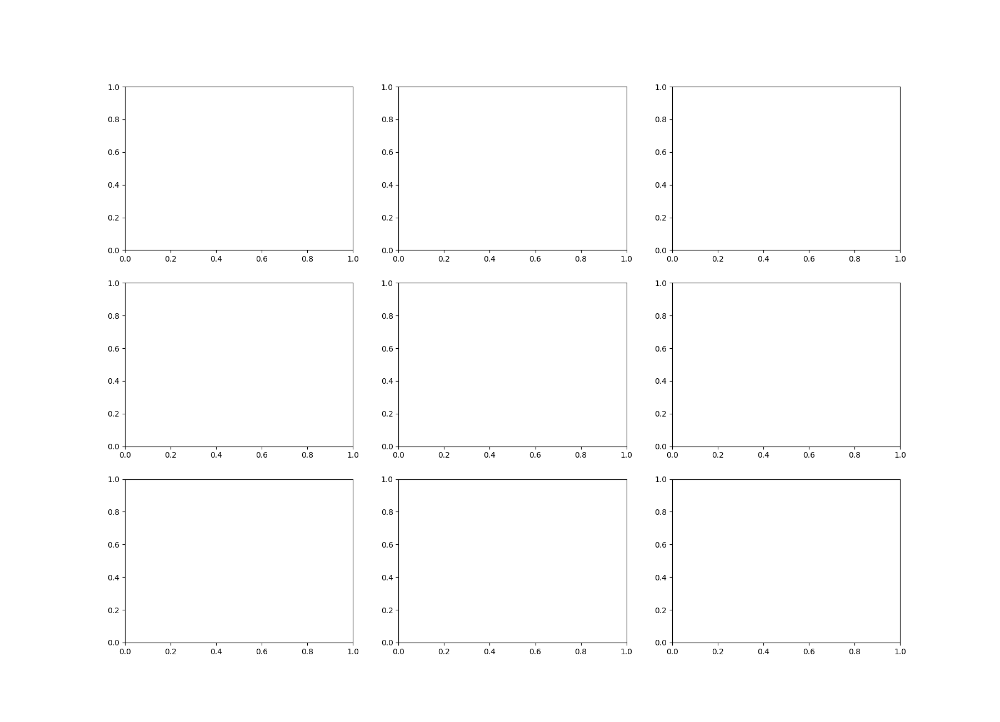

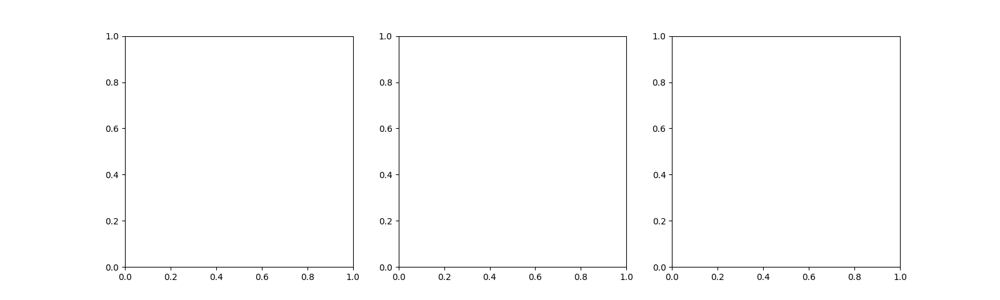

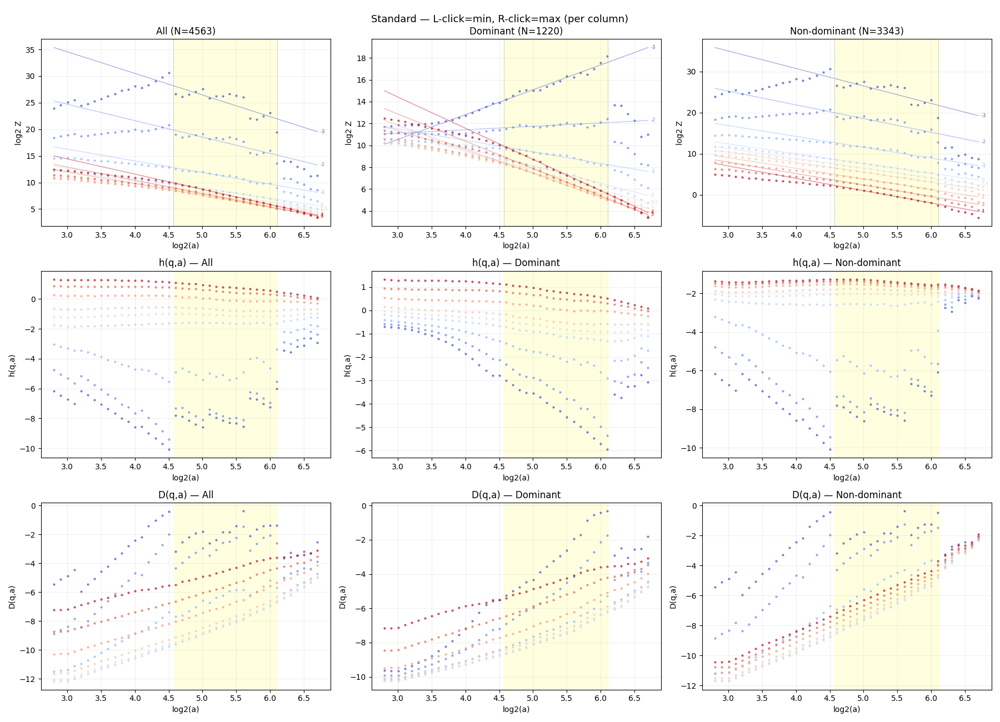

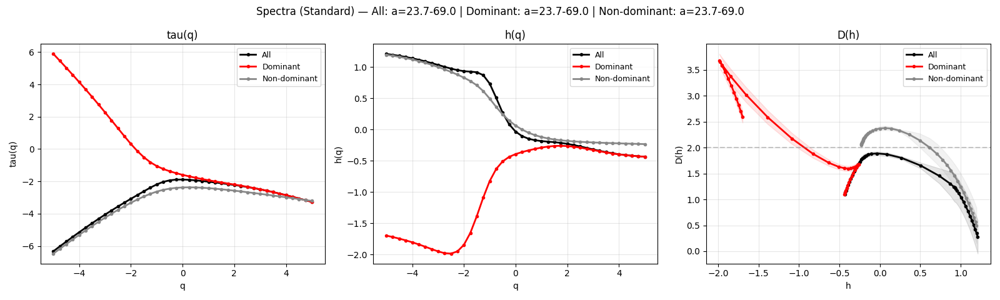

In [ ]:
# Cell 16e (faster) - Interactive partition functions: all / dominant / non-dominant
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# ----------------------------
# State
# ----------------------------
set_names_16 = ['All', 'Dominant', 'Non-dominant']
method_map_16 = {'Standard': 'std', 'Chainmax': 'cmax'}

fit_states_16 = {
    'All': {'smin': ph_s[0], 'smax': ph_s[-1]},
    'Dominant': {'smin': ph_s[0], 'smax': ph_s[-1]},
    'Non-dominant': {'smin': ph_s[0], 'smax': ph_s[-1]},
}

try:
    for k in fit_states_16:
        fit_states_16[k]['smin'] = fit_st['scale_min']
        fit_states_16[k]['smax'] = fit_st['scale_max']
except:
    pass

cm_toggle_16 = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'],
    value='Standard',
    description='Method:'
)

# ----------------------------
# Precompute reusable things
# ----------------------------
ph_s_arr_16 = np.asarray(ph_s, dtype=float)
log2_s_16 = np.log2(ph_s_arr_16)

q_show_16 = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4], dtype=float)
colors_q_16 = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_16)))
set_colors_16 = {'All': 'black', 'Dominant': 'red', 'Non-dominant': '#888888'}

# nearest q indices once per hd q-grid
q_idx_cache_16 = {}
for method_key in ['std', 'cmax']:
    q_list = sets_16['All'][method_key]['q_list']
    q_idx_cache_16[method_key] = [int(np.argmin(np.abs(q_list - qv))) for qv in q_show_16]

# optional cache for spectra by (method, set, smin, smax)
spectra_cache_16 = {}

# ----------------------------
# Build figures once
# ----------------------------
fig_pf_16, axes_pf_16 = plt.subplots(3, 3, figsize=(18, 13))
fig_sp_16, axes_sp_16 = plt.subplots(1, 3, figsize=(16, 4.8))

for fig in [fig_pf_16, fig_sp_16]:
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False
    fig.canvas.toolbar_position = 'right'

# ----------------------------
# Helpers
# ----------------------------
def _get_smask_16(smin, smax):
    return (ph_s_arr_16 >= smin) & (ph_s_arr_16 <= smax)

def _safe_polyfit_16(x, y):
    v = np.isfinite(x) & np.isfinite(y)
    if v.sum() < 2:
        return None
    try:
        return np.polyfit(x[v], y[v], 1)
    except Exception:
        return None

def _get_spectrum_cached_16(name, method_key, smin, smax):
    key = (name, method_key, round(float(smin), 6), round(float(smax), 6))
    if key in spectra_cache_16:
        return spectra_cache_16[key]
    try:
        sp = extract_hq_Dq_from_plateaus(
            sets_16[name][method_key],
            scale_range=(smin, smax)
        )
    except Exception:
        sp = None
    spectra_cache_16[key] = sp
    return sp

# ----------------------------
# Main redraw
# ----------------------------
def draw_pf_16(*args):
    method_key = method_map_16[cm_toggle_16.value]
    q_idx_list = q_idx_cache_16[method_key]

    # ---- partition panels
    for axrow in axes_pf_16:
        for ax in axrow:
            ax.cla()

    for col, name in enumerate(set_names_16):
        hd = sets_16[name][method_key]
        fs = fit_states_16[name]
        smin = float(fs['smin'])
        smax = float(fs['smax'])
        if smin > smax:
            smin, smax = smax, smin
            fit_states_16[name]['smin'] = smin
            fit_states_16[name]['smax'] = smax

        smask = _get_smask_16(smin, smax)
        nc = sets_16[name]['n_chains']

        # Row 0: tau(q,a) with fitted lines
        ax = axes_pf_16[0, col]
        for idx, qv, cq in zip(q_idx_list, q_show_16, colors_q_16):
            y = hd['tau_qa'][idx]
            v = np.isfinite(y)
            if v.sum() < 2:
                continue

            xv = log2_s_16[v]
            yv = y[v]
            ax.plot(xv, yv, 'o', color=cq, ms=3, alpha=0.7, mec='none')

            xf = log2_s_16[smask]
            yf = y[smask]
            fit = _safe_polyfit_16(xf, yf)
            if fit is not None:
                sl, ic = fit
                ax.plot(xv, sl * xv + ic, '-', color=cq, lw=1, alpha=0.45)
                ax.text(xv[-1] + 0.04, sl * xv[-1] + ic, f'{qv:g}',
                        color=cq, fontsize=6, va='center')

        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.12, color='yellow')
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.6, alpha=0.6)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.6, alpha=0.6)
        ax.set_title(f'{name} (N={nc})')
        ax.set_xlabel('log2(a)')
        ax.set_ylabel('log2 Z')
        ax.grid(True, alpha=0.2)

        # Row 1: h(q,a)
        ax = axes_pf_16[1, col]
        for idx, cq in zip(q_idx_list, colors_q_16):
            y = hd['h_qa'][idx]
            v = np.isfinite(y)
            if v.sum() > 1:
                ax.plot(log2_s_16[v], y[v], 'o', color=cq, ms=3, alpha=0.7, mec='none')
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.12, color='yellow')
        ax.set_title(f'h(q,a) — {name}')
        ax.set_xlabel('log2(a)')
        ax.set_ylabel('h(q,a)')
        ax.grid(True, alpha=0.2)

        # Row 2: D(q,a)
        ax = axes_pf_16[2, col]
        for idx, cq in zip(q_idx_list, colors_q_16):
            y = hd['D_qa'][idx]
            v = np.isfinite(y)
            if v.sum() > 1:
                ax.plot(log2_s_16[v], y[v], 'o', color=cq, ms=3, alpha=0.7, mec='none')
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.12, color='yellow')
        ax.set_title(f'D(q,a) — {name}')
        ax.set_xlabel('log2(a)')
        ax.set_ylabel('D(q,a)')
        ax.grid(True, alpha=0.2)

    fig_pf_16.suptitle(f'{cm_toggle_16.value} — L-click=min, R-click=max (per column)', fontsize=13)
    fig_pf_16.tight_layout()
    fig_pf_16.canvas.draw_idle()

    # ---- spectra panels
    for ax in axes_sp_16:
        ax.cla()

    for name, color in set_colors_16.items():
        fs = fit_states_16[name]
        smin = float(fs['smin'])
        smax = float(fs['smax'])
        sp = _get_spectrum_cached_16(name, method_key, smin, smax)
        if sp is None:
            continue

        q = sp['q_list']

        vt = np.isfinite(sp['tau'])
        if vt.any():
            axes_sp_16[0].plot(q[vt], sp['tau'][vt], '.-', color=color, lw=2, label=name)

        vh = np.isfinite(sp['h'])
        if vh.any():
            axes_sp_16[1].plot(q[vh], sp['h'][vh], '.-', color=color, lw=2, label=name)

        vd = np.isfinite(sp['D']) & np.isfinite(sp['h'])
        if vd.any():
            hh = sp['h'][vd]
            dd = sp['D'][vd]
            ee = sp['D_err'][vd] if 'D_err' in sp else np.zeros_like(dd)
            axes_sp_16[2].plot(hh, dd, '.-', color=color, lw=2, label=name)
            axes_sp_16[2].fill_between(hh, dd - ee, dd + ee, color=color, alpha=0.10)

    axes_sp_16[0].set_title('tau(q)')
    axes_sp_16[0].set_xlabel('q')
    axes_sp_16[0].set_ylabel('tau(q)')

    axes_sp_16[1].set_title('h(q)')
    axes_sp_16[1].set_xlabel('q')
    axes_sp_16[1].set_ylabel('h(q)')

    axes_sp_16[2].set_title('D(h)')
    axes_sp_16[2].set_xlabel('h')
    axes_sp_16[2].set_ylabel('D(h)')
    axes_sp_16[2].axhline(2, color='gray', ls='--', alpha=0.4)

    for ax in axes_sp_16:
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    ranges_str = ' | '.join(
        f'{n}: a={fit_states_16[n]["smin"]:.1f}-{fit_states_16[n]["smax"]:.1f}'
        for n in set_names_16
    )
    fig_sp_16.suptitle(f'Spectra ({cm_toggle_16.value}) — {ranges_str}', fontsize=12)
    fig_sp_16.tight_layout()
    fig_sp_16.canvas.draw_idle()

# ----------------------------
# Click interaction: one callback only
# ----------------------------
def on_click_pf_16(event):
    if event.inaxes is None or event.xdata is None:
        return
    if event.canvas is not fig_pf_16.canvas:
        return

    # identify which column was clicked
    hit_col = None
    for col in range(3):
        if event.inaxes in axes_pf_16[:, col]:
            hit_col = col
            break
    if hit_col is None:
        return

    set_name = set_names_16[hit_col]
    a = 2 ** event.xdata

    if event.button == 1:
        fit_states_16[set_name]['smin'] = a
    elif event.button == 3:
        fit_states_16[set_name]['smax'] = a
    else:
        return

    if fit_states_16[set_name]['smin'] > fit_states_16[set_name]['smax']:
        fit_states_16[set_name]['smin'], fit_states_16[set_name]['smax'] = \
            fit_states_16[set_name]['smax'], fit_states_16[set_name]['smin']

    draw_pf_16()

# connect once
_ = fig_pf_16.canvas.mpl_connect('button_press_event', on_click_pf_16)

# widget callback
cm_toggle_16.observe(draw_pf_16, names='value')

print("L-click = min scale, R-click = max scale (click in any PF column)")
display(cm_toggle_16)
display(fig_pf_16.canvas)
display(fig_sp_16.canvas)

draw_pf_16()

In [ ]:
# Cell 16b2 - Chain derivatives with threshold filtering
# Uses same precomputed matrices as Cell 16b (mod_safe, log2_mod_matrix, etc.)
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown, Layout
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Precompute finite differences for all chains
# h_local[ci, si] = (log2_mod[ci, si+1] - log2_mod[ci, si]) / (log2_s[si+1] - log2_s[si])
log2_s_arr = np.log2(np.array(ph_s))
ds = np.diff(log2_s_arr)  # scale spacing in log2

h_local_matrix = np.full((n_ch, n_sc - 1), np.nan, dtype=np.float64)
h2_local_matrix = np.full((n_ch, n_sc - 2), np.nan, dtype=np.float64)
s_mid = (log2_s_arr[:-1] + log2_s_arr[1:]) / 2  # midpoints for h
s_mid2 = (s_mid[:-1] + s_mid[1:]) / 2  # midpoints for h''

for ci in range(n_ch):
    n = chain_n[ci]
    if n < 2: continue
    lm = log2_mod_matrix[ci, :n]
    dm = np.diff(lm)
    h_local_matrix[ci, :n-1] = dm / ds[:n-1]
    if n >= 3:
        dh = np.diff(h_local_matrix[ci, :n-1])
        ds2 = (ds[:n-2] + ds[1:n-1]) / 2
        h2_local_matrix[ci, :n-2] = dh / ds2

# Also for chainmax display
h_local_sup = np.full((n_ch, n_sc - 1), np.nan, dtype=np.float64)
h2_local_sup = np.full((n_ch, n_sc - 2), np.nan, dtype=np.float64)
for ci in range(n_ch):
    n = chain_n[ci]
    if n < 2: continue
    lm = log2_running_max_matrix[ci, :n]
    dm = np.diff(lm)
    h_local_sup[ci, :n-1] = dm / ds[:n-1]
    if n >= 3:
        dh = np.diff(h_local_sup[ci, :n-1])
        ds2 = (ds[:n-2] + ds[1:n-1]) / 2
        h2_local_sup[ci, :n-2] = dh / ds2

# Mean h per chain (for coloring)
mean_h = np.nanmean(h_local_matrix, axis=1)
mean_h = np.nan_to_num(mean_h, nan=0.0)

print(f"Precomputed derivatives: h_local {h_local_matrix.shape}, h2_local {h2_local_matrix.shape}")

def draw_derivs(min_vc, max_chains, display_chainmax, cmap_name, 
                filter_by, filter_min, filter_max):
    
    h_mat = h_local_sup if display_chainmax else h_local_matrix
    h2_mat = h2_local_sup if display_chainmax else h2_local_matrix
    
    # Filter chains
    valid = chain_n >= min_vc
    
    if filter_by == 'None':
        pass
    elif filter_by == 'h (1st deriv) range':
        for ci in range(n_ch):
            if not valid[ci]: continue
            mh = np.nanmean(h_mat[ci, :chain_n[ci]-1])
            if not (filter_min <= mh <= filter_max):
                valid[ci] = False
    elif filter_by == "h' (2nd deriv) range":
        for ci in range(n_ch):
            if not valid[ci] or chain_n[ci] < 3: continue
            mh2 = np.nanmean(np.abs(h2_mat[ci, :chain_n[ci]-2]))
            if not (filter_min <= mh2 <= filter_max):
                valid[ci] = False
    elif filter_by == 'h std (variability)':
        for ci in range(n_ch):
            if not valid[ci]: continue
            sh = np.nanstd(h_mat[ci, :chain_n[ci]-1])
            if not (filter_min <= sh <= filter_max):
                valid[ci] = False
    
    n_valid = int(valid.sum())
    display_label = 'sup' if display_chainmax else 'raw'
    
    # Color by mean h
    cmap = plt.get_cmap(cmap_name)
    h_norm = Normalize(vmin=-1, vmax=2)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Top left: h(a) = local Holder vs log2(a)
    ax = axes[0, 0]
    n_drawn = 0
    for ci in range(n_ch):
        if not valid[ci]: continue
        if n_drawn >= max_chains: break
        n = chain_n[ci]
        if n < 2: continue
        h_vals = h_mat[ci, :n-1]
        v = ~np.isnan(h_vals)
        if v.sum() == 0: continue
        ax.plot(s_mid[:n-1][v], h_vals[v], '-', 
                color=cmap(h_norm(mean_h[ci])), lw=0.5, alpha=0.3)
        n_drawn += 1
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set(xlabel='log2(scale)', ylabel='h(a) = d log2|W| / d log2(a)',
           title=f'Local Holder ({n_valid} chains, {display_label})')
    ax.grid(True, alpha=0.2)
    sm = ScalarMappable(norm=h_norm, cmap=cmap)
    sm.set_array([]); plt.colorbar(sm, ax=ax, label='mean h', shrink=0.7)
    
    # Top right: h''(a) = curvature vs log2(a)
    ax2 = axes[0, 1]
    n_drawn = 0
    for ci in range(n_ch):
        if not valid[ci]: continue
        if n_drawn >= max_chains: break
        n = chain_n[ci]
        if n < 3: continue
        h2_vals = h2_mat[ci, :n-2]
        v = ~np.isnan(h2_vals)
        if v.sum() == 0: continue
        ax2.plot(s_mid2[:n-2][v], h2_vals[v], '-',
                 color=cmap(h_norm(mean_h[ci])), lw=0.5, alpha=0.3)
        n_drawn += 1
    ax2.axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
    ax2.set(xlabel='log2(scale)', ylabel="h'(a) = d²log2|W| / d(log2 a)²",
            title=f'Curvature ({display_label})')
    ax2.grid(True, alpha=0.2)
    
    # Bottom left: histogram of all local h values
    ax3 = axes[1, 0]
    all_h = h_mat[valid, :].ravel()
    all_h = all_h[np.isfinite(all_h)]
    all_h = all_h[(all_h > -3) & (all_h < 5)]
    if len(all_h) > 0:
        ax3.hist(all_h, bins=200, color='steelblue', edgecolor='k', alpha=0.7)
        ax3.axvline(np.median(all_h), color='red', ls='--', lw=2,
                    label=f'median = {np.median(all_h):.3f}')
        ax3.axvline(0, color='gray', ls=':', lw=1)
    ax3.set(xlabel='h(a)', ylabel='count',
            title=f'h distribution ({len(all_h)} values)')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
    
    # Bottom right: histogram of h'' values
    ax4 = axes[1, 1]
    all_h2 = h2_mat[valid, :].ravel()
    all_h2 = all_h2[np.isfinite(all_h2)]
    all_h2 = all_h2[(all_h2 > -10) & (all_h2 < 10)]
    if len(all_h2) > 0:
        ax4.hist(all_h2, bins=200, color='coral', edgecolor='k', alpha=0.7)
        ax4.axvline(np.median(all_h2), color='red', ls='--', lw=2,
                    label=f'median = {np.median(all_h2):.3f}')
        ax4.axvline(0, color='gray', ls=':', lw=1)
    ax4.set(xlabel="h'(a)", ylabel='count',
            title=f"h' distribution ({len(all_h2)} values)")
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)
    
    filter_str = f'{filter_by}: [{filter_min:.2f}, {filter_max:.2f}]' if filter_by != 'None' else 'None'
    fig.suptitle(f'Chain derivatives ({display_label}) | Filter: {filter_str} | '
                 f'{n_valid}/{n_ch} chains', fontsize=13)
    plt.tight_layout(); plt.show()

interact(
    draw_derivs,
    min_vc=IntSlider(value=5, min=2, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    max_chains=IntSlider(value=3000, min=100, max=10000, step=100,
                         description='Max chains:', layout=Layout(width='50%'), continuous_update=False),
    display_chainmax=Checkbox(value=False, description='Display chainmax (sup)'),
    cmap_name=Dropdown(options=['coolwarm', 'brg', 'RdBu_r', 'viridis', 'plasma', 'hot'],
                       value='coolwarm', description='Colormap:'),
    filter_by=Dropdown(options=['None', 'h (1st deriv) range', "h' (2nd deriv) range", 'h std (variability)'],
                       value='None', description='Filter by:'),
    filter_min=FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.05,
                           description='Filter min:', layout=Layout(width='60%'), continuous_update=False),
    filter_max=FloatSlider(value=2.0, min=-5.0, max=10.0, step=0.05,
                           description='Filter max:', layout=Layout(width='60%'), continuous_update=False));

In [ ]:
# Cell 16b3 - Classify sup-at-finest chains: noise vs real singularities
# Criteria:
#   R^2 of linear fit on raw log2|W| vs log2(a) — high R^2 = clean power law
#   Std of h'(a) across scales — low std = constant curvature (noise), high std = real
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Layout
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

MIN_VC_SEL = 5

# Identify sup-at-finest chains
sup_at_finest = np.zeros(n_ch, dtype=bool)
for ci in range(n_ch):
    n = chain_n[ci]
    if n < 2: continue
    if np.argmax(mod_safe[ci, :n]) == 0:
        sup_at_finest[ci] = True

# Precompute per-chain statistics (raw, not chainmax)
chain_r2 = np.full(n_ch, np.nan)       # R^2 of linear fit log2|W| vs log2(a)
chain_h_raw = np.full(n_ch, np.nan)    # slope = mean h from raw
chain_hp_std = np.full(n_ch, np.nan)   # std of h'(a) across scales (raw)
chain_hp_mean = np.full(n_ch, np.nan)  # mean of |h'(a)| (raw)

for ci in range(n_ch):
    n = chain_n[ci]
    if n < MIN_VC_SEL or not sup_at_finest[ci]: continue
    
    lm = log2_mod_matrix[ci, :n]
    la = skel_chains[ci]['log2_s']
    v = np.isfinite(lm)
    if v.sum() < 3: continue
    
    # R^2 of linear fit
    coeffs = np.polyfit(la[v], lm[v], 1)
    fit = np.polyval(coeffs, la[v])
    ss_res = np.sum((lm[v] - fit)**2)
    ss_tot = np.sum((lm[v] - np.mean(lm[v]))**2)
    chain_r2[ci] = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    chain_h_raw[ci] = coeffs[0]  # slope = h
    
    # h'(a) statistics from raw derivatives
    h_vals = h_local_matrix[ci, :n-1]
    vh = ~np.isnan(h_vals)
    if vh.sum() < 2: continue
    
    if n >= 3:
        h2_vals = h2_local_matrix[ci, :n-2]
        vh2 = ~np.isnan(h2_vals)
        if vh2.sum() > 0:
            chain_hp_std[ci] = np.nanstd(h2_vals)
            chain_hp_mean[ci] = np.nanmean(np.abs(h2_vals))

n_sup = sup_at_finest.sum()
n_computed = np.sum(np.isfinite(chain_r2) & sup_at_finest)
print(f"Sup-at-finest: {n_sup} chains, {n_computed} with computed stats")
print(f"R^2 range: [{np.nanmin(chain_r2[sup_at_finest]):.3f}, {np.nanmax(chain_r2[sup_at_finest]):.3f}]")
print(f"h'(a) std range: [{np.nanmin(chain_hp_std[sup_at_finest]):.3f}, {np.nanmax(chain_hp_std[sup_at_finest]):.3f}]")

def draw_classified(min_vc, criterion, thresh_val, cmap_name, max_chains):
    valid = sup_at_finest & (chain_n >= min_vc)
    
    if criterion == 'R^2 of raw fit (high = clean)':
        # High R^2 = clean power law (real or noise with consistent slope)
        # Low R^2 = erratic (spurious)
        spurious = valid & np.isfinite(chain_r2) & (chain_r2 < thresh_val)
        real = valid & np.isfinite(chain_r2) & (chain_r2 >= thresh_val)
        color_val = chain_r2
        color_label = 'R^2'
        cnorm = Normalize(vmin=0, vmax=1)
    elif criterion == "h''(a) max spike (high = spurious)":
        # Max absolute h'' = spikiest second derivative
        # Spurious maxima have spikey h'', real singularities are smooth
        chain_hp_max = np.full(n_ch, np.nan)
        for ci in range(n_ch):
            if not valid[ci]: continue
            n = chain_n[ci]
            if n < 3: continue
            h2v = h2_local_matrix[ci, :n-2]
            vh2 = ~np.isnan(h2v)
            if vh2.sum() > 0:
                chain_hp_max[ci] = np.nanmax(np.abs(h2v))
        spurious = valid & np.isfinite(chain_hp_max) & (chain_hp_max >= thresh_val)
        real = valid & np.isfinite(chain_hp_max) & (chain_hp_max < thresh_val)
        color_val = chain_hp_max
        color_label = "max |h''|"
        cnorm = Normalize(vmin=0, vmax=max(np.nanpercentile(chain_hp_max[valid & np.isfinite(chain_hp_max)], 95), 0.1))
    elif criterion == "h''(a) std (high = spurious)":
        # High std of h'' = erratic curvature = spurious
        # Low std = consistent (noise with flat h'' or real with smooth h'')
        spurious = valid & np.isfinite(chain_hp_std) & (chain_hp_std >= thresh_val)
        real = valid & np.isfinite(chain_hp_std) & (chain_hp_std < thresh_val)
        color_val = chain_hp_std
        color_label = "std(h'')"
        cnorm = Normalize(vmin=0, vmax=max(np.nanpercentile(chain_hp_std[valid & np.isfinite(chain_hp_std)], 95), 0.1))
    elif criterion == "mean |h''(a)| (high = spurious)":
        # High mean |h''| = lots of curvature = spikey = spurious
        spurious = valid & np.isfinite(chain_hp_mean) & (chain_hp_mean >= thresh_val)
        real = valid & np.isfinite(chain_hp_mean) & (chain_hp_mean < thresh_val)
        color_val = chain_hp_mean
        color_label = "mean |h''|"
        cnorm = Normalize(vmin=0, vmax=max(np.nanpercentile(chain_hp_mean[valid & np.isfinite(chain_hp_mean)], 95), 0.1))
    
    n_noise = spurious.sum()
    n_real = real.sum()
    cmap = plt.get_cmap(cmap_name)
    
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    
    # Top row: skeletons
    panels = [
        (axes[0, 0], real, f'Clean / real ({n_real})', True),
        (axes[0, 1], spurious, f'Spurious / spikey ({n_noise})', True),
        (axes[0, 2], valid, f'All sup-at-finest ({valid.sum()})', True),
    ]
    
    for ax, mask, title, do_color in panels:
        n_drawn = 0
        for ci in range(n_ch):
            if not mask[ci]: continue
            if n_drawn >= max_chains: break
            n = chain_n[ci]
            lm = log2_mod_matrix[ci, :n]
            la = skel_chains[ci]['log2_s']
            cv = color_val[ci] if np.isfinite(color_val[ci]) else 0
            c = cmap(cnorm(cv)) if do_color else '#555555'
            ax.plot(la, lm, '-', color=c, lw=0.5, alpha=0.4)
            n_drawn += 1
        ax.set(xlabel='log2(scale)', ylabel='log2(|W|) [raw]', title=title)
        ax.grid(True, alpha=0.2)
    
    sm = ScalarMappable(norm=cnorm, cmap=cmap)
    sm.set_array([]); plt.colorbar(sm, ax=axes[0, 2], label=color_label, shrink=0.7)
    
    # Bottom left: R^2 vs h scatter
    ax3 = axes[1, 0]
    v = valid & np.isfinite(chain_r2) & np.isfinite(chain_h_raw)
    ax3.scatter(chain_h_raw[v & spurious], chain_r2[v & spurious], s=3, c='gray', alpha=0.4, label='Spurious')
    ax3.scatter(chain_h_raw[v & real], chain_r2[v & real], s=5, c='red', alpha=0.6, label='Clean/real')
    ax3.axhline(thresh_val if 'R^2' in criterion else 0.5, color='green', ls='--', lw=1.5)
    ax3.set(xlabel='h (raw slope)', ylabel='R^2', title='R^2 vs h')
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
    
    # Bottom middle: h'(a) std vs h scatter
    ax4 = axes[1, 1]
    v2 = valid & np.isfinite(chain_hp_std) & np.isfinite(chain_h_raw)
    ax4.scatter(chain_h_raw[v2 & spurious], chain_hp_std[v2 & spurious], s=3, c='gray', alpha=0.4, label='Spurious')
    ax4.scatter(chain_h_raw[v2 & real], chain_hp_std[v2 & real], s=5, c='red', alpha=0.6, label='Clean/real')
    ax4.axhline(thresh_val if 'std' in criterion else 0.5, color='green', ls='--', lw=1.5)
    ax4.set(xlabel='h (raw slope)', ylabel="std(h'(a))", title="h' variability vs h")
    ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)
    
    # Bottom right: histograms of the criterion value
    ax5 = axes[1, 2]
    cv_noise = color_val[spurious & np.isfinite(color_val)]
    cv_real = color_val[real & np.isfinite(color_val)]
    if len(cv_noise) > 0:
        ax5.hist(cv_noise, bins=80, color='gray', alpha=0.5, label=f'Spurious ({len(cv_noise)})', density=True)
    if len(cv_real) > 0:
        ax5.hist(cv_real, bins=80, color='red', alpha=0.6, label=f'Real ({len(cv_real)})', density=True)
    ax5.axvline(thresh_val, color='green', ls='--', lw=2, label=f'Threshold = {thresh_val:.3f}')
    ax5.set(xlabel=color_label, ylabel='density', title=f'{criterion} distribution')
    ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)
    
    fig.suptitle(f'Sup-at-finest classification: {criterion}, threshold={thresh_val:.3f}\n'
                 f'{n_real} clean/real + {n_noise} spurious', fontsize=13)
    plt.tight_layout(); plt.show()

interact(
    draw_classified,
    min_vc=IntSlider(value=5, min=2, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False),
    criterion=Dropdown(options=['R^2 of raw fit (high = clean)',
                                "h''(a) max spike (high = spurious)",
                                "h''(a) std (high = spurious)",
                                "mean |h''(a)| (high = spurious)"],
                       value="h''(a) max spike (high = spurious)", description='Criterion:'),
    thresh_val=FloatSlider(value=0.5, min=0.0, max=2.0, step=0.01,
                           description='Threshold:', layout=Layout(width='60%'), continuous_update=False),
    cmap_name=Dropdown(options=['coolwarm', 'brg', 'RdBu_r', 'viridis', 'plasma', 'hot'],
                       value='coolwarm', description='Colormap:'),
    max_chains=IntSlider(value=3000, min=100, max=10000, step=100,
                         description='Max chains:', layout=Layout(width='50%'), continuous_update=False));

In [ ]:
# Cell 17a - Sign change frequency: isolate monotonic chains (freq == 0)

# Compute sign-change frequency for all chains
chain_sign_freq = np.full(n_ch, np.nan)
for ci in range(n_ch):
    n = chain_n[ci]
    if n < 5: continue
    lm = log2_mod_matrix[ci, :n]
    v = np.isfinite(lm)
    if v.sum() < 3: continue
    diffs = np.diff(lm[v])
    if len(diffs) < 2: continue
    signs = np.sign(diffs)
    signs = signs[signs != 0]
    if len(signs) < 2:
        chain_sign_freq[ci] = 0.0
        continue
    chain_sign_freq[ci] = np.sum(np.diff(signs) != 0) / (len(signs) - 1)

valid = np.isfinite(chain_sign_freq) & (chain_n >= 5)
monotonic = valid & (chain_sign_freq == 0)
non_mono = valid & (chain_sign_freq > 0)

print(f"Total valid chains: {valid.sum()}")
print(f"  Monotonic (freq=0): {monotonic.sum()}")
print(f"  Non-monotonic (freq>0): {non_mono.sum()}")
print(f"  Freq stats (non-mono): median={np.nanmedian(chain_sign_freq[non_mono]):.3f}, "
      f"mean={np.nanmean(chain_sign_freq[non_mono]):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left: skeleton of monotonic chains
ax = axes[0]
for ci in range(n_ch):
    if not monotonic[ci]: continue
    n = chain_n[ci]
    ax.plot(skel_chains[ci]['log2_s'], log2_mod_matrix[ci, :n], '-', 
            color='red', lw=0.5, alpha=0.3)
ax.set(xlabel='log2(a)', ylabel='log2|W|', title=f'Monotonic freq=0 ({monotonic.sum()} chains)')
ax.grid(True, alpha=0.2)

# Middle: skeleton of non-monotonic chains
ax2 = axes[1]
n_drawn = 0
for ci in range(n_ch):
    if not non_mono[ci]: continue
    if n_drawn > 5000: break
    n = chain_n[ci]
    ax2.plot(skel_chains[ci]['log2_s'], log2_mod_matrix[ci, :n], '-',
             color='gray', lw=0.3, alpha=0.15)
    n_drawn += 1
ax2.set(xlabel='log2(a)', ylabel='log2|W|', title=f'Non-monotonic ({non_mono.sum()} chains)')
ax2.grid(True, alpha=0.2)

# Right: histogram of sign-change frequency
ax3 = axes[2]
sf = chain_sign_freq[valid]
ax3.hist(sf, bins=100, color='steelblue', edgecolor='k', alpha=0.7)
ax3.axvline(0, color='red', lw=2, label=f'freq=0: {monotonic.sum()}')
ax3.set(xlabel='Sign-change frequency', ylabel='count', title='Distribution')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.suptitle('Step 1: Sign-change frequency — isolate monotonic chains', fontsize=14)
plt.tight_layout(); plt.show()


In [ ]:
# Cell 17b - Curvature of monotonic chains: h''(a) vs scale
# For freq==0 chains, plot |h''(a)| at each scale step.
# Artifact chains should have curvature that stays below a threshold at all scales.
# Real singularities may have curvature that grows at some scales.
from ipywidgets import interact, FloatSlider, IntSlider, Layout

# Precompute |h''| for monotonic chains
mono_indices = np.where(monotonic)[0]
print(f"{len(mono_indices)} monotonic chains to analyze")

# For each monotonic chain, compute cumulative max of |h''| going up in scale
# If max|h''| stays below threshold at all scales → flat artifact
mono_h2_cummax = {}  # ci -> array of cummax(|h''|)
for ci in mono_indices:
    n = chain_n[ci]
    if n < 3: continue
    h2v = np.abs(h2_local_matrix[ci, :n-2])
    v = ~np.isnan(h2v)
    if v.sum() < 2: continue
    # cumulative max of |h''| going from fine to coarse
    h2_clean = np.where(v, h2v, 0)
    mono_h2_cummax[ci] = np.maximum.accumulate(h2_clean)

print(f"  {len(mono_h2_cummax)} with computable curvature")

def draw_mono_curv(h2_thresh, min_vc):
    # Split: chains where cummax(|h''|) NEVER exceeds threshold vs those that do
    flat = []  # artifact: curvature stays low
    curved = []  # possible real: curvature exceeds threshold at some scale
    
    for ci, cm in mono_h2_cummax.items():
        if chain_n[ci] < min_vc: continue
        if np.max(cm) < h2_thresh:
            flat.append(ci)
        else:
            curved.append(ci)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Top panels: density heatmaps of |h''(a)| vs scale
    for col, (chain_set, label, cmap_h) in enumerate([
        (flat, f'Flat monotonic ({len(flat)})', 'Blues'),
        (curved, f'Curved monotonic ({len(curved)})', 'Greens')]):
        ax = axes[0, col]
        
        # Collect all (scale, |h''|) points
        all_x, all_y = [], []
        for ci in chain_set:
            n = chain_n[ci]
            if n < 3: continue
            h2v = np.abs(h2_local_matrix[ci, :n-2])
            v = ~np.isnan(h2v)
            if v.sum() > 0:
                all_x.extend(s_mid2[:n-2][v].tolist())
                all_y.extend(h2v[v].tolist())
        
        if all_x:
            all_x = np.array(all_x)
            all_y = np.array(all_y)
            # Clip y for better visualization
            all_y = np.clip(all_y, 0, np.percentile(all_y, 99))
            h = ax.hist2d(all_x, all_y, bins=[50, 80], cmap=cmap_h,
                          norm=plt.matplotlib.colors.LogNorm(), rasterized=True)
            plt.colorbar(h[3], ax=ax, label='count', shrink=0.7)
        
        ax.axhline(h2_thresh, color='red', ls='--', lw=2, label=f'Threshold = {h2_thresh}')
        ax.set(xlabel='log2(a)', ylabel="|h''(a)|", title=label)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    
    # Bottom left: skeleton of flat (to prune)
    ax3 = axes[1, 0]
    for ci in flat[:3000]:
        n = chain_n[ci]
        ax3.plot(skel_chains[ci]['log2_s'], log2_mod_matrix[ci, :n], '-',
                 color='cyan', lw=0.5, alpha=0.3)
    ax3.set(xlabel='log2(a)', ylabel='log2|W|',
            title=f'Flat mono skeleton — PRUNE these ({len(flat)})')
    ax3.grid(True, alpha=0.2)
    
    # Bottom right: skeleton of curved (to keep)
    ax4 = axes[1, 1]
    for ci in curved[:3000]:
        n = chain_n[ci]
        ax4.plot(skel_chains[ci]['log2_s'], log2_mod_matrix[ci, :n], '-',
                 color='green', lw=0.5, alpha=0.3)
    ax4.set(xlabel='log2(a)', ylabel='log2|W|',
            title=f'Curved mono skeleton — KEEP these ({len(curved)})')
    ax4.grid(True, alpha=0.2)
    
    fig.suptitle(f'Step 2: Monotonic chains — curvature threshold = {h2_thresh}\n'
                 f'{len(flat)} flat (prune) + {len(curved)} curved (keep)', fontsize=13)
    plt.tight_layout(); plt.show()

interact(
    draw_mono_curv,
    h2_thresh=FloatSlider(value=0.5, min=0.01, max=5.0, step=0.05,
                          description="|h''| thresh:", layout=Layout(width='60%'), continuous_update=False),
    min_vc=IntSlider(value=5, min=2, max=30, step=1,
                     description='Min vc:', layout=Layout(width='50%'), continuous_update=False));
